In [ ]:
##cai dat thu vien ttorch summary
!pip install torchsummary

In [ ]:
# Import các thư viện cần thiết
import torch
import torchvision
from torchvision import transforms, datasets
import torch.optim as optim
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchsummary import summary
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:

# Tạo thư mục lưu hình ảnh
os.makedirs("output_images", exist_ok=True)

In [ ]:
# Thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


In [ ]:
# Dataset Fashion-MNIST
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
])
dataset = datasets.FashionMNIST(root='./fashion_mnist_data', train=True, download=True, transform=transform)
train_dataset, val_dataset = random_split(dataset, [50000, 10000])
test_dataset = datasets.FashionMNIST(root='./fashion_mnist_data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
# VGG16 Architecture
class VGGBlock(nn.Module):
    def __init__(self, in_channels, out_channels, batch_norm=False):
        super().__init__()
        conv_params = {'kernel_size': 3, 'stride': 1, 'padding': 1}
        self.conv1 = nn.Conv2d(in_channels, out_channels, **conv_params)
        self.bn1 = nn.BatchNorm2d(out_channels) if batch_norm else nn.Identity()
        self.conv2 = nn.Conv2d(out_channels, out_channels, **conv_params)
        self.bn2 = nn.BatchNorm2d(out_channels) if batch_norm else nn.Identity()
        self.max_pooling = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.max_pooling(x)
        return x

class VGG16(nn.Module):
    def __init__(self, input_size, num_classes=10, batch_norm=False):
        super().__init__()
        self.block_1 = VGGBlock(input_size[0], 64, batch_norm=batch_norm)
        self.block_2 = VGGBlock(64, 128, batch_norm=batch_norm)
        self.block_3 = VGGBlock(128, 256, batch_norm=batch_norm)
        self.block_4 = VGGBlock(256, 512, batch_norm=batch_norm)
        self.classifier = nn.Sequential(
            nn.Linear(512 * 2 * 2, 4096),
            nn.ReLU(True),
            nn.Dropout(p=0.65),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(p=0.65),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.block_3(x)
        x = self.block_4(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [ ]:
# Load VGG16 Model
model = VGG16((1, 32, 32), batch_norm=True).to(device)
summary(model, (1, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]             640
       BatchNorm2d-2           [-1, 64, 32, 32]             128
            Conv2d-3           [-1, 64, 32, 32]          36,928
       BatchNorm2d-4           [-1, 64, 32, 32]             128
         MaxPool2d-5           [-1, 64, 16, 16]               0
          VGGBlock-6           [-1, 64, 16, 16]               0
            Conv2d-7          [-1, 128, 16, 16]          73,856
       BatchNorm2d-8          [-1, 128, 16, 16]             256
            Conv2d-9          [-1, 128, 16, 16]         147,584
      BatchNorm2d-10          [-1, 128, 16, 16]             256
        MaxPool2d-11            [-1, 128, 8, 8]               0
         VGGBlock-12            [-1, 128, 8, 8]               0
           Conv2d-13            [-1, 256, 8, 8]         295,168
      BatchNorm2d-14            [-1, 25

In [ ]:
# FGSM Attack
def fgsm_attack(model, imgs, labels, eps):
    imgs.requires_grad = True
    outputs = model(imgs)
    loss = F.cross_entropy(outputs, labels)
    model.zero_grad()
    loss.backward()
    adv_imgs = imgs + eps * imgs.grad.sign()
    adv_imgs = torch.clamp(adv_imgs, 0, 1)
    return adv_imgs


In [ ]:
# PGD Attack
def pgd_attack(model, imgs, labels, eps, alpha, iters):
    adv_imgs = imgs.clone().detach().requires_grad_(True).to(device)
    for _ in range(iters):
        outputs = model(adv_imgs)
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()
        adv_imgs = adv_imgs + alpha * adv_imgs.grad.sign()
        eta = torch.clamp(adv_imgs - imgs, min=-eps, max=eps)
        adv_imgs = torch.clamp(imgs + eta, 0, 1).detach().requires_grad_(True)
    return adv_imgs

In [ ]:
# Autoencoder
class ConvAutoencoder_GELU(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.GELU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.GELU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(16),
            nn.GELU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
convAE = ConvAutoencoder_GELU().to(device)
summary(convAE, (1, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 16, 16]             160
              GELU-2           [-1, 16, 16, 16]               0
            Conv2d-3             [-1, 32, 8, 8]           4,640
       BatchNorm2d-4             [-1, 32, 8, 8]              64
              GELU-5             [-1, 32, 8, 8]               0
            Conv2d-6             [-1, 64, 4, 4]          18,496
              GELU-7             [-1, 64, 4, 4]               0
   ConvTranspose2d-8             [-1, 32, 8, 8]          18,464
       BatchNorm2d-9             [-1, 32, 8, 8]              64
             GELU-10             [-1, 32, 8, 8]               0
  ConvTranspose2d-11           [-1, 16, 16, 16]           4,624
      BatchNorm2d-12           [-1, 16, 16, 16]              32
             GELU-13           [-1, 16, 16, 16]               0
  ConvTranspose2d-14            [-1, 1,

In [ ]:
def train_autoencoder(convAE, train_loader, val_loader, num_epochs=10, learning_rate=0.001):
    """
    Huấn luyện Autoencoder để phục hồi ảnh từ dữ liệu gốc.
    """
    optimizer = optim.Adam(convAE.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        # Training Phase
        convAE.train()
        train_loss = 0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            optimizer.zero_grad()

            # Dự đoán và tính toán loss
            outputs = convAE(imgs)
            loss = criterion(outputs, imgs)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)

        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        # Validation Phase
        convAE.eval()
        val_loss = 0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(device)
                outputs = convAE(imgs)
                loss = criterion(outputs, imgs)
                val_loss += loss.item() * imgs.size(0)

        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Vẽ biểu đồ train loss và val loss
    plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', marker='o')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', marker='o')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.savefig("output_images/autoencoder_training_loss.png")
    plt.show()

    return convAE


Training Autoencoder...
Epoch [1/20], Train Loss: 0.0088, Val Loss: 0.0019
Epoch [2/20], Train Loss: 0.0017, Val Loss: 0.0013
Epoch [3/20], Train Loss: 0.0012, Val Loss: 0.0009
Epoch [4/20], Train Loss: 0.0010, Val Loss: 0.0008
Epoch [5/20], Train Loss: 0.0008, Val Loss: 0.0008
Epoch [6/20], Train Loss: 0.0007, Val Loss: 0.0006
Epoch [7/20], Train Loss: 0.0006, Val Loss: 0.0005
Epoch [8/20], Train Loss: 0.0006, Val Loss: 0.0005
Epoch [9/20], Train Loss: 0.0005, Val Loss: 0.0005
Epoch [10/20], Train Loss: 0.0005, Val Loss: 0.0005
Epoch [11/20], Train Loss: 0.0005, Val Loss: 0.0004
Epoch [12/20], Train Loss: 0.0004, Val Loss: 0.0005
Epoch [13/20], Train Loss: 0.0004, Val Loss: 0.0004
Epoch [14/20], Train Loss: 0.0004, Val Loss: 0.0004
Epoch [15/20], Train Loss: 0.0004, Val Loss: 0.0004
Epoch [16/20], Train Loss: 0.0004, Val Loss: 0.0004
Epoch [17/20], Train Loss: 0.0003, Val Loss: 0.0003
Epoch [18/20], Train Loss: 0.0003, Val Loss: 0.0003
Epoch [19/20], Train Loss: 0.0003, Val Loss: 0.00

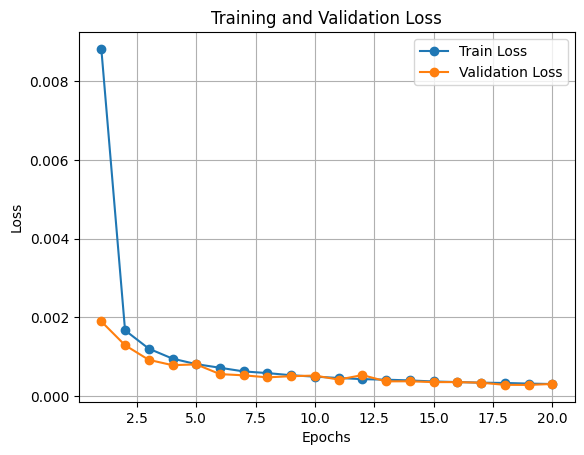

In [ ]:
# Huấn luyện Autoencoder
print("Training Autoencoder...")
convAE = train_autoencoder(convAE, train_loader, val_loader, num_epochs=20, learning_rate=0.001)

# Lưu trọng số Autoencoder sau khi huấn luyện
torch.save(convAE.state_dict(), "output_images/convAE_fashion_mnist.pth")

In [ ]:
# Đánh giá FGSM và PGD
def evaluate_with_epsilons(model, convAE, test_loader, epsilons, attack_type):
    accuracies = []
    perturbations = []

    for eps in epsilons:
        total_correct = 0
        total_samples = 0
        total_perturbation = 0

        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            # Tấn công FGSM hoặc PGD
            if attack_type == "fgsm":
                adv_imgs = fgsm_attack(model, imgs, labels, eps)
            elif attack_type == "pgd":
                adv_imgs = pgd_attack(model, imgs, labels, eps, alpha=0.01, iters=40)

            # Phục hồi ảnh
            rec_imgs = convAE(adv_imgs)

            # Dự đoán
            outputs = model(rec_imgs)
            preds = outputs.argmax(dim=1)

            # Tính toán chính xác
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

            # Tính nhiễu
            total_perturbation += torch.norm((adv_imgs - imgs).view(imgs.size(0), -1), dim=1).sum().item()

        # Tính Accuracy và Perturbation trung bình
        accuracy = total_correct / total_samples
        avg_perturbation = total_perturbation / total_samples

        accuracies.append(accuracy)
        perturbations.append(avg_perturbation)

        print(f"{attack_type.upper()} - Epsilon: {eps:.2f}, Accuracy: {accuracy:.4f}, Avg Perturbation: {avg_perturbation:.4f}")

    return accuracies, perturbations

In [ ]:
# Vẽ biểu đồ Accuracy và Perturbation
def plot_results(epsilons, fgsm_accuracies, fgsm_perturbations, pgd_accuracies, pgd_perturbations):
    plt.figure(figsize=(12, 6))

    # Biểu đồ Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epsilons, fgsm_accuracies, marker='o', label='FGSM Accuracy', color='blue')
    plt.plot(epsilons, pgd_accuracies, marker='o', label='PGD Accuracy', color='green')
    plt.title('Accuracy vs Epsilon')
    plt.xlabel('Epsilon')
    plt.ylabel('Accuracy')
    plt.grid()
    plt.legend()

    # Biểu đồ Perturbation
    plt.subplot(1, 2, 2)
    plt.plot(epsilons, fgsm_perturbations, marker='o', label='FGSM Perturbation', color='red')
    plt.plot(epsilons, pgd_perturbations, marker='o', label='PGD Perturbation', color='orange')
    plt.title('Perturbation vs Epsilon')
    plt.xlabel('Epsilon')
    plt.ylabel('Perturbation')
    plt.grid()
    plt.legend()

    plt.tight_layout()
    plt.savefig("output_images/comparison_results.png")
    plt.show()

Evaluating FGSM...
FGSM - Epsilon: 0.05, Accuracy: 0.0899, Avg Perturbation: 1.3875
FGSM - Epsilon: 0.10, Accuracy: 0.0956, Avg Perturbation: 2.7484
FGSM - Epsilon: 0.20, Accuracy: 0.0977, Avg Perturbation: 5.3496
FGSM - Epsilon: 0.30, Accuracy: 0.1048, Avg Perturbation: 7.7874
FGSM - Epsilon: 0.40, Accuracy: 0.0997, Avg Perturbation: 10.0826
Evaluating PGD...
PGD - Epsilon: 0.05, Accuracy: 0.0700, Avg Perturbation: 1.0022
PGD - Epsilon: 0.10, Accuracy: 0.0632, Avg Perturbation: 1.6897
PGD - Epsilon: 0.20, Accuracy: 0.0609, Avg Perturbation: 1.9499
PGD - Epsilon: 0.30, Accuracy: 0.0577, Avg Perturbation: 1.9531
PGD - Epsilon: 0.40, Accuracy: 0.0579, Avg Perturbation: 1.9532
Plotting results...


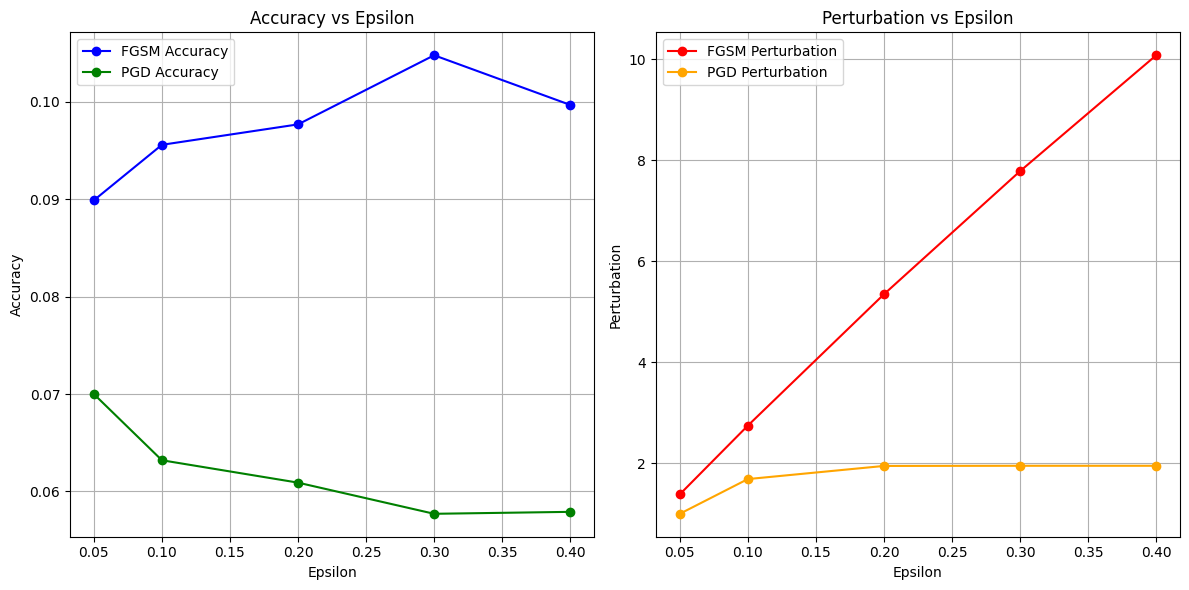

In [ ]:
# Danh sách các epsilon
epsilons = [0.05, 0.1, 0.2, 0.3, 0.4]

# Đánh giá FGSM
print("Evaluating FGSM...")
fgsm_accuracies, fgsm_perturbations = evaluate_with_epsilons(model, convAE, test_loader, epsilons, attack_type="fgsm")

# Đánh giá PGD
print("Evaluating PGD...")
pgd_accuracies, pgd_perturbations = evaluate_with_epsilons(model, convAE, test_loader, epsilons, attack_type="pgd")

# Vẽ biểu đồ so sánh
print("Plotting results...")
plot_results(epsilons, fgsm_accuracies, fgsm_perturbations, pgd_accuracies, pgd_perturbations)

In [ ]:
def visualize_images(model, convAE, test_loader, attack_type=None, eps=0.3, alpha=0.01, iters=40, num_samples=5):
    """
    Hiển thị hình ảnh gốc, tấn công, nhiễu, và phục hồi.
    - attack_type: None, 'fgsm', 'pgd'
    - num_samples: Số lượng hình ảnh hiển thị
    """
    model.eval()
    convAE.eval()

    count = 0
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        # Tấn công FGSM hoặc PGD nếu được yêu cầu
        if attack_type == 'fgsm':
            adv_imgs = fgsm_attack(model, imgs, labels, eps)
        elif attack_type == 'pgd':
            adv_imgs = pgd_attack(model, imgs, labels, eps, alpha, iters)
        else:
            adv_imgs = imgs

        # Phục hồi bằng Autoencoder
        rec_imgs = convAE(adv_imgs)

        # Chọn một số hình ảnh để hiển thị
        for i in range(min(num_samples, imgs.size(0))):
            original_img = imgs[i].detach().cpu().permute(1, 2, 0).numpy()
            adversarial_img = adv_imgs[i].detach().cpu().permute(1, 2, 0).numpy()
            noise_img = (adversarial_img - original_img)
            recovered_img = rec_imgs[i].detach().cpu().permute(1, 2, 0).numpy()

            # Chuyển đổi giá trị về [0, 1]
            original_img = np.clip(original_img, 0, 1)
            adversarial_img = np.clip(adversarial_img, 0, 1)
            recovered_img = np.clip(recovered_img, 0, 1)
            noise_img = np.clip(noise_img, 0, 1)

            # Tạo tiêu đề phù hợp
            attack_title = "Original" if attack_type is None else f"Adversarial ({attack_type.upper()})"

            # Vẽ hình ảnh
            fig, axs = plt.subplots(1, 4, figsize=(16, 4))
            axs[0].imshow(original_img.squeeze(), cmap='gray')
            axs[0].set_title("Original Image")
            axs[0].axis("off")

            axs[1].imshow(adversarial_img.squeeze(), cmap='gray')
            axs[1].set_title(attack_title)
            axs[1].axis("off")

            axs[2].imshow(noise_img.squeeze(), cmap='gray')
            axs[2].set_title("Noise")
            axs[2].axis("off")

            axs[3].imshow(recovered_img.squeeze(), cmap='gray')
            axs[3].set_title("Recovered Image")
            axs[3].axis("off")

            plt.tight_layout()
            plt.savefig(f"output_images/visualize_{attack_type}_sample_{count}.png")
            plt.show()

            count += 1
            if count >= num_samples:
                break
        if count >= num_samples:
            break

Visualizing Original Data...


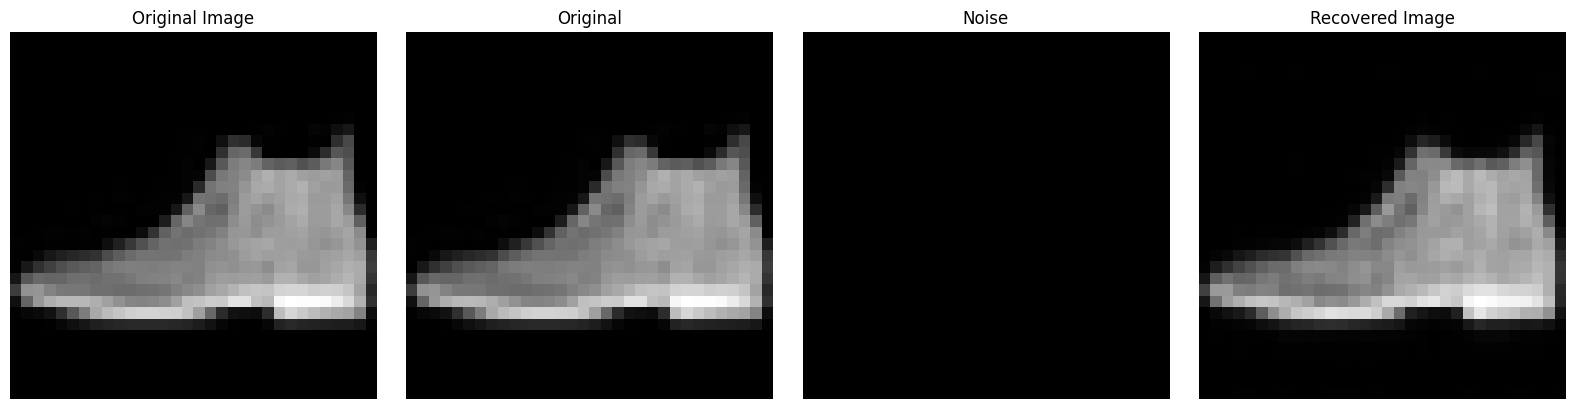

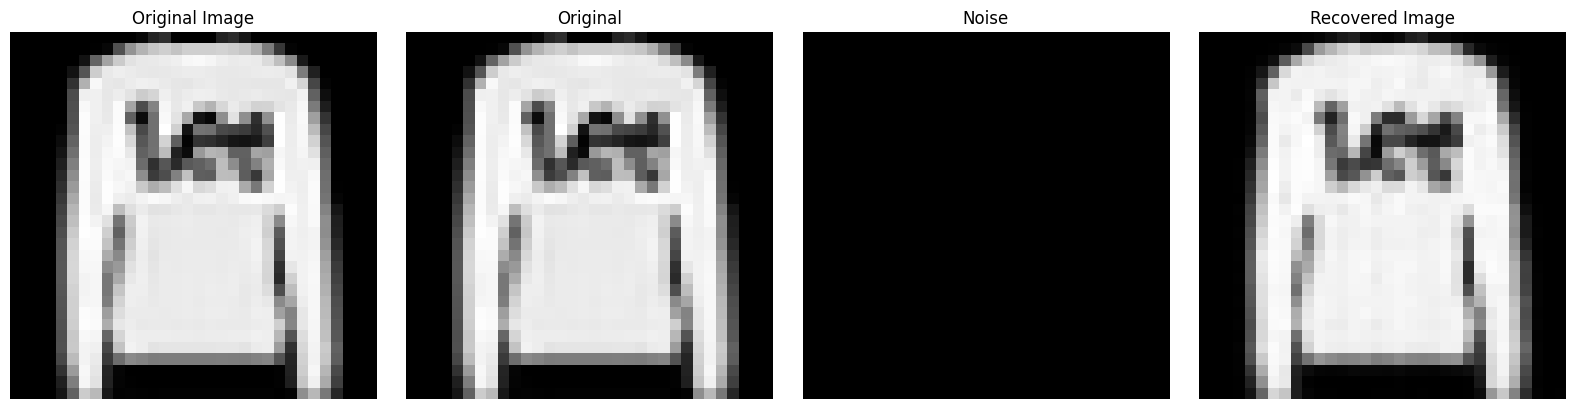

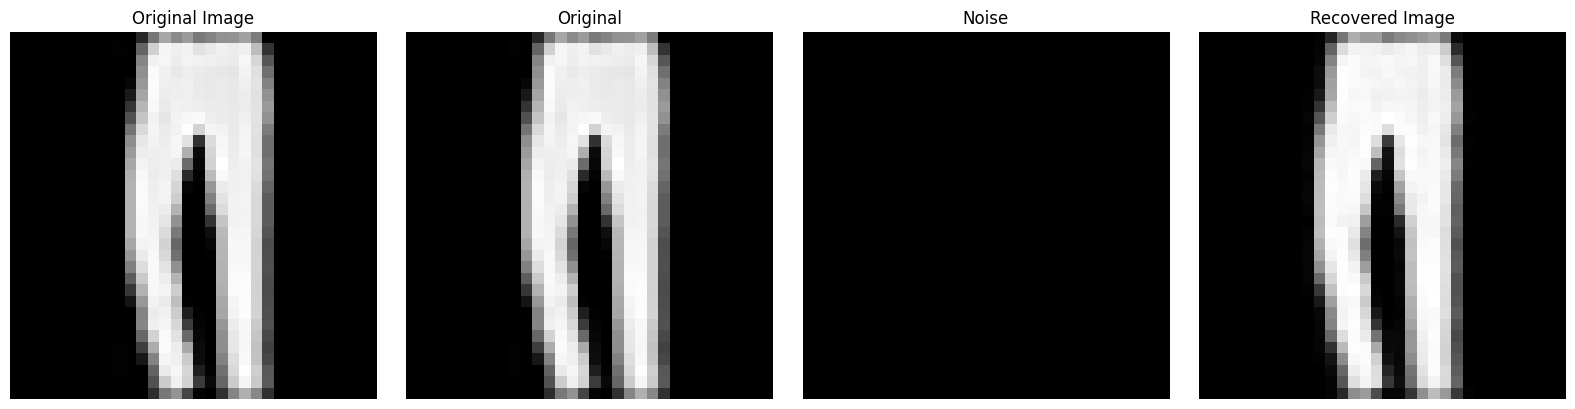

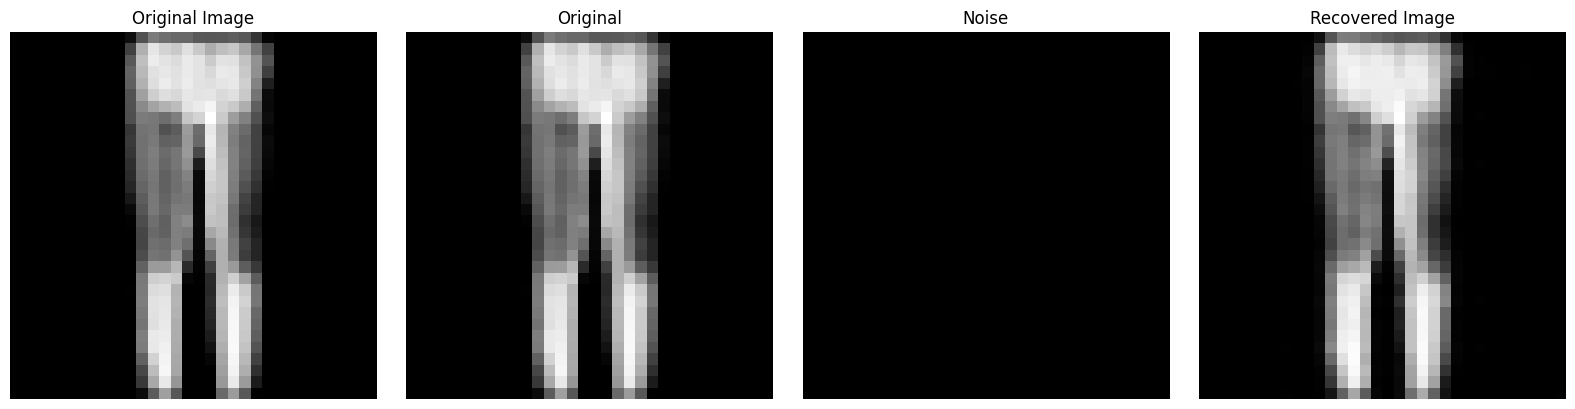

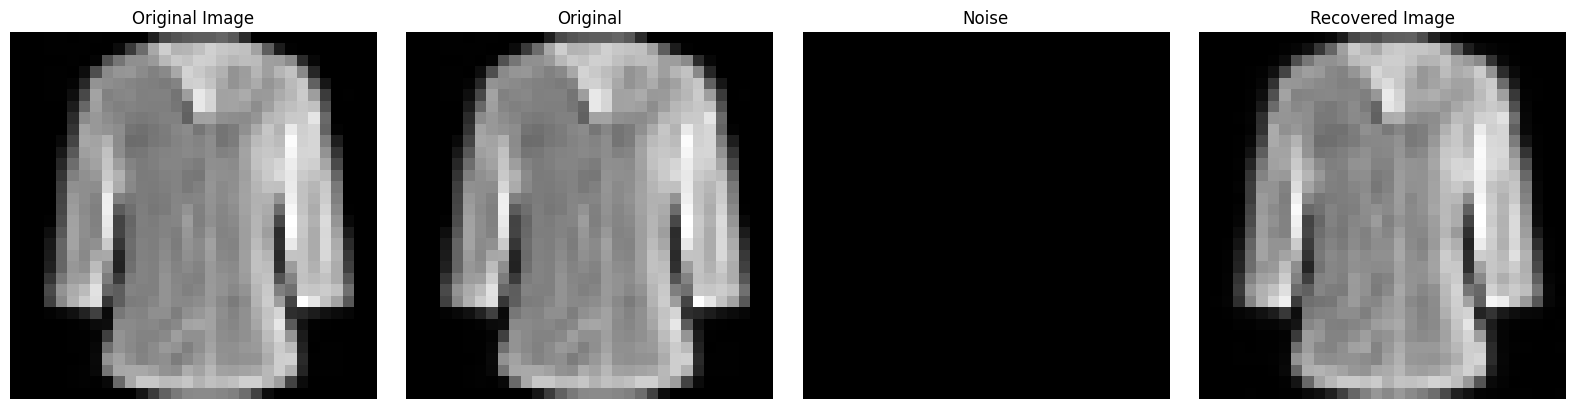

Visualizing FGSM Attack...


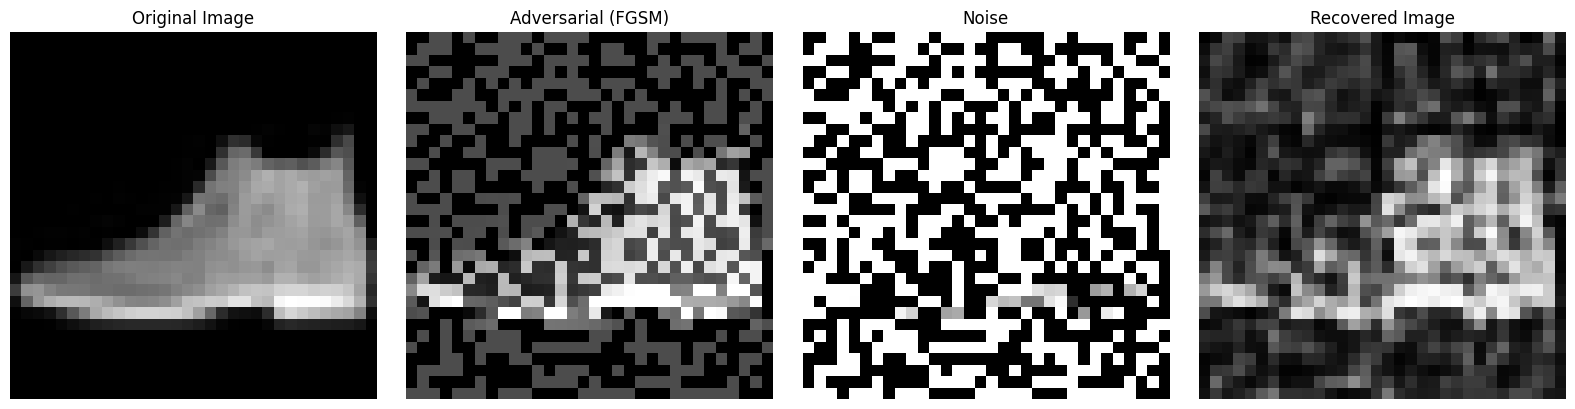

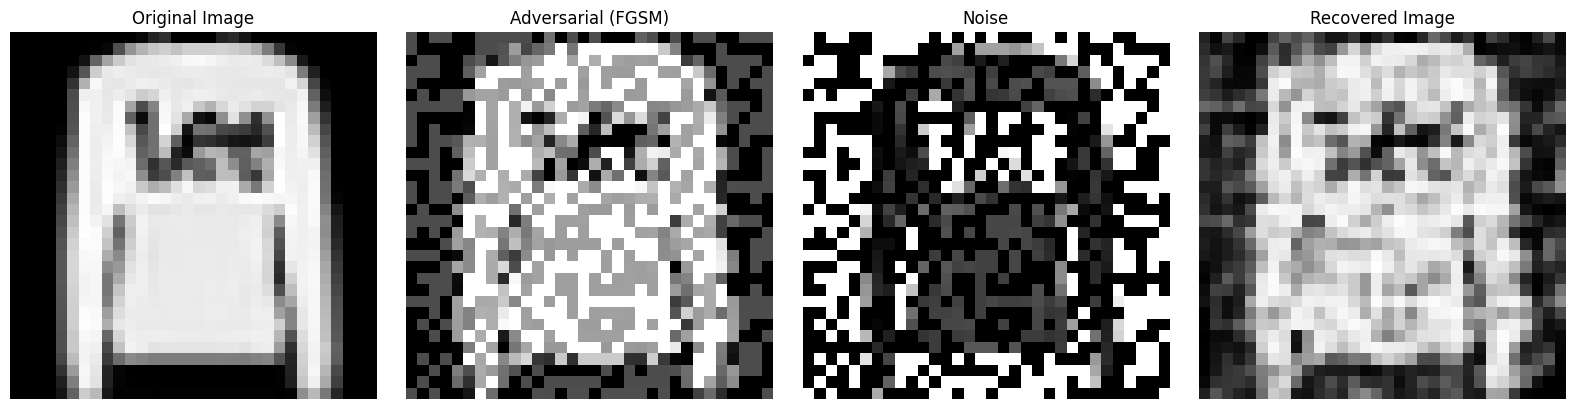

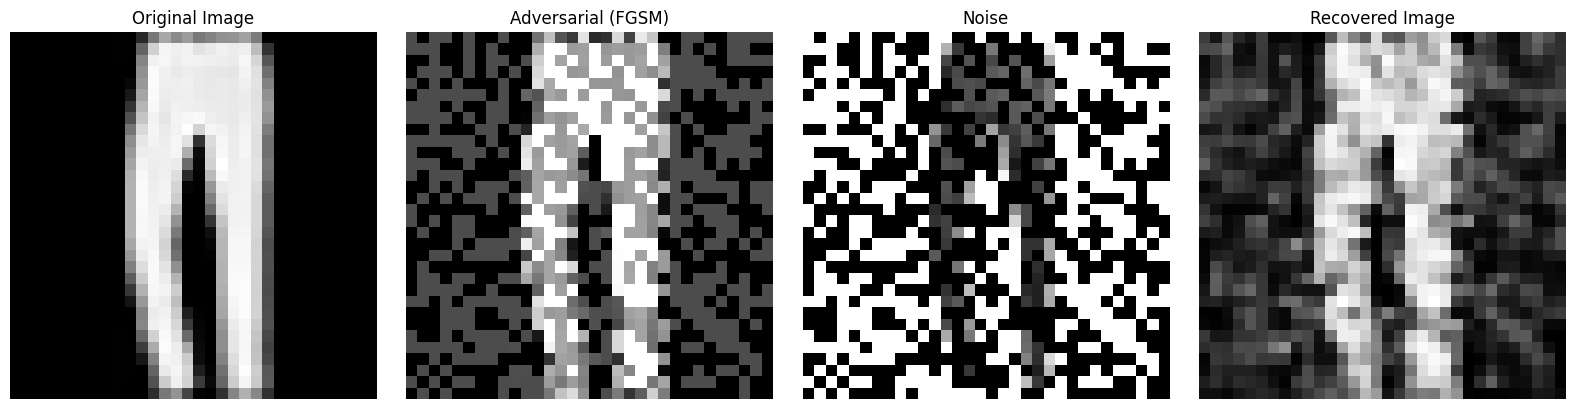

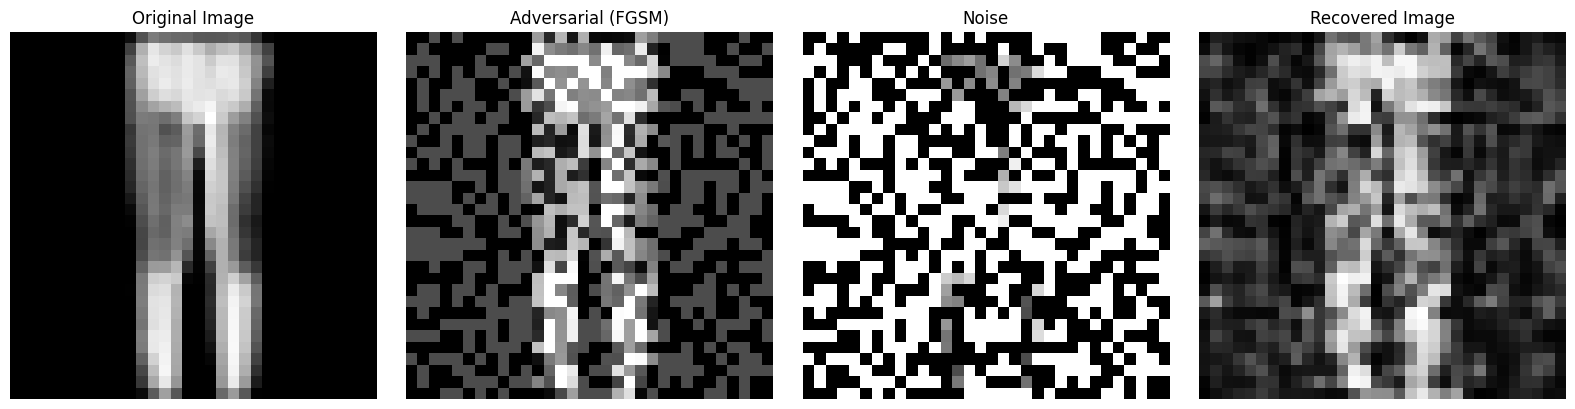

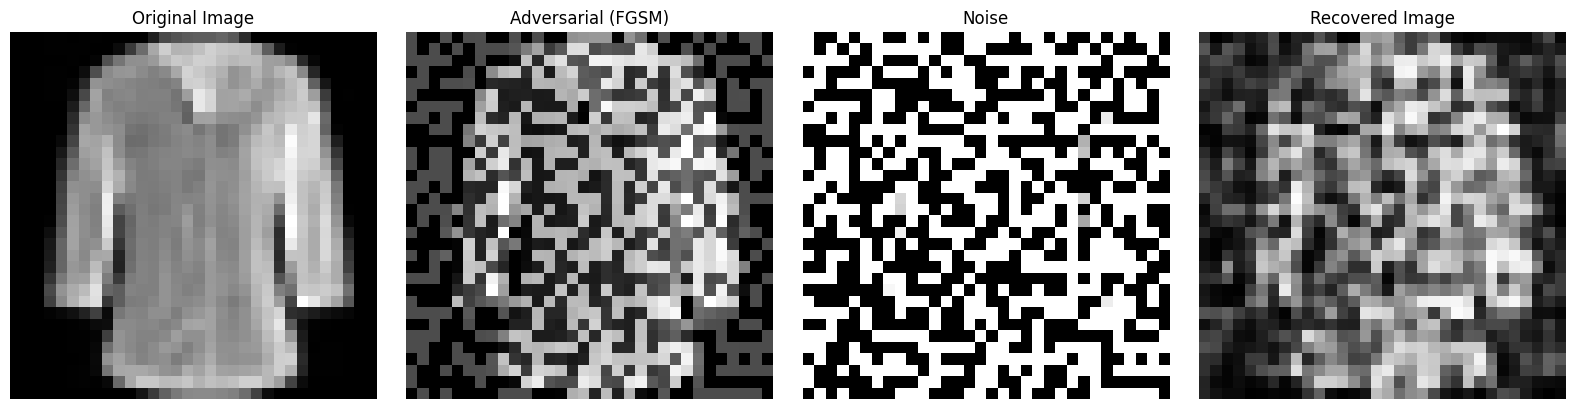

Visualizing PGD Attack...


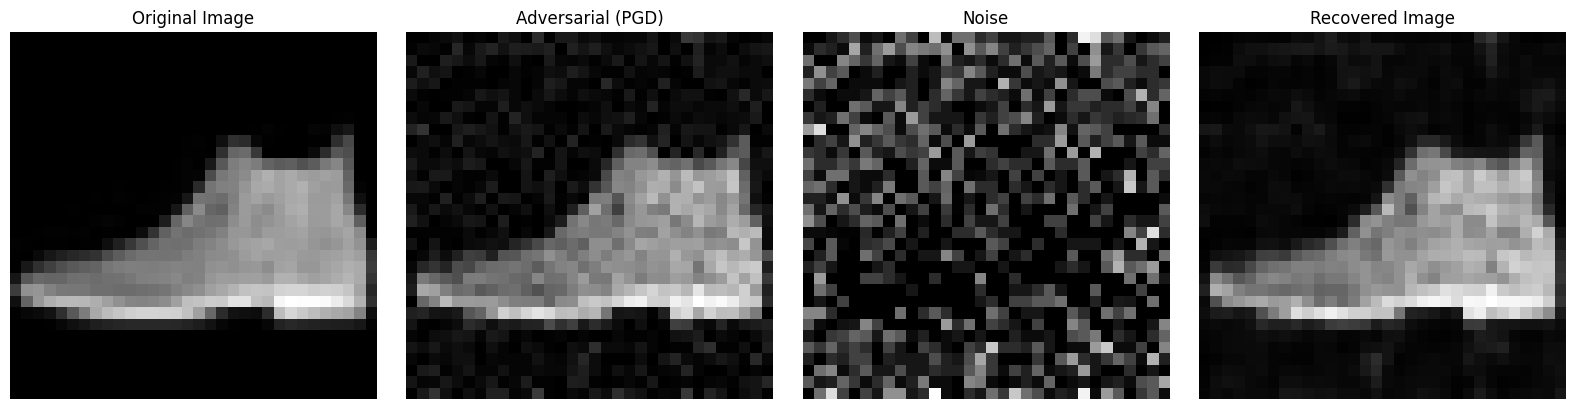

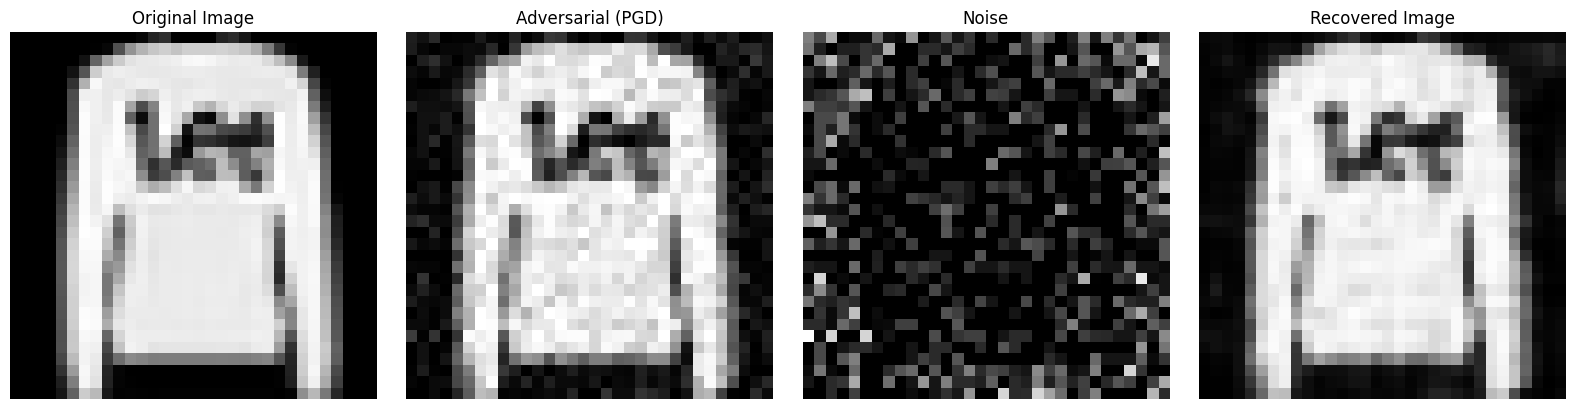

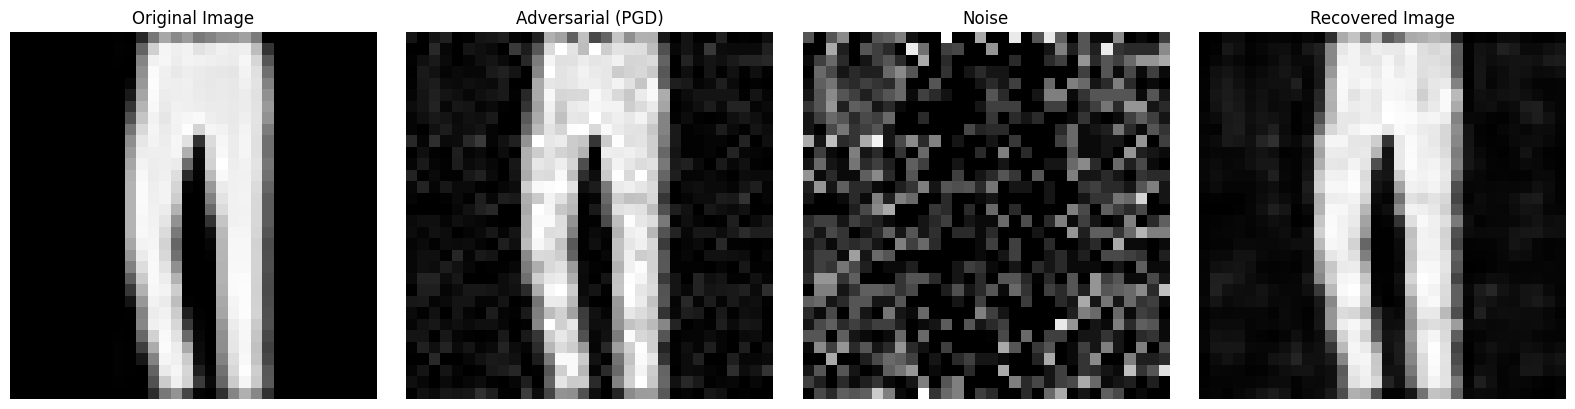

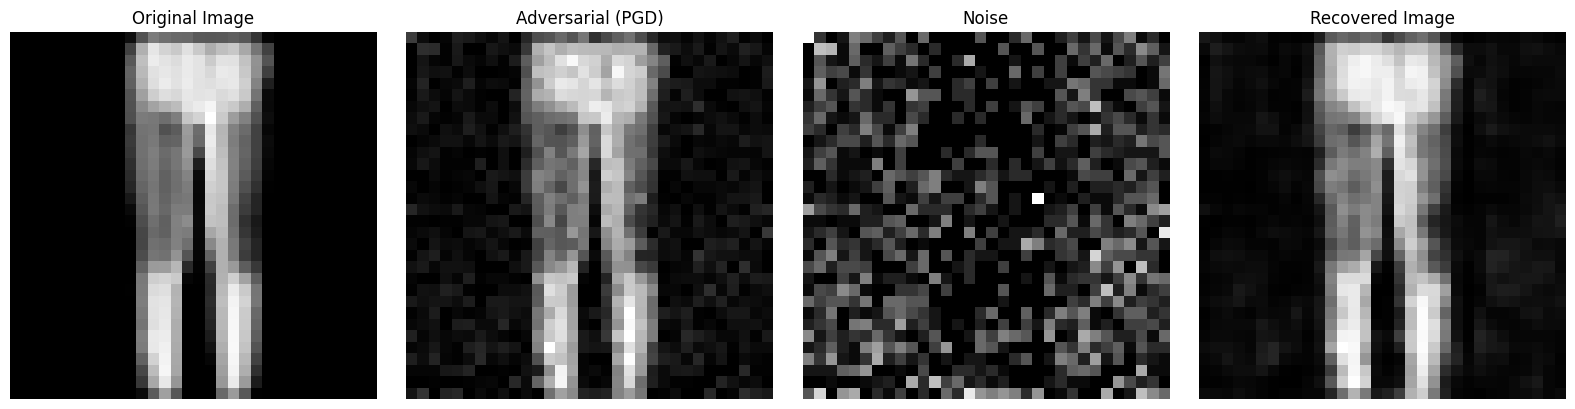

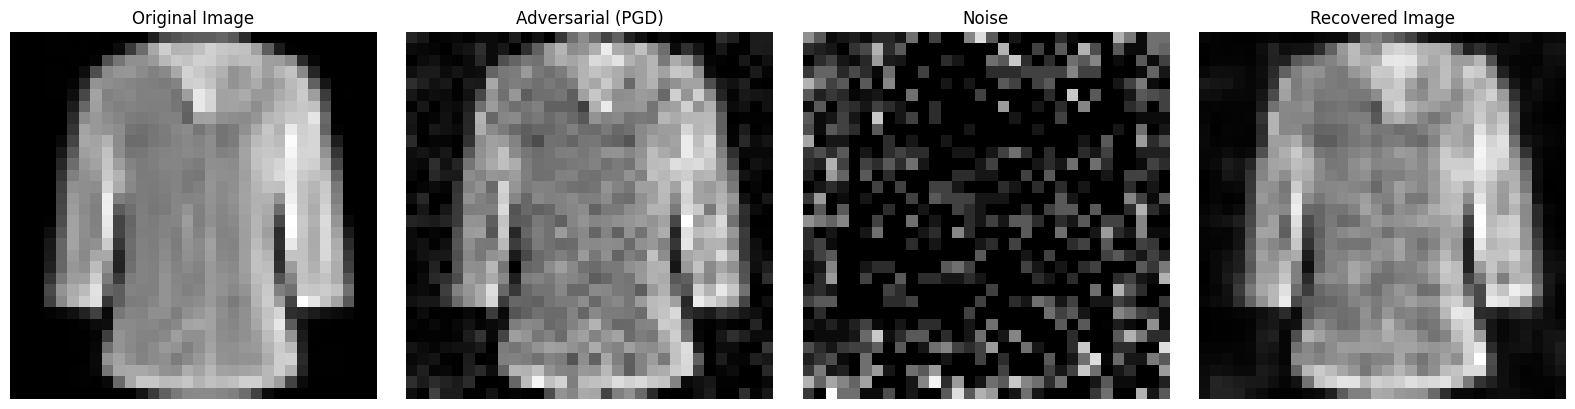

In [ ]:
# Hiển thị hình ảnh gốc, tấn công và phục hồi
print("Visualizing Original Data...")
visualize_images(model, convAE, test_loader, attack_type=None, num_samples=5)

print("Visualizing FGSM Attack...")
visualize_images(model, convAE, test_loader, attack_type='fgsm', eps=0.3, num_samples=5)

print("Visualizing PGD Attack...")
visualize_images(model, convAE, test_loader, attack_type='pgd', eps=0.3, alpha=0.01, iters=40, num_samples=5)

In [ ]:
def visualize_images_with_epsilons(model, convAE, test_loader, attack_type=None, eps_list=None, alpha=0.01, iters=40, num_samples=5):
    """
    Hiển thị hình ảnh gốc, tấn công, nhiễu, và phục hồi với nhiều giá trị epsilon.
    - attack_type: None, 'fgsm', 'pgd'
    - eps_list: Danh sách các giá trị epsilon để kiểm tra
    - num_samples: Số lượng hình ảnh hiển thị
    """
    model.eval()
    convAE.eval()

    if eps_list is None:
        eps_list = [0.1, 0.2, 0.3]  # Giá trị epsilon mặc định

    for eps in eps_list:
        print(f"Visualizing for epsilon: {eps}")

        count = 0
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            # Tấn công FGSM hoặc PGD nếu được yêu cầu
            if attack_type == 'fgsm':
                adv_imgs = fgsm_attack(model, imgs, labels, eps)
            elif attack_type == 'pgd':
                adv_imgs = pgd_attack(model, imgs, labels, eps, alpha, iters)
            else:
                adv_imgs = imgs

            # Phục hồi bằng Autoencoder
            rec_imgs = convAE(adv_imgs)

            # Chọn một số hình ảnh để hiển thị
            for i in range(min(num_samples, imgs.size(0))):
                original_img = imgs[i].detach().cpu().permute(1, 2, 0).numpy()
                adversarial_img = adv_imgs[i].detach().cpu().permute(1, 2, 0).numpy()
                noise_img = (adversarial_img - original_img)
                recovered_img = rec_imgs[i].detach().cpu().permute(1, 2, 0).numpy()

                # Chuyển đổi giá trị về [0, 1]
                original_img = np.clip(original_img, 0, 1)
                adversarial_img = np.clip(adversarial_img, 0, 1)
                recovered_img = np.clip(recovered_img, 0, 1)
                noise_img = np.clip(noise_img, 0, 1)

                # Tạo tiêu đề phù hợp
                attack_title = "Original" if attack_type is None else f"Adversarial ({attack_type.upper()}) - Eps: {eps}"

                # Vẽ hình ảnh
                fig, axs = plt.subplots(1, 4, figsize=(16, 4))
                axs[0].imshow(original_img.squeeze(), cmap='gray')
                axs[0].set_title("Original Image")
                axs[0].axis("off")

                axs[1].imshow(adversarial_img.squeeze(), cmap='gray')
                axs[1].set_title(attack_title)
                axs[1].axis("off")

                axs[2].imshow(noise_img.squeeze(), cmap='gray')
                axs[2].set_title("Noise")
                axs[2].axis("off")

                axs[3].imshow(recovered_img.squeeze(), cmap='gray')
                axs[3].set_title("Recovered Image")
                axs[3].axis("off")

                plt.tight_layout()
                plt.savefig(f"output_images/visualize_{attack_type}_eps_{eps}_sample_{count}.png")
                plt.show()

                count += 1
                if count >= num_samples:
                    break
            if count >= num_samples:
                break

Visualizing for epsilon: 0.1


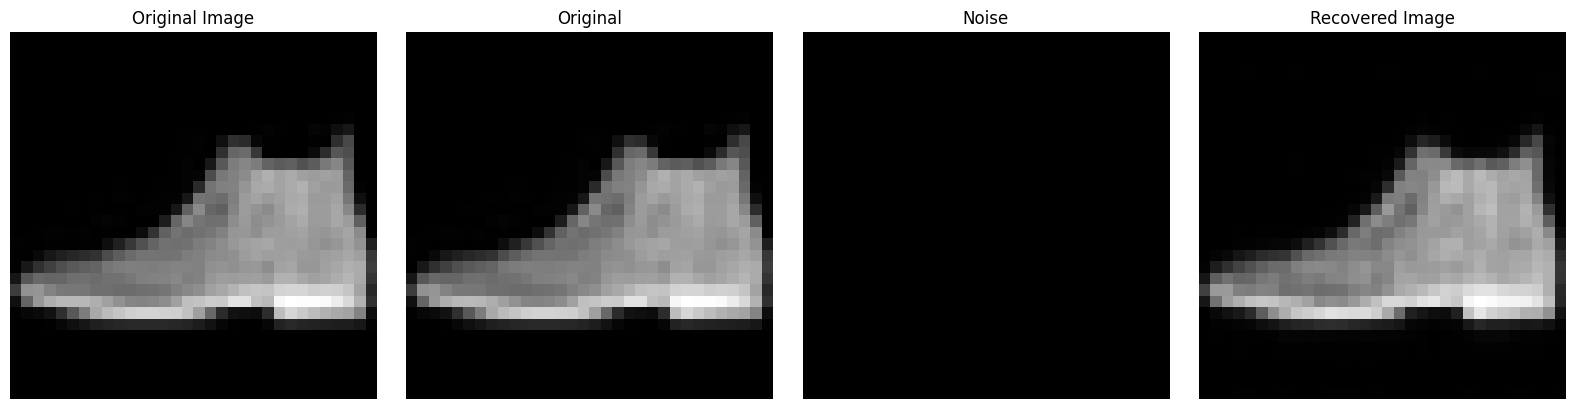

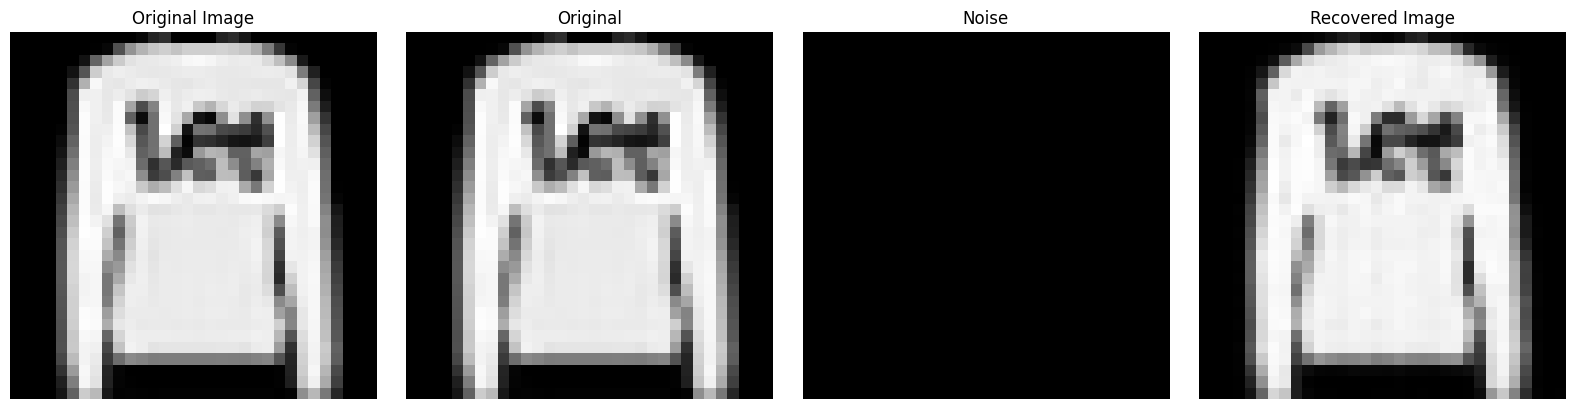

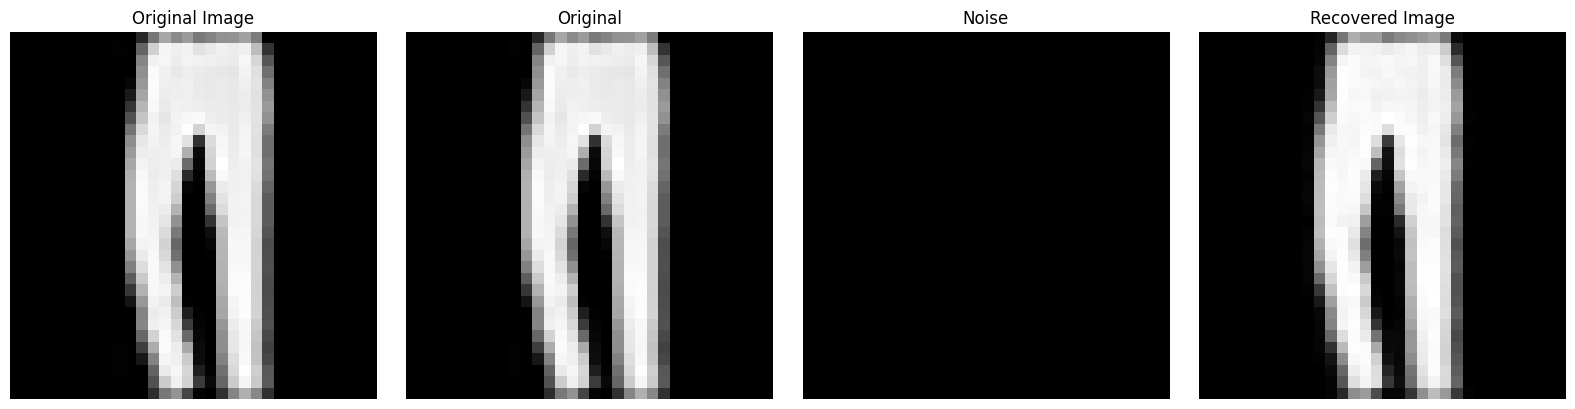

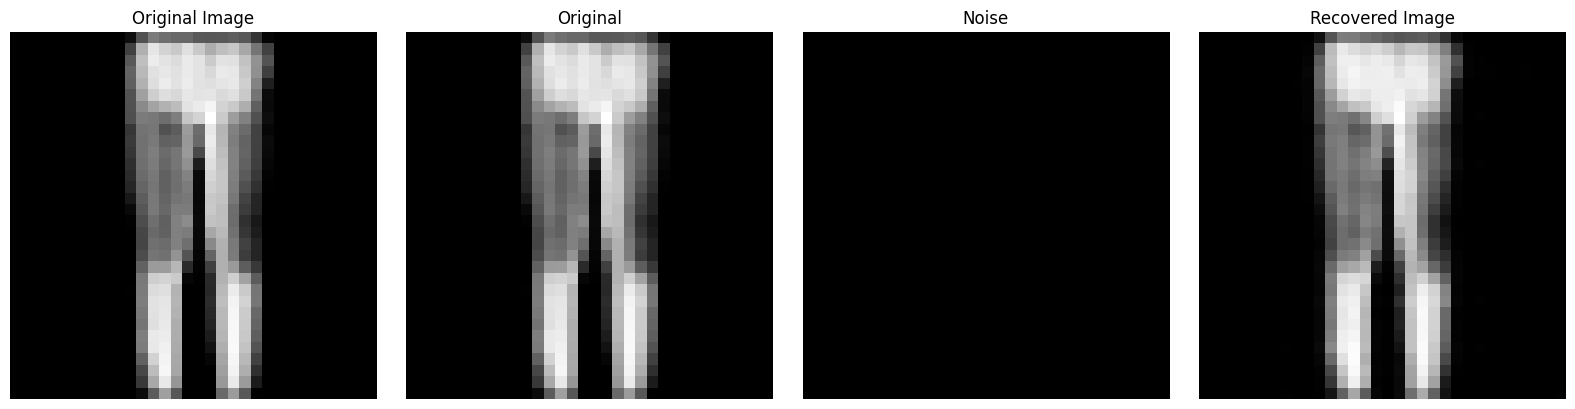

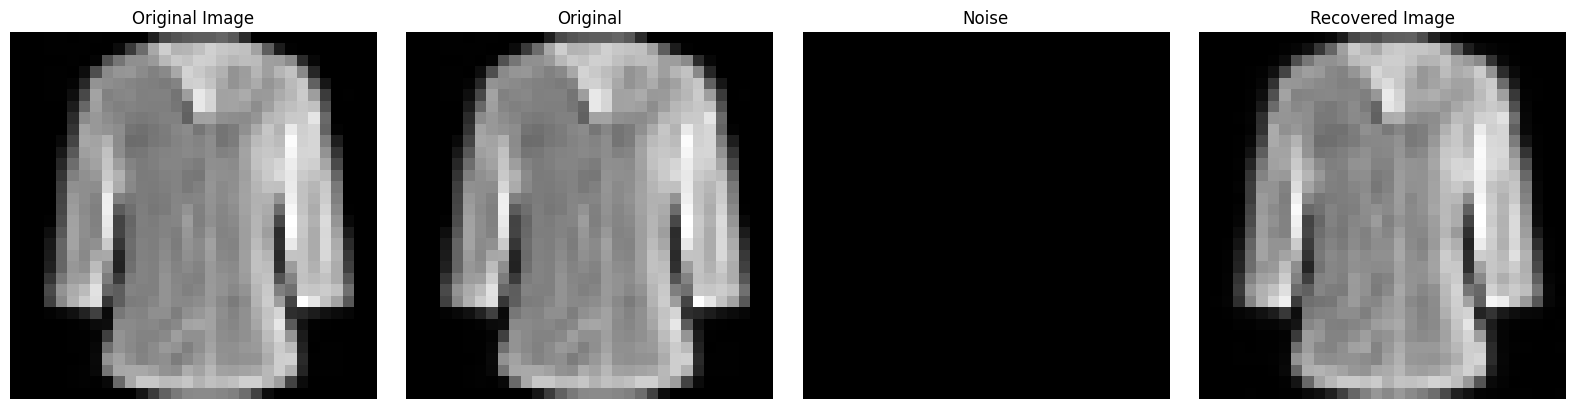

Visualizing for epsilon: 0.2


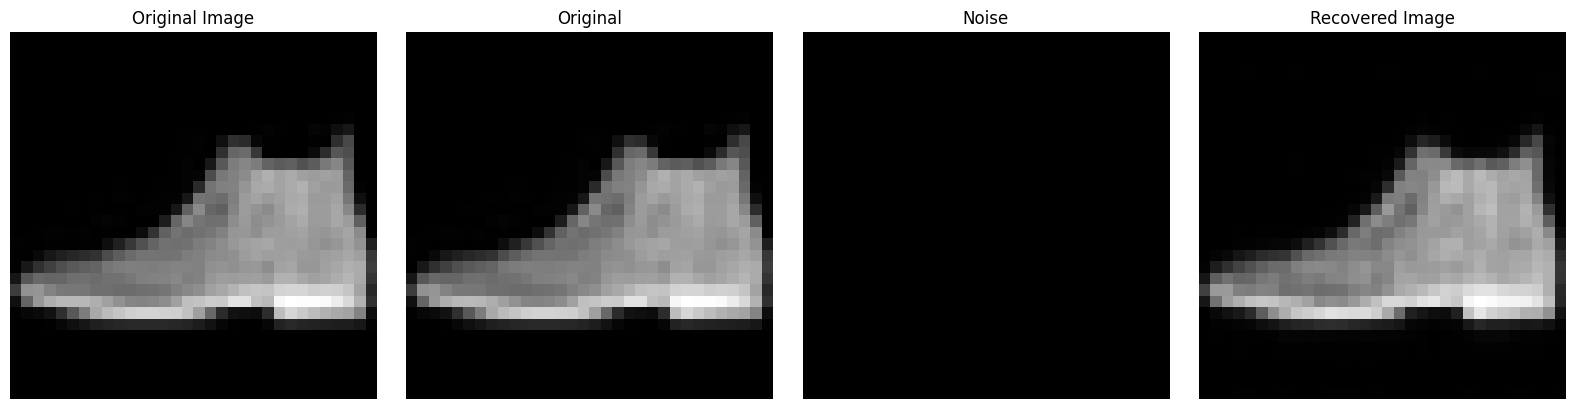

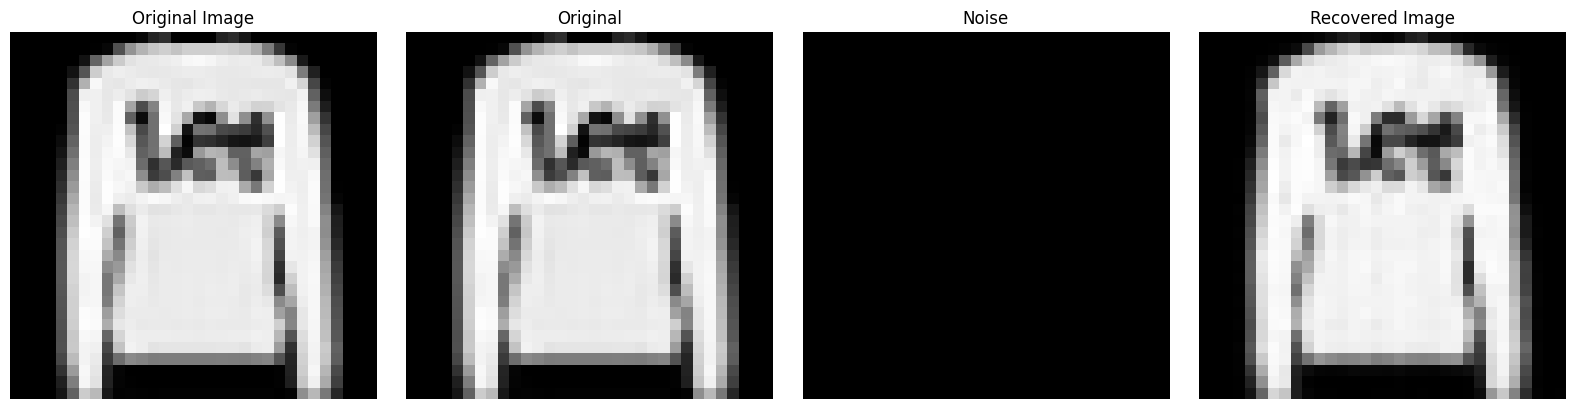

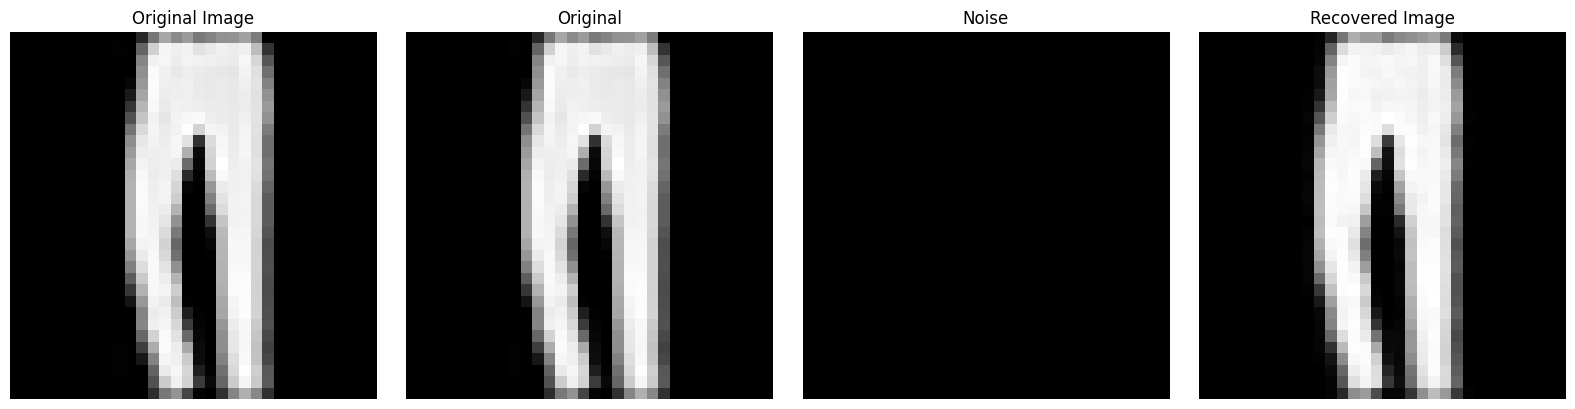

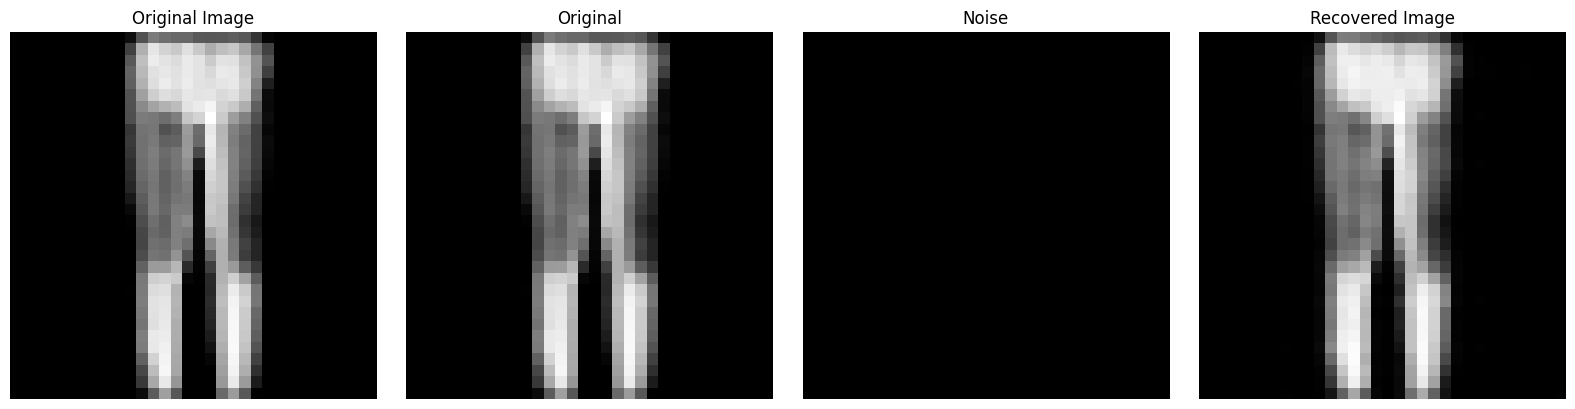

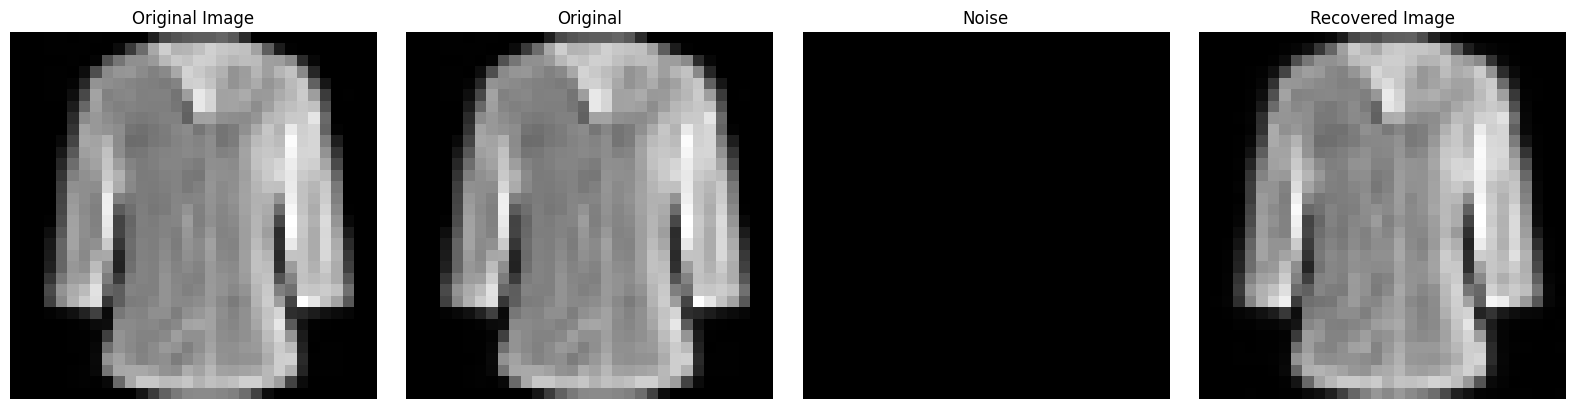

Visualizing for epsilon: 0.3


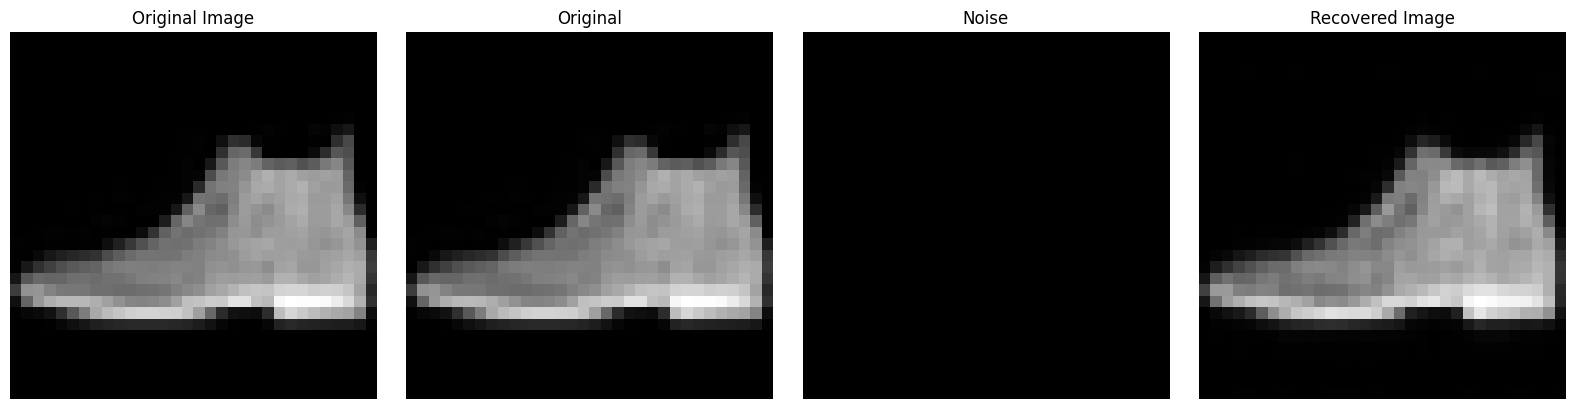

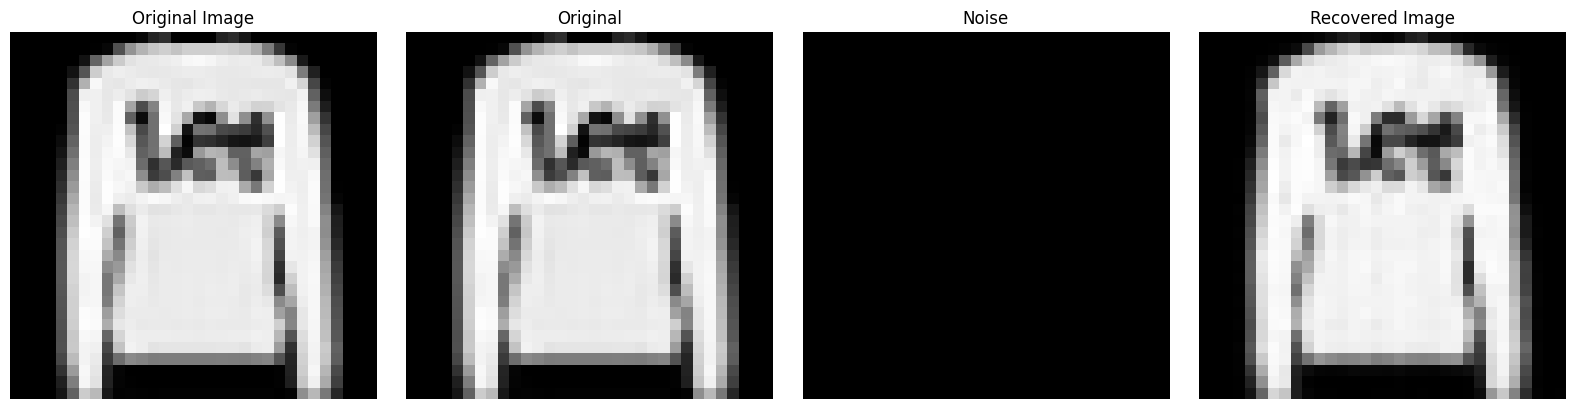

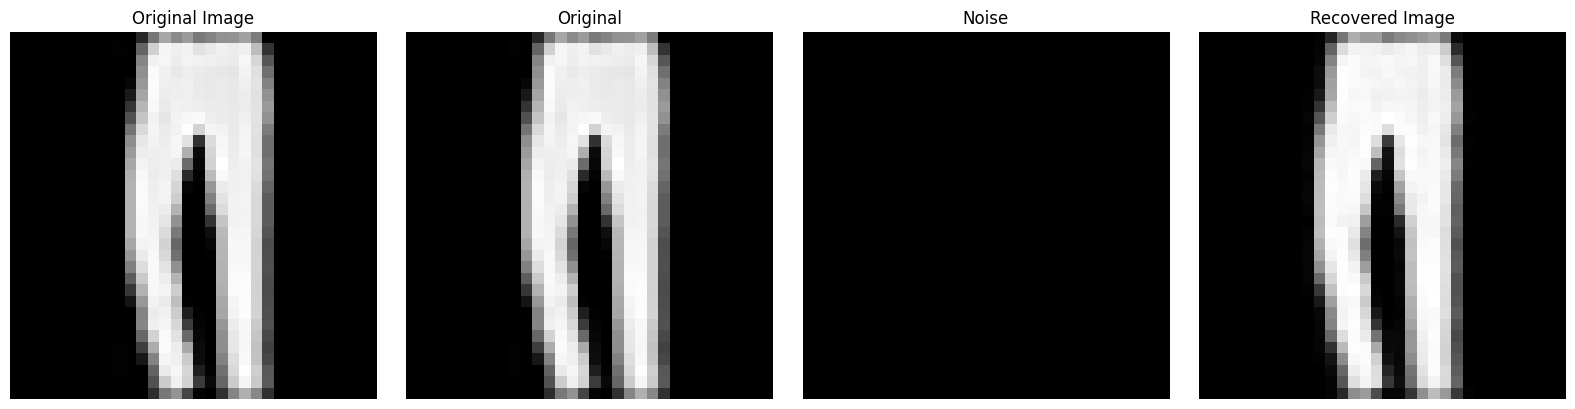

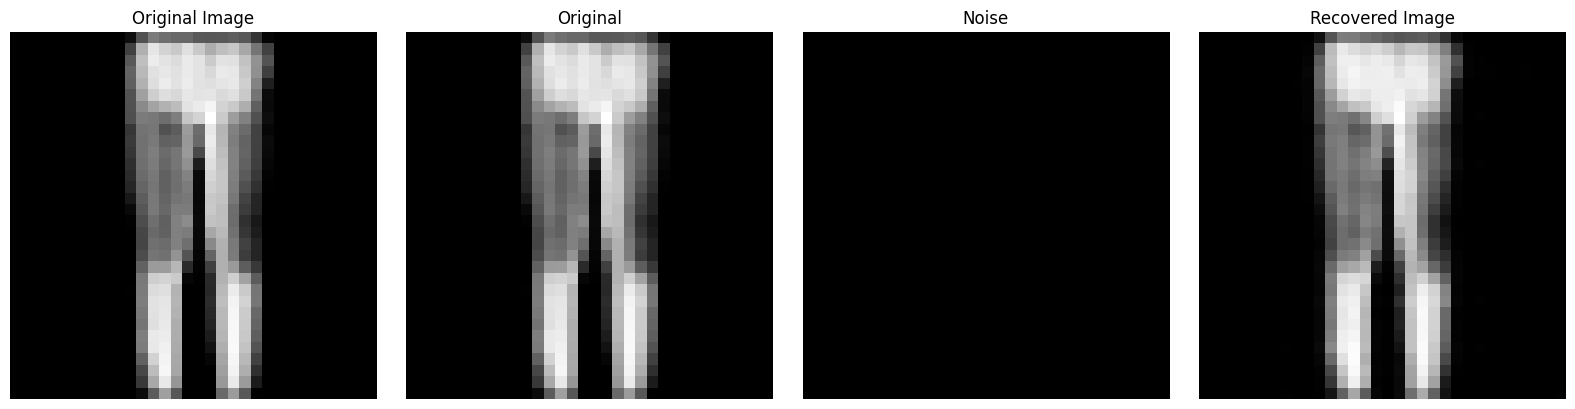

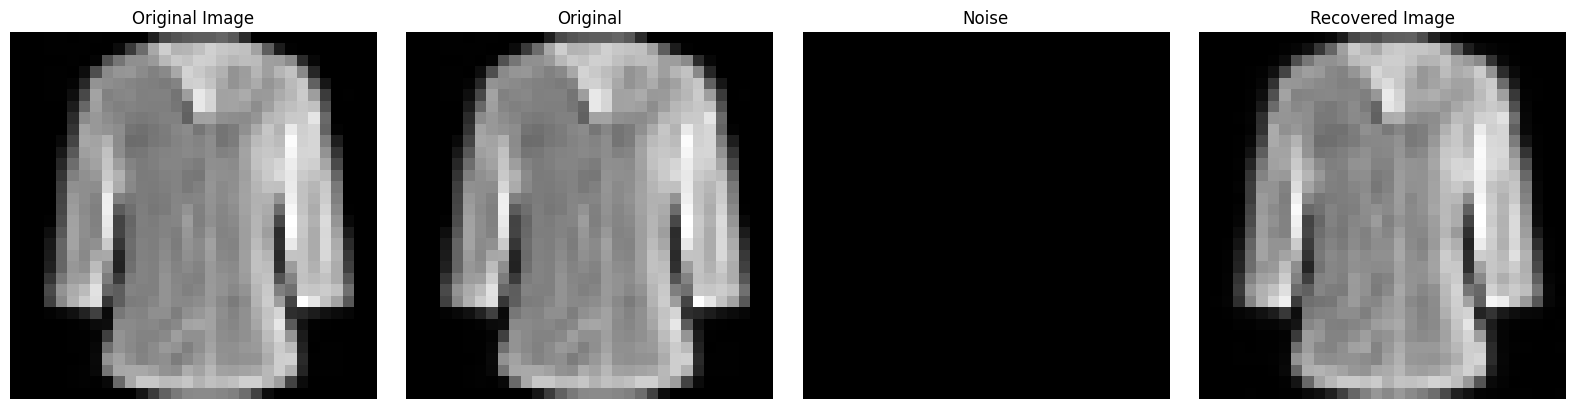

Visualizing for epsilon: 0.4


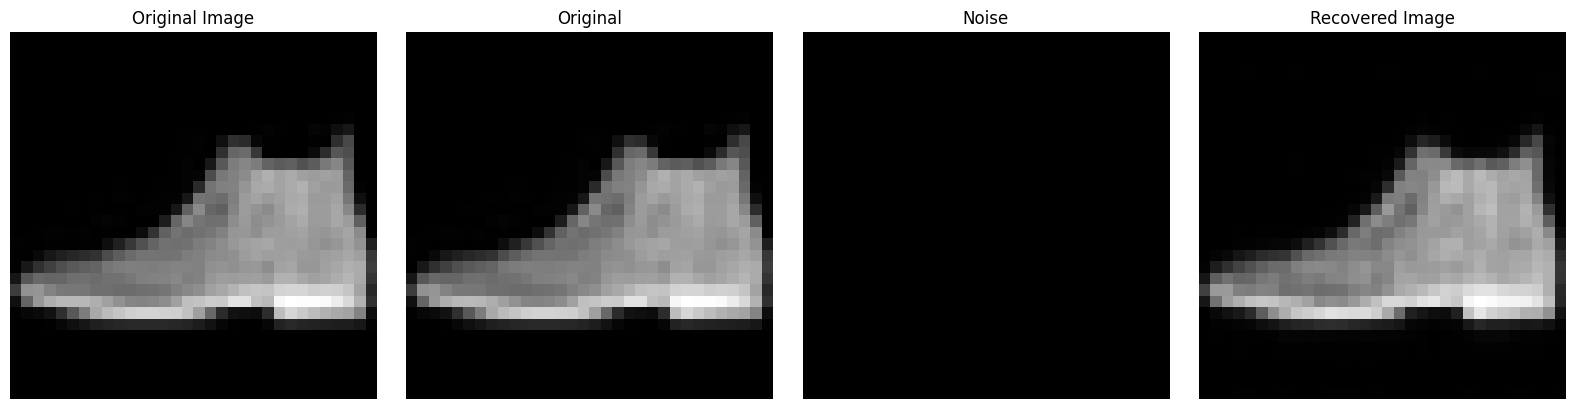

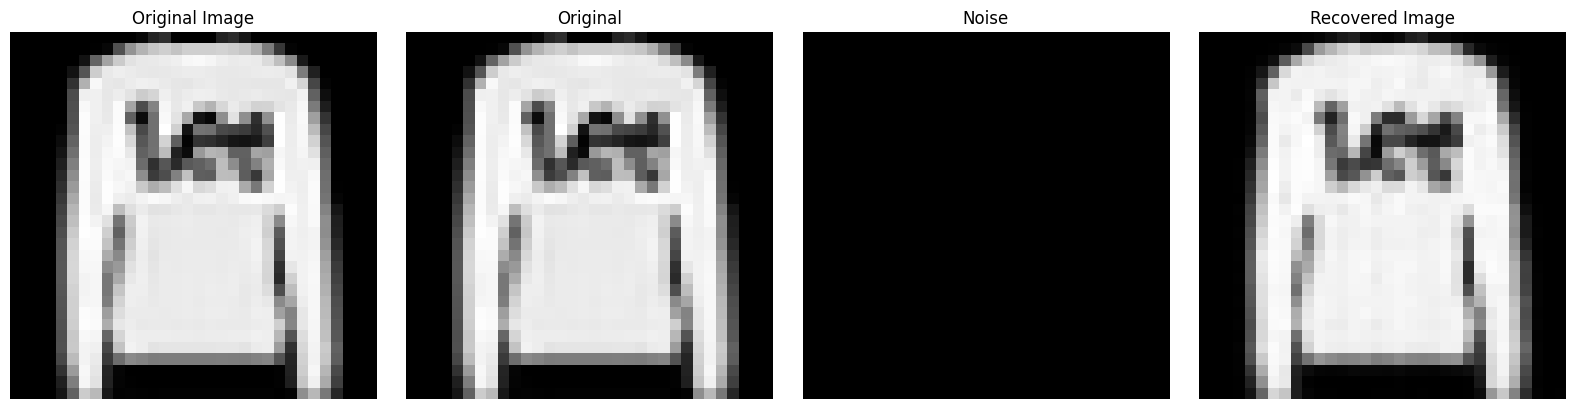

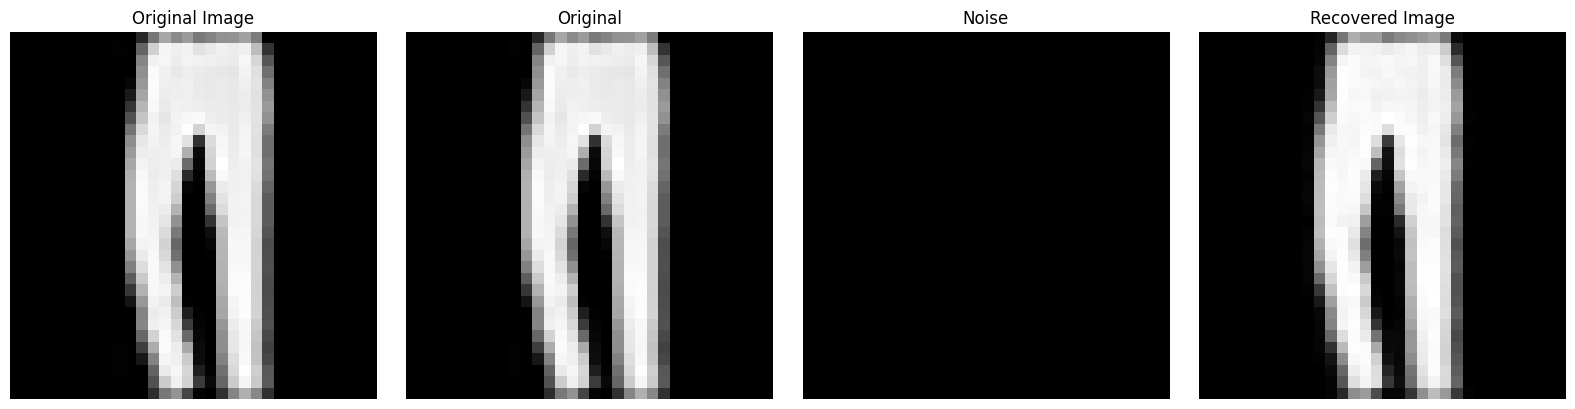

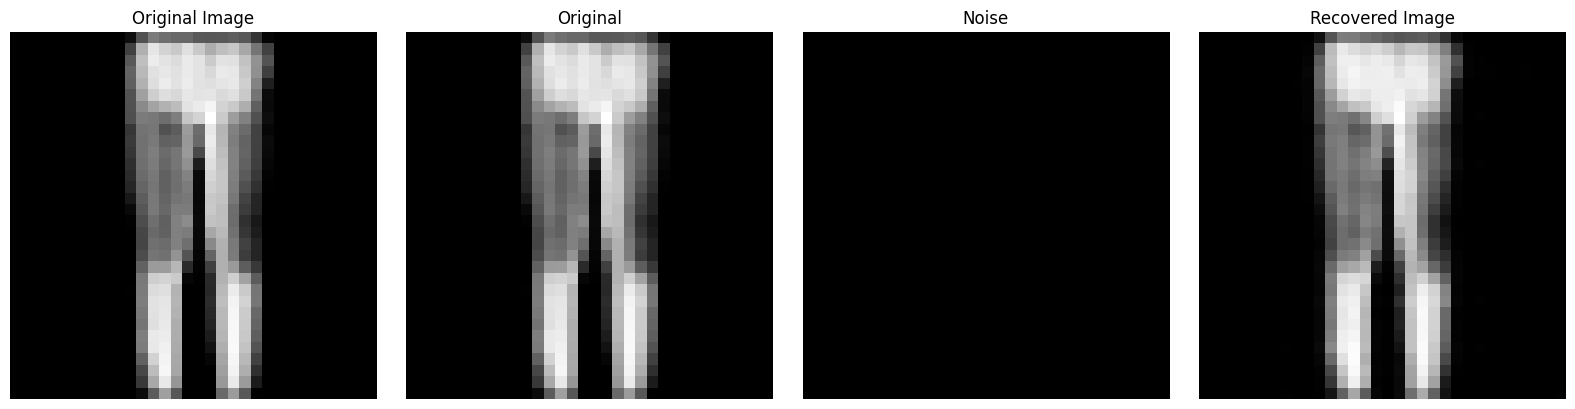

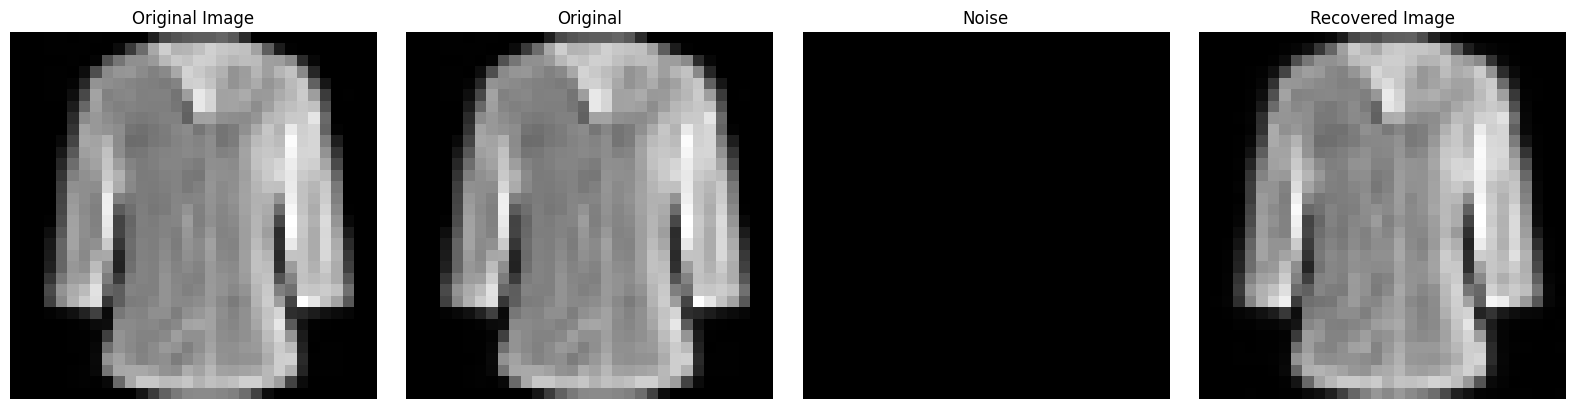

Visualizing for epsilon: 0.1


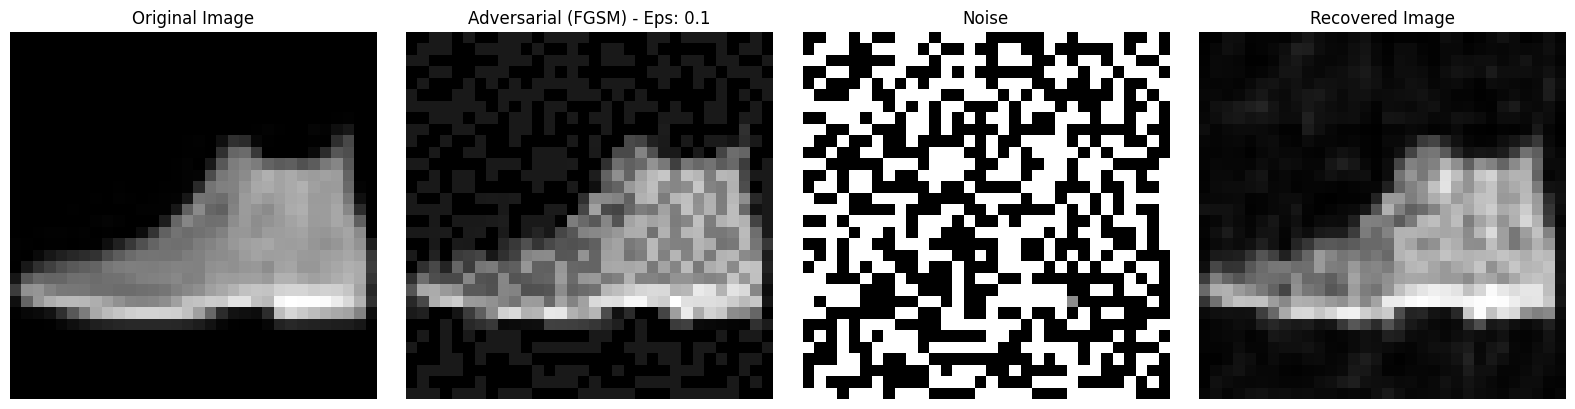

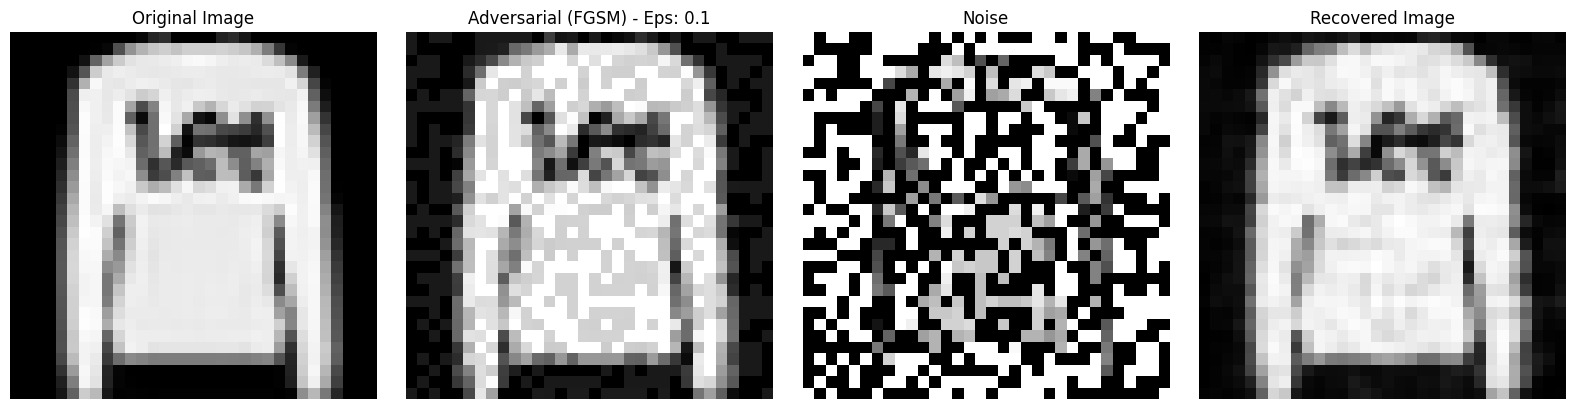

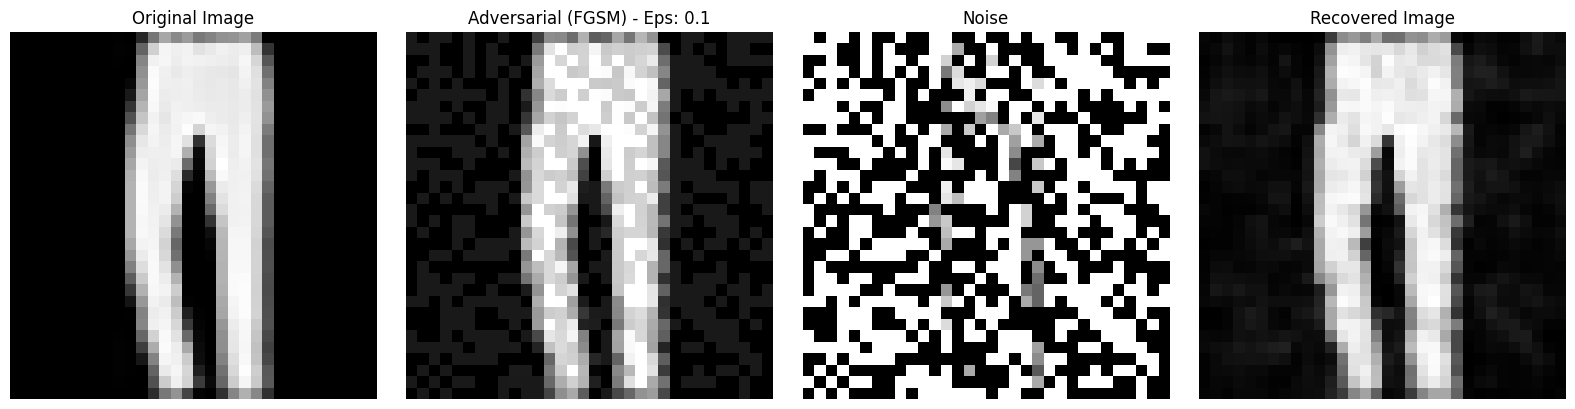

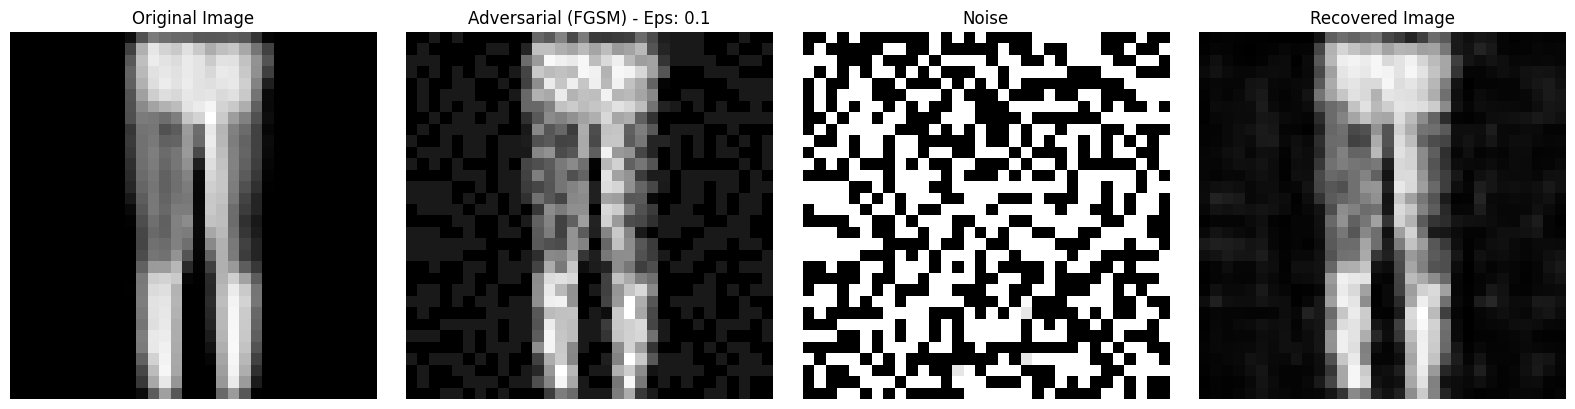

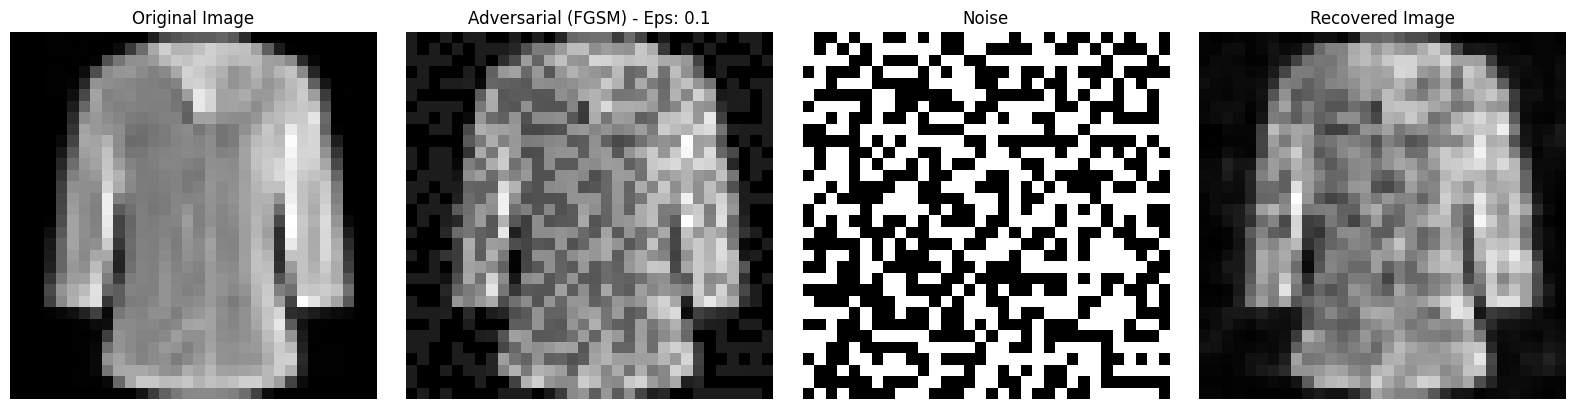

Visualizing for epsilon: 0.2


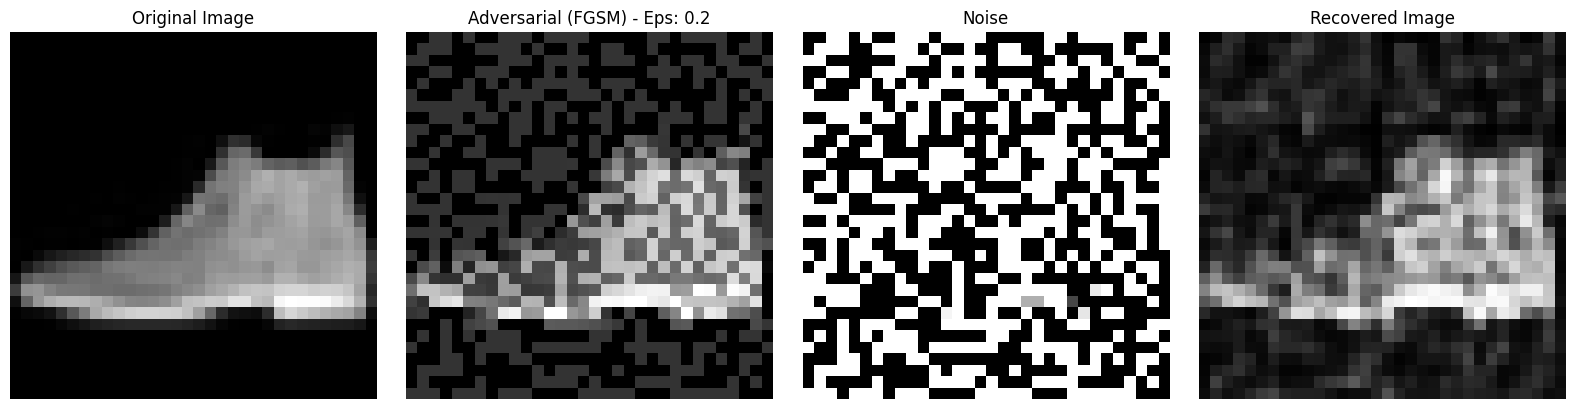

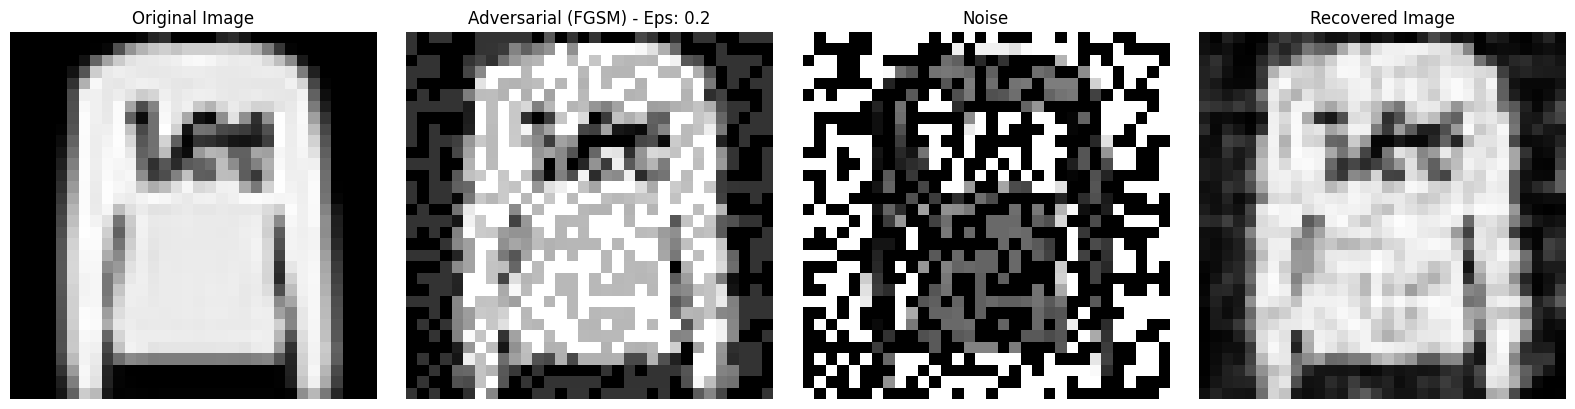

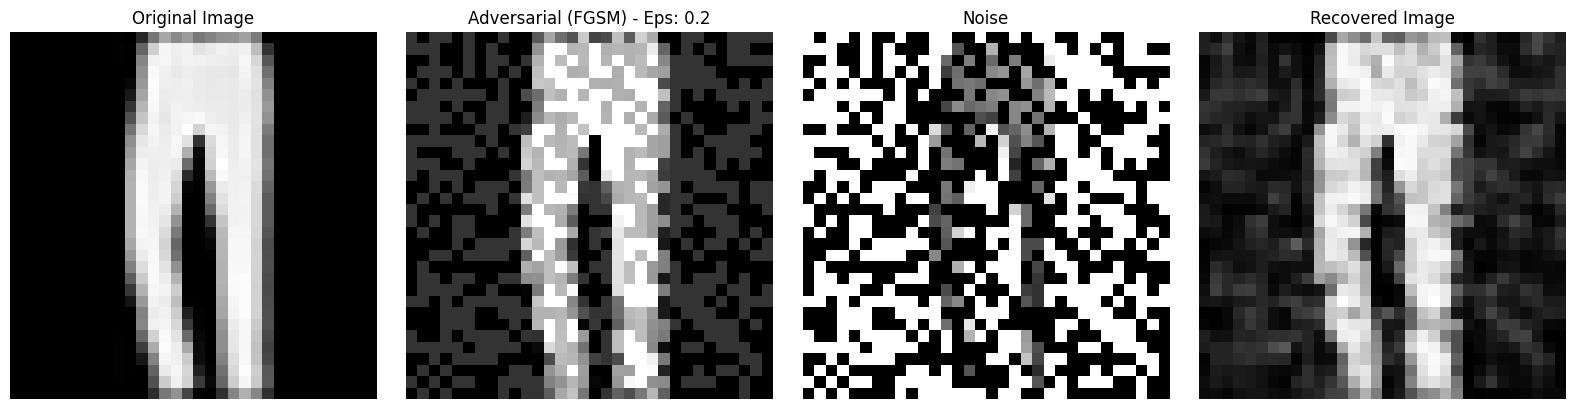

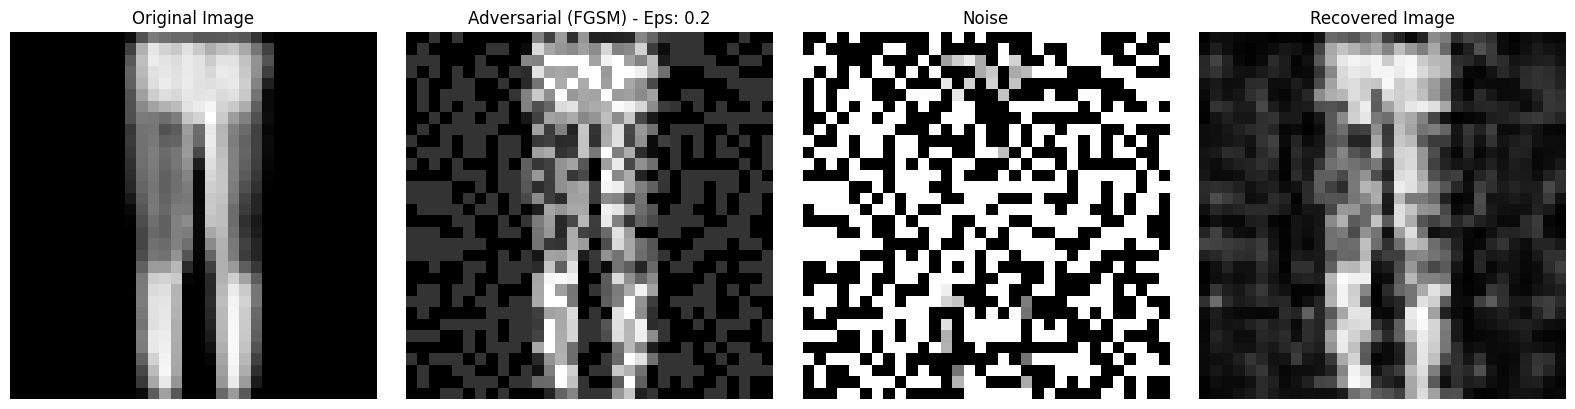

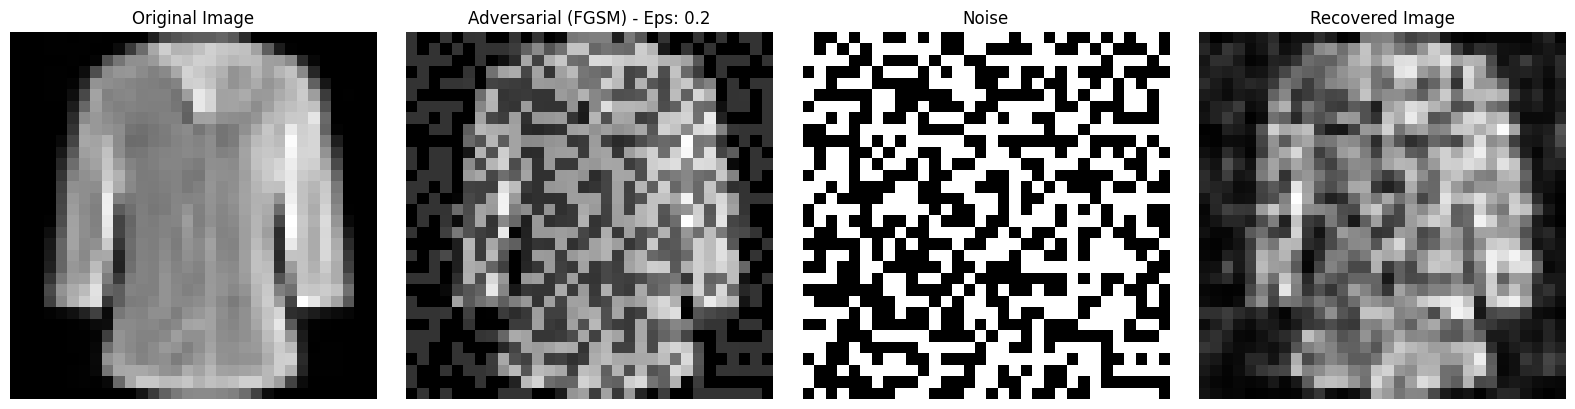

Visualizing for epsilon: 0.3


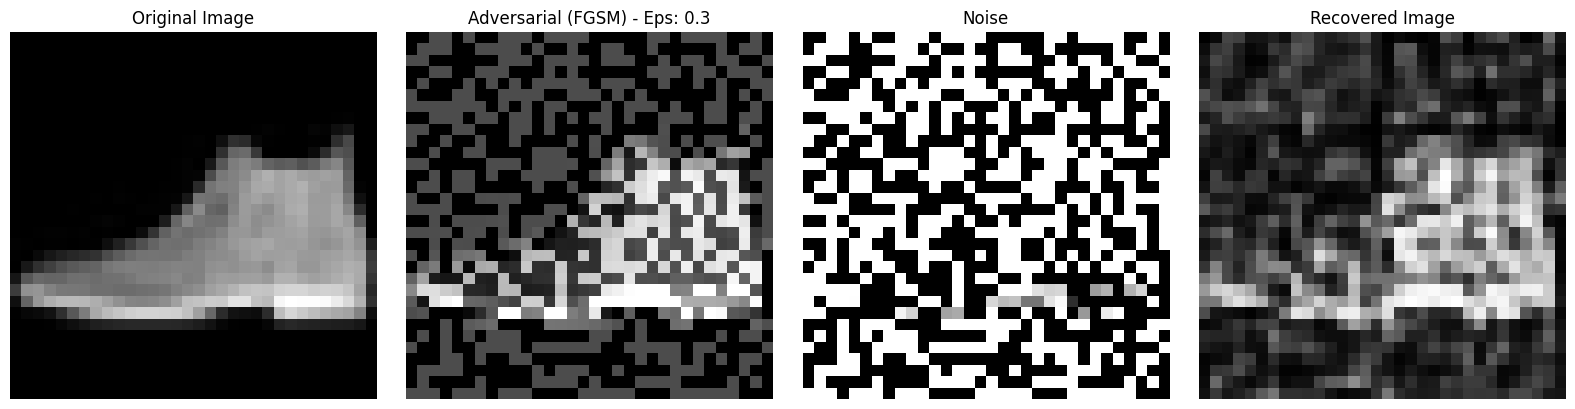

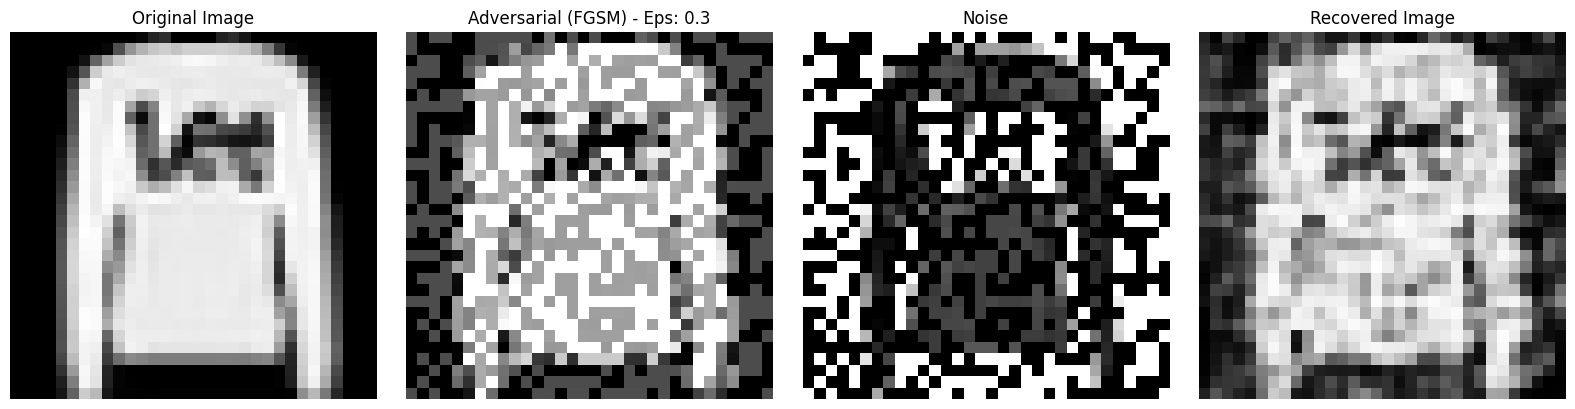

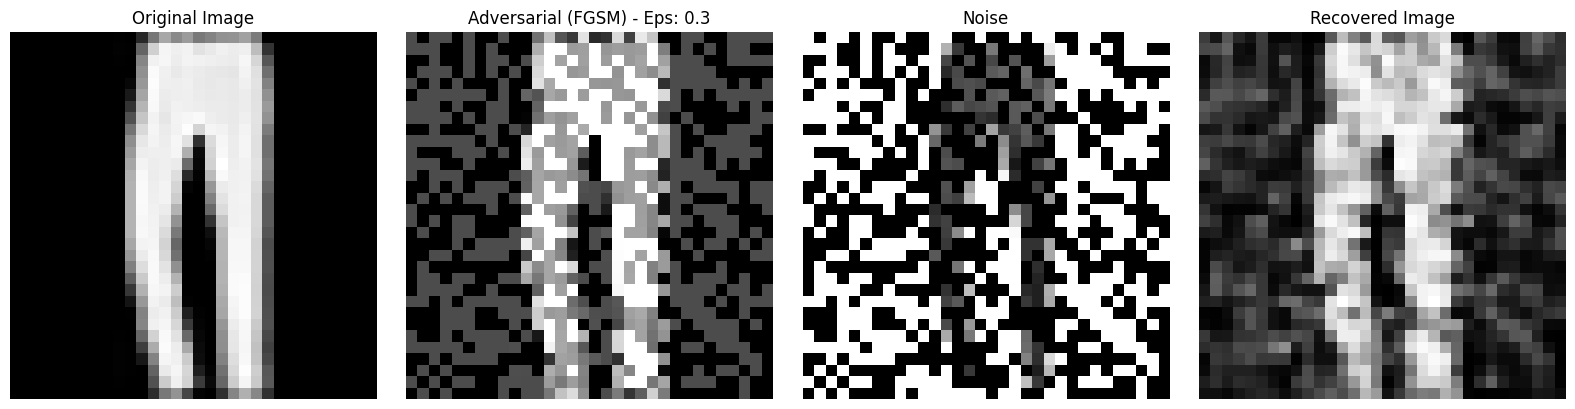

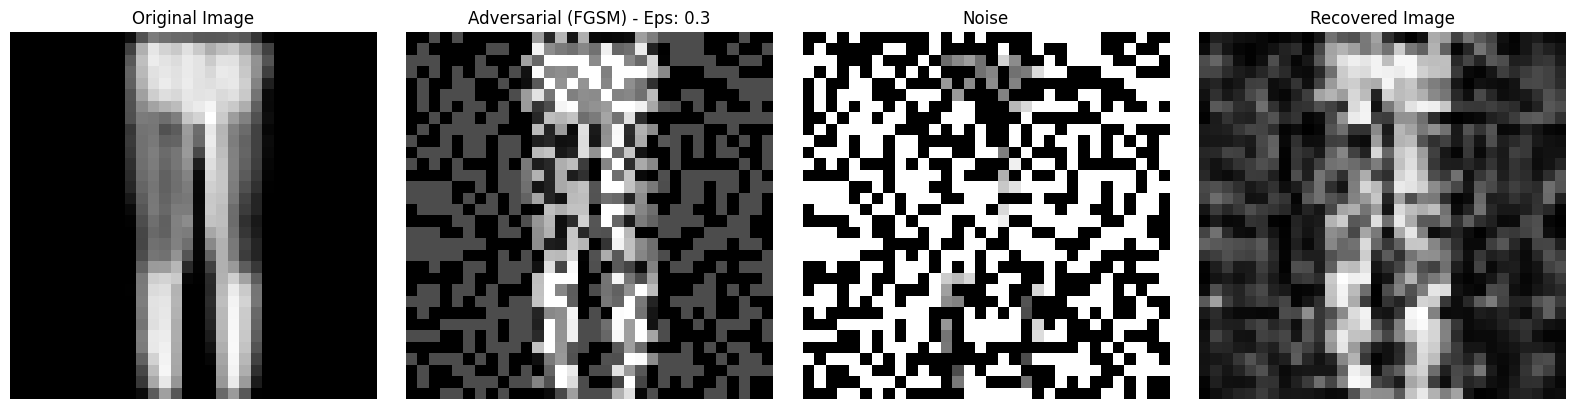

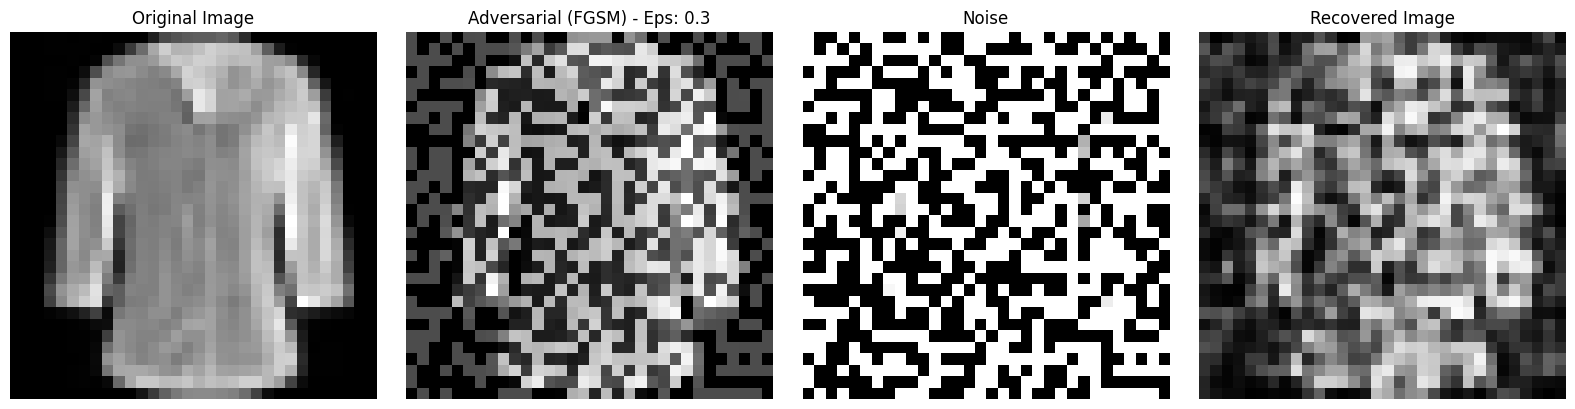

Visualizing for epsilon: 0.4


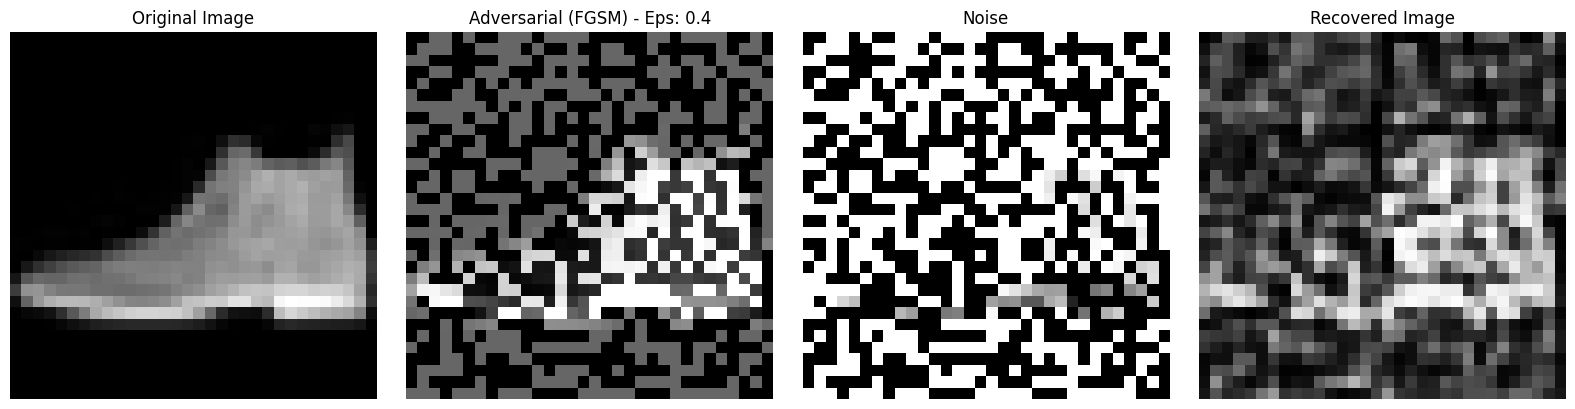

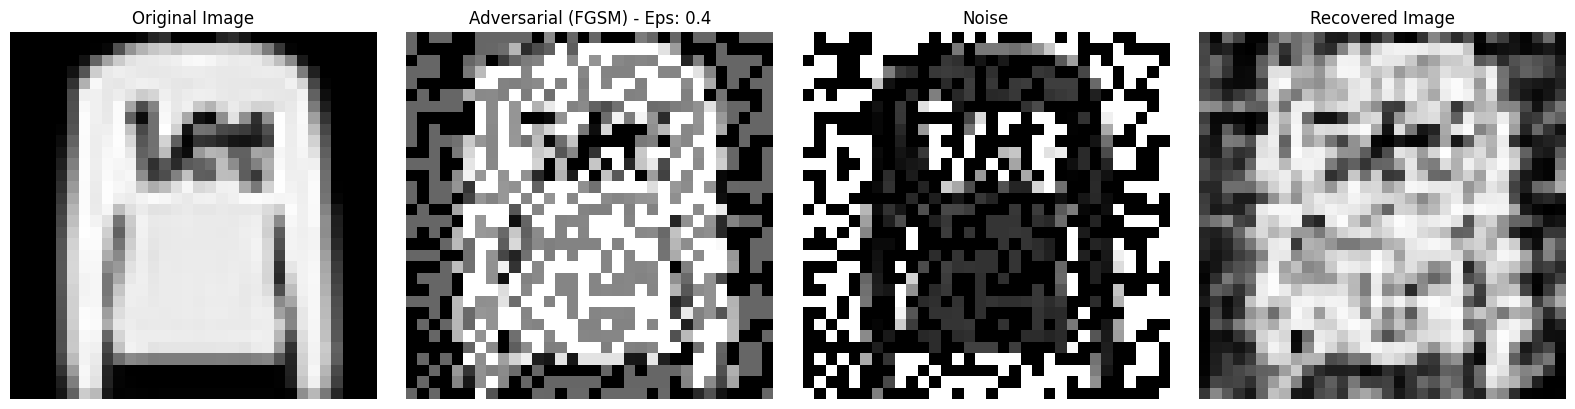

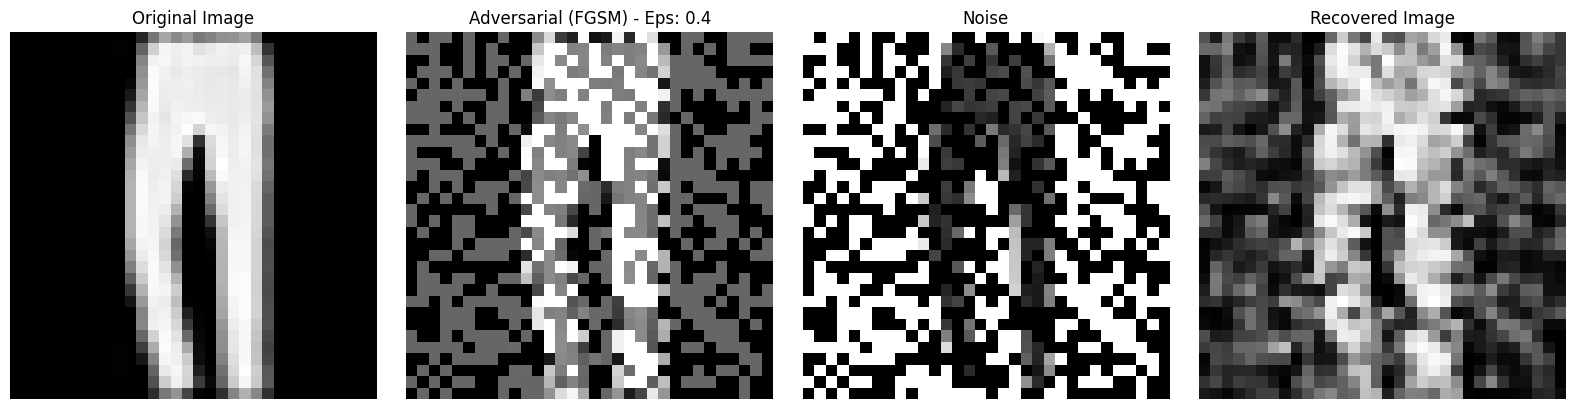

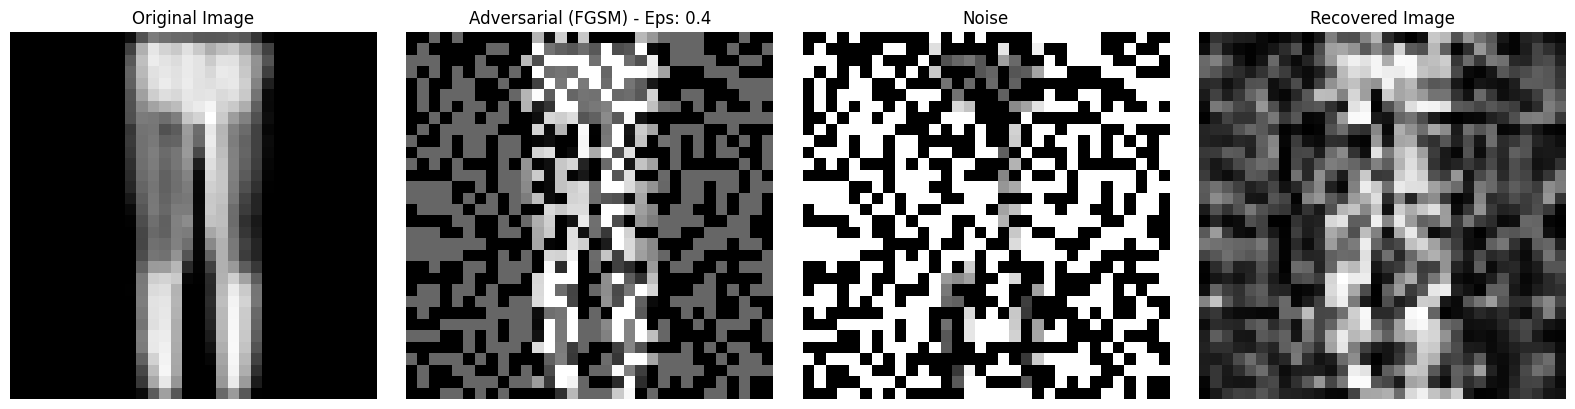

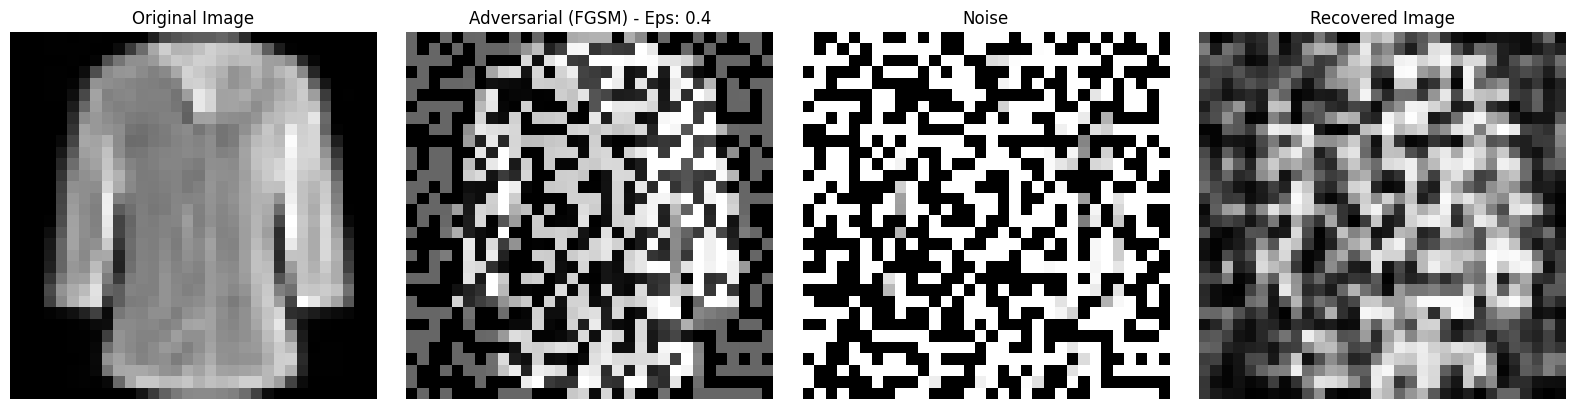

Visualizing for epsilon: 0.1


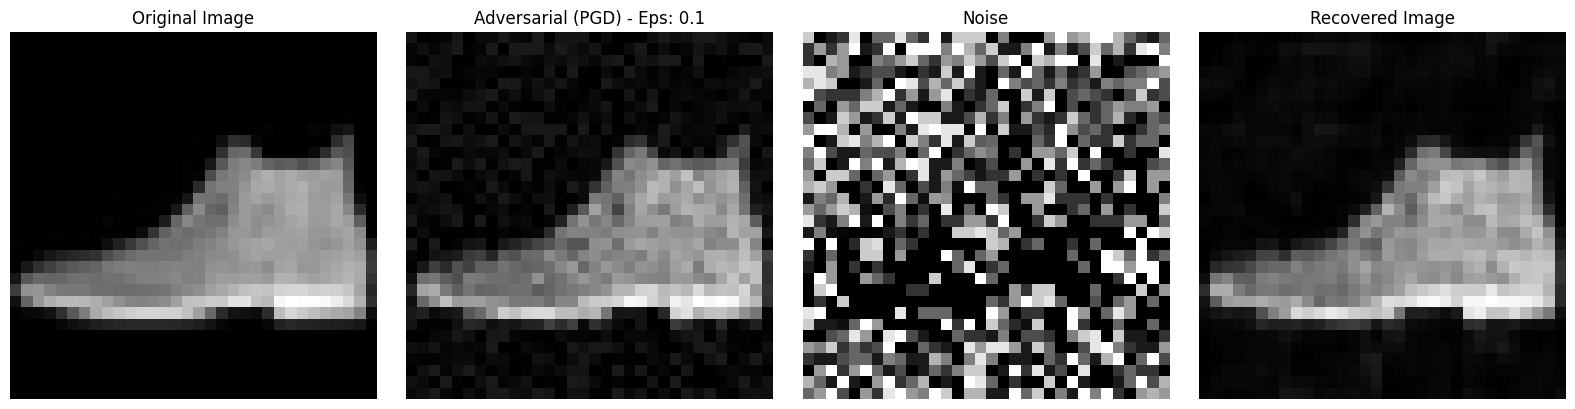

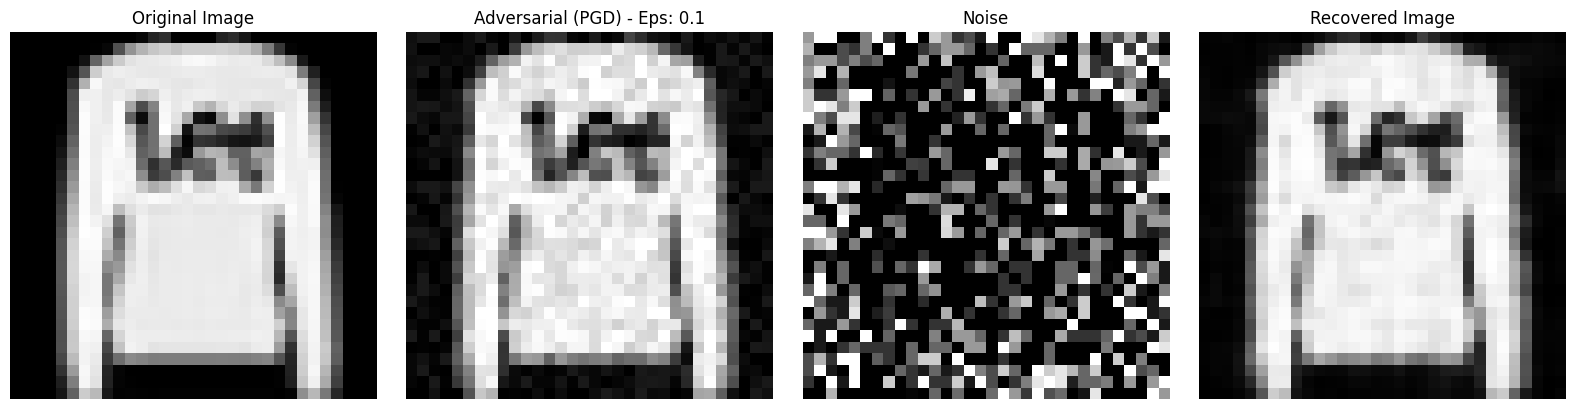

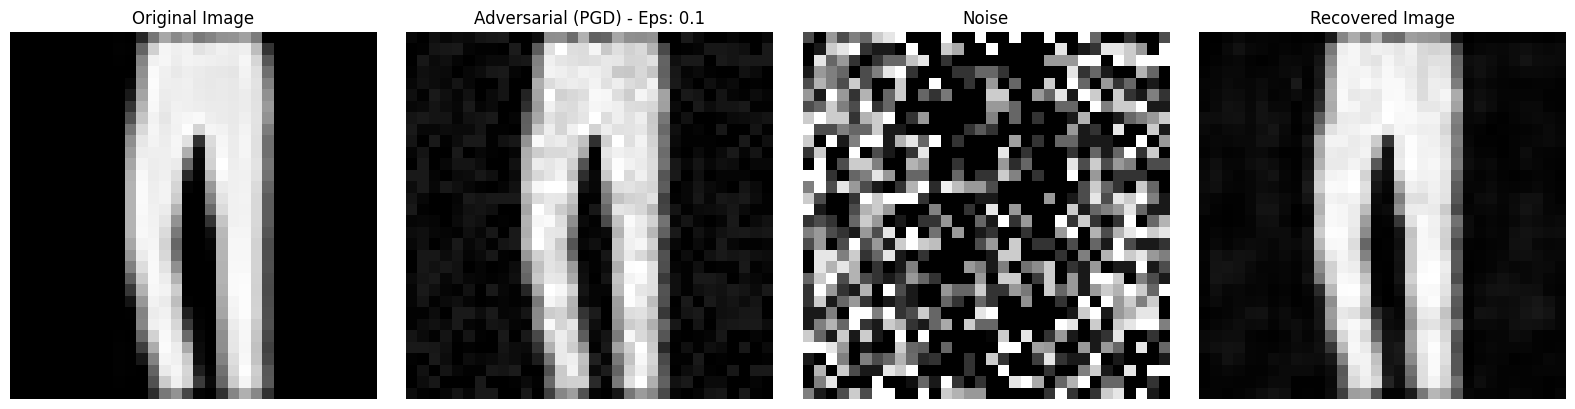

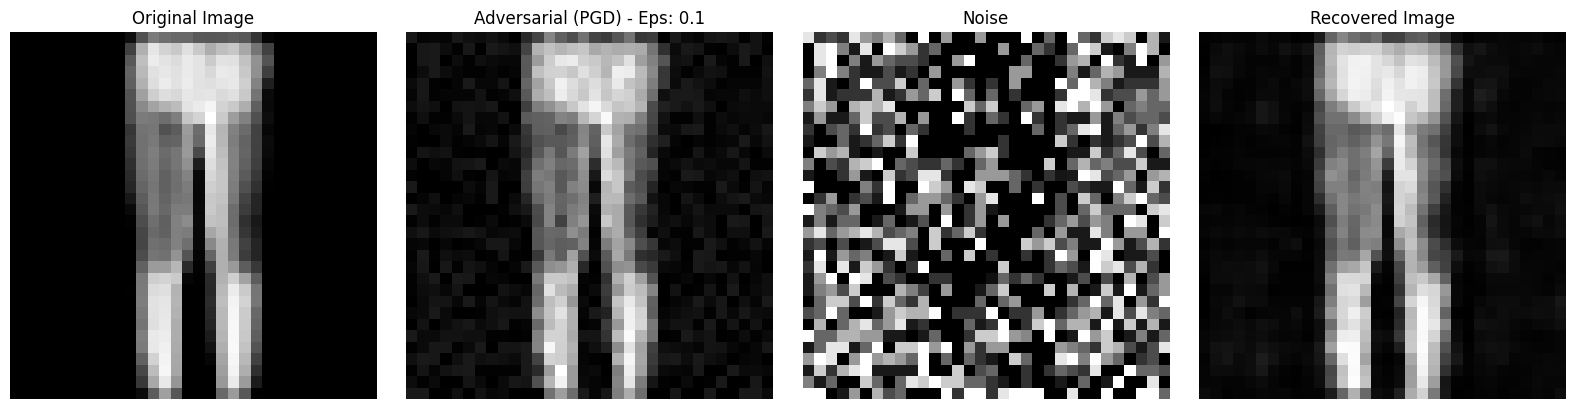

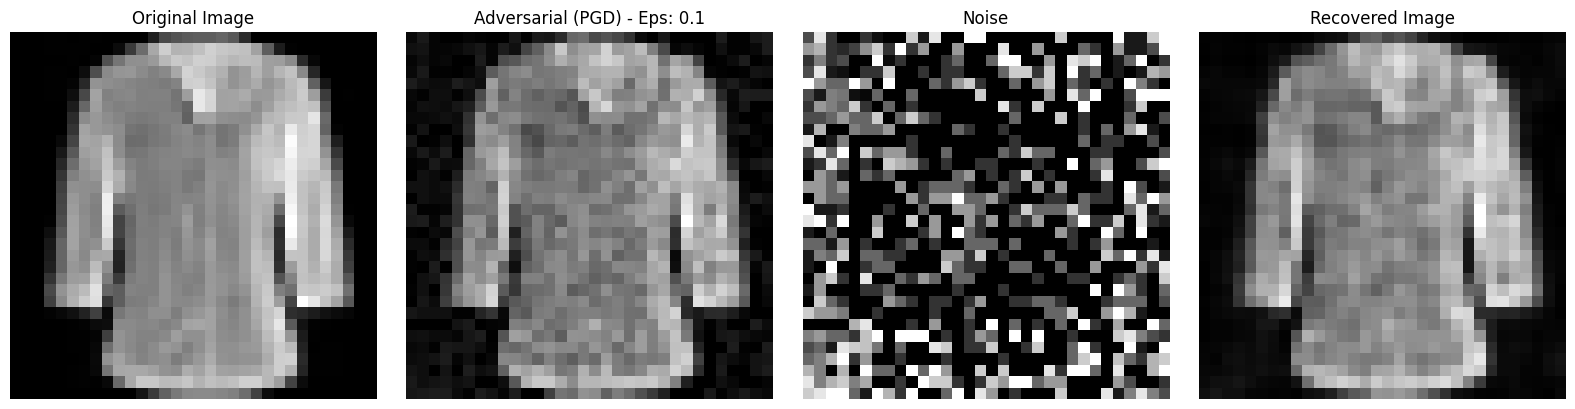

Visualizing for epsilon: 0.2


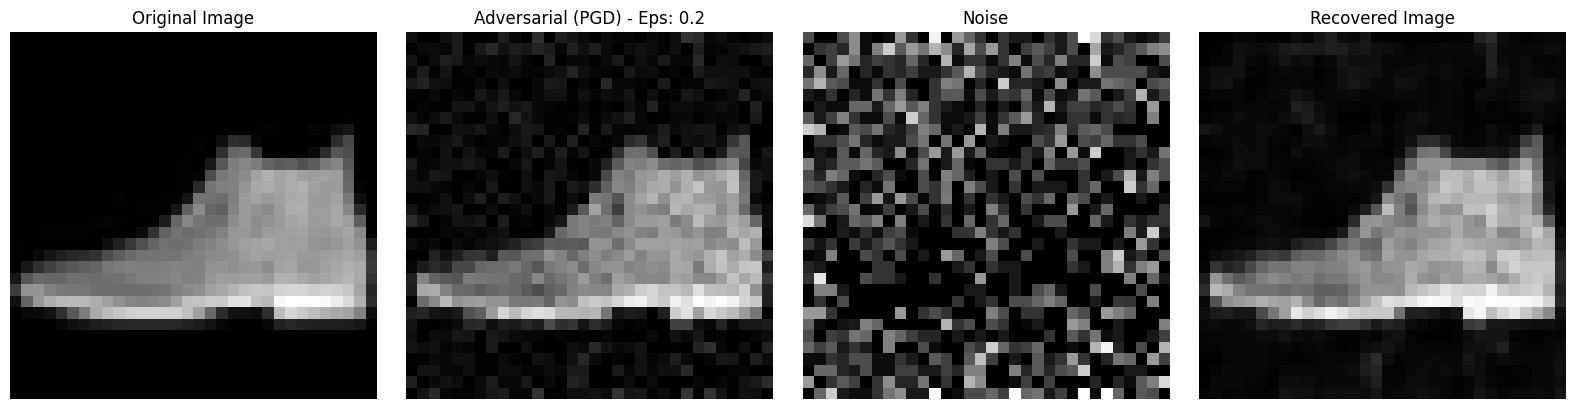

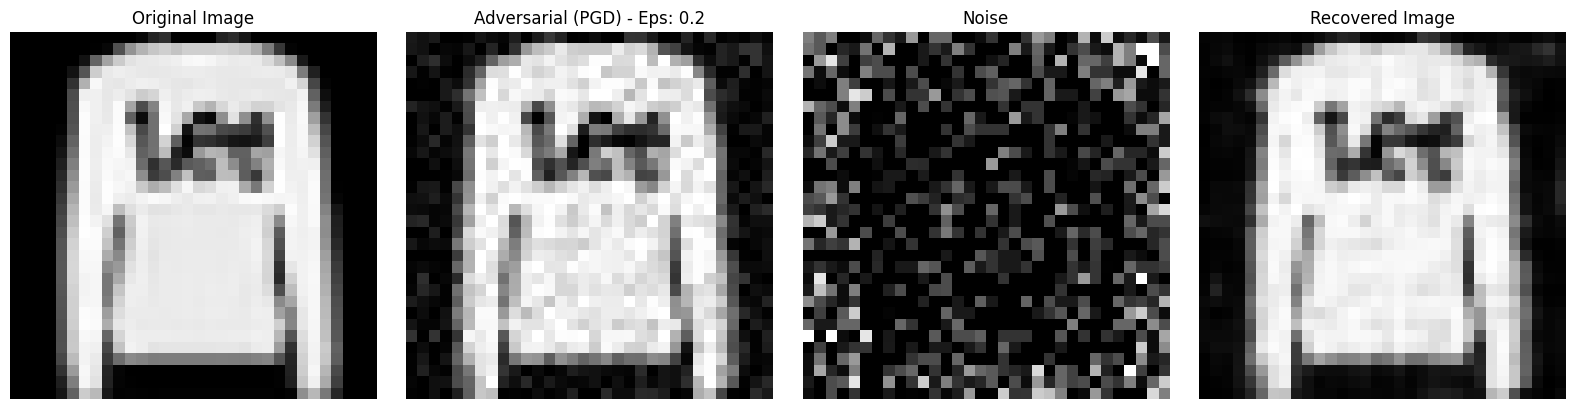

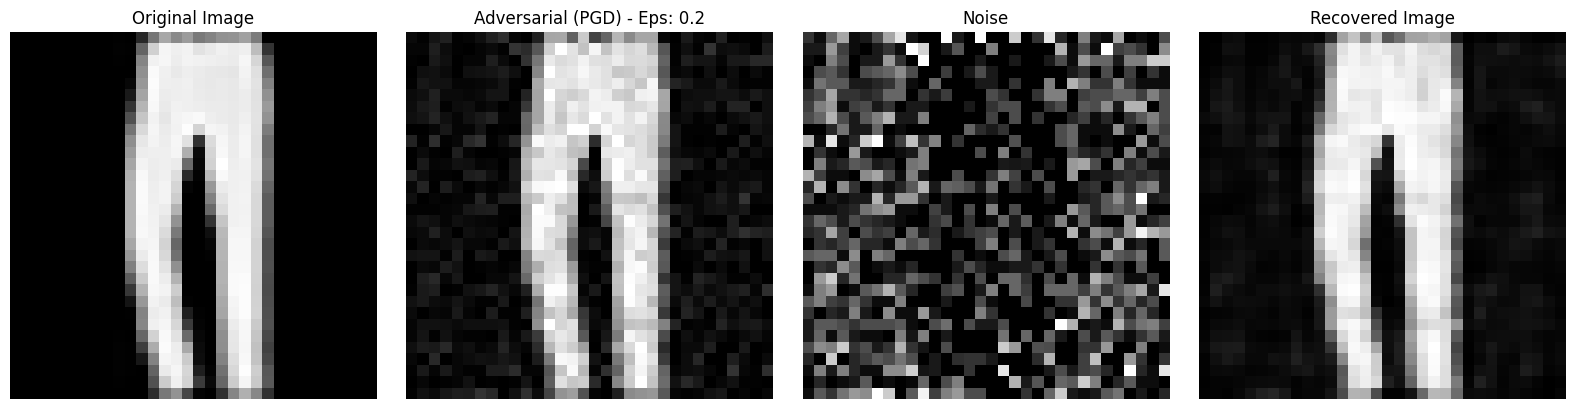

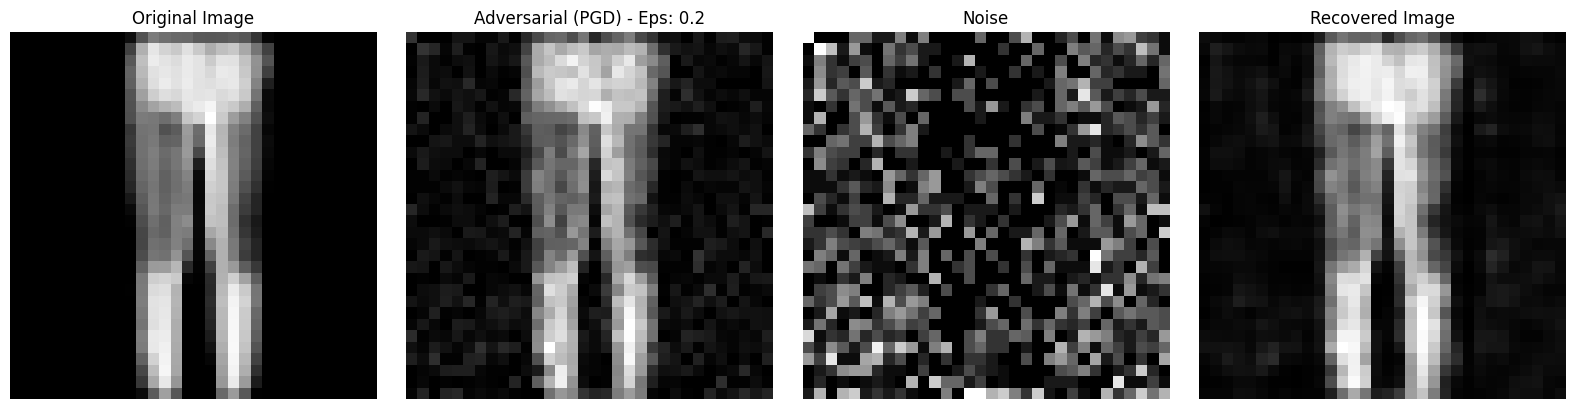

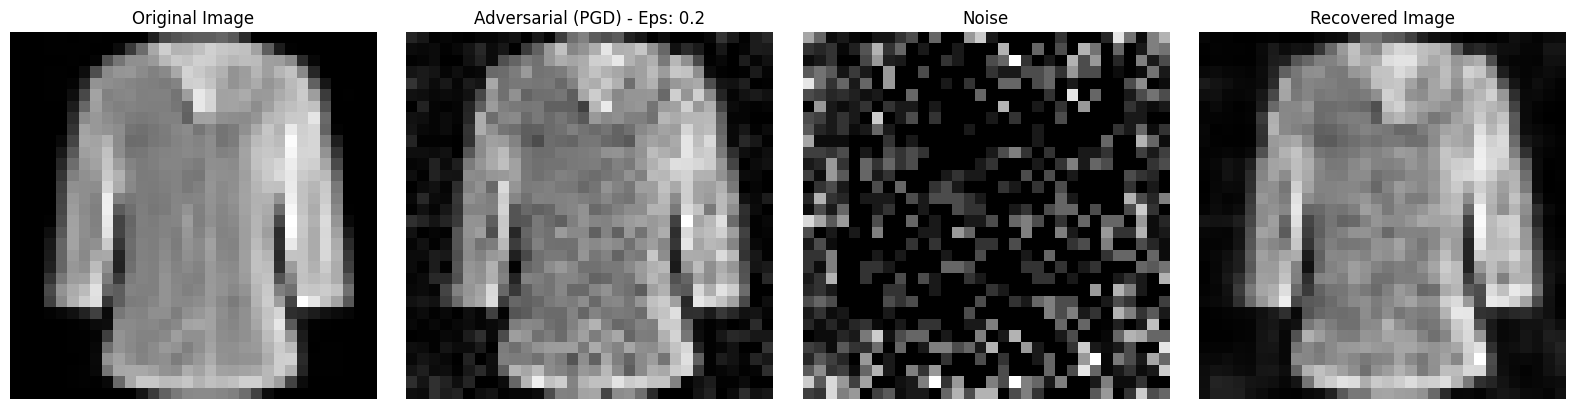

Visualizing for epsilon: 0.3


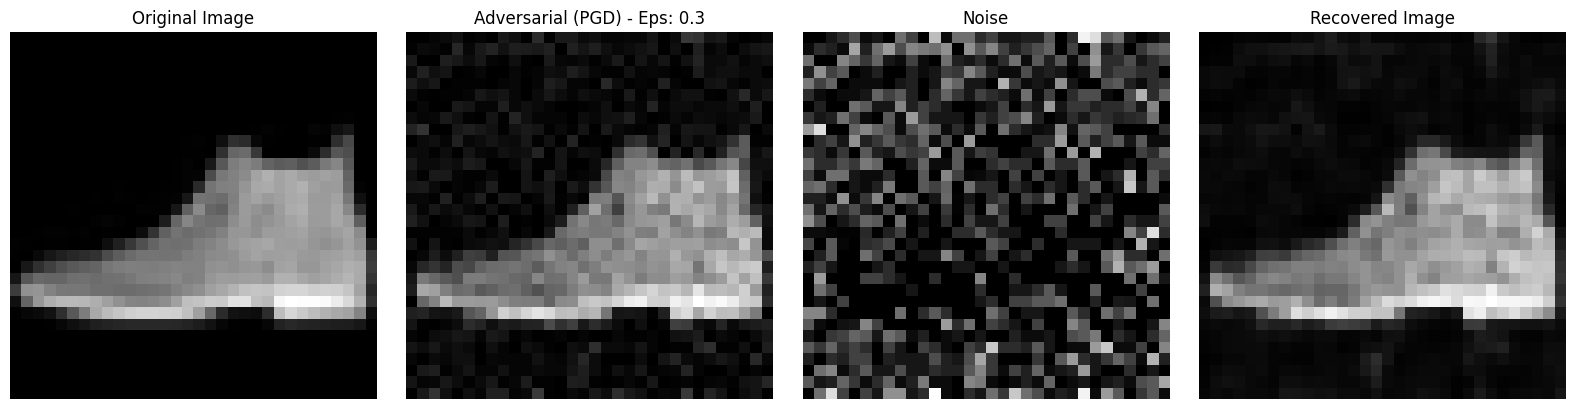

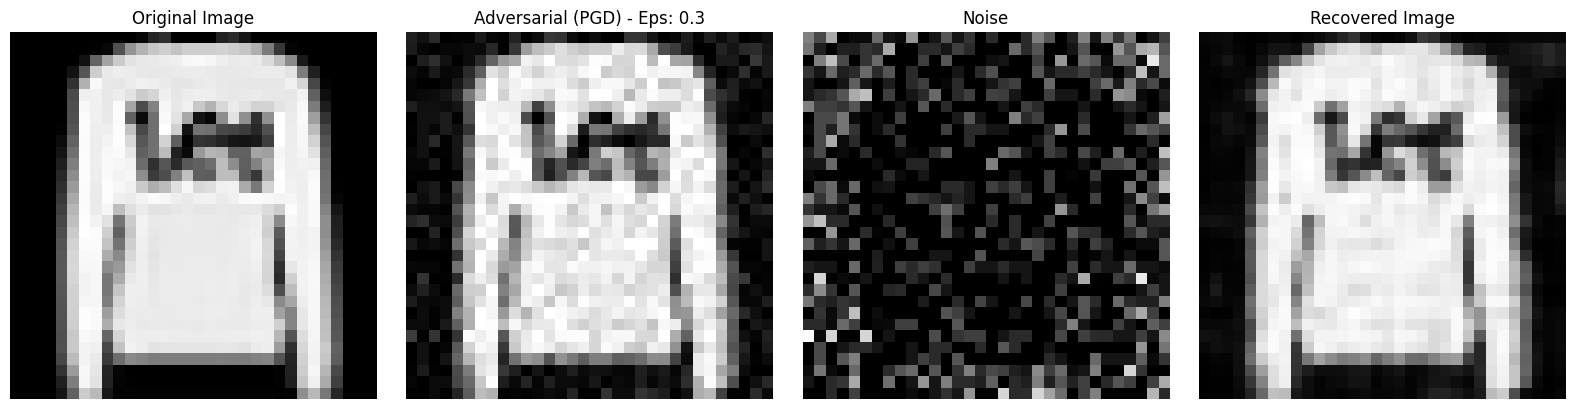

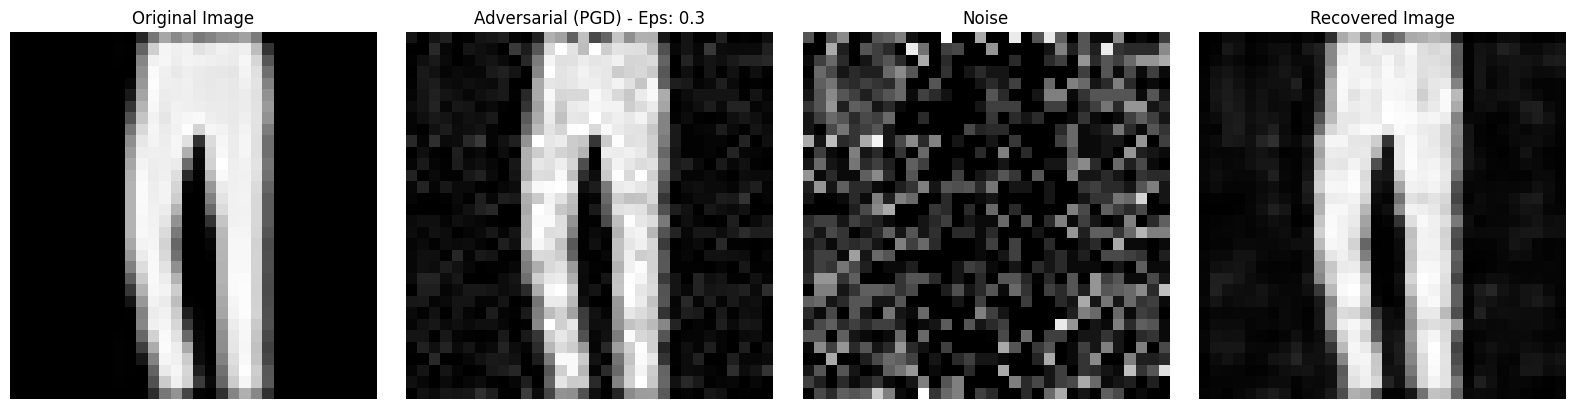

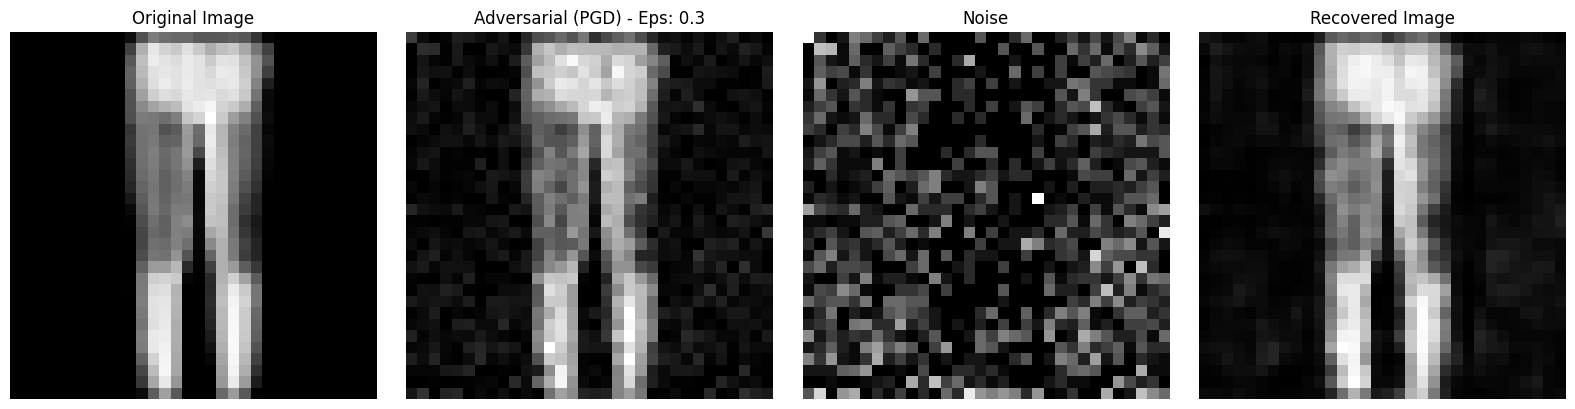

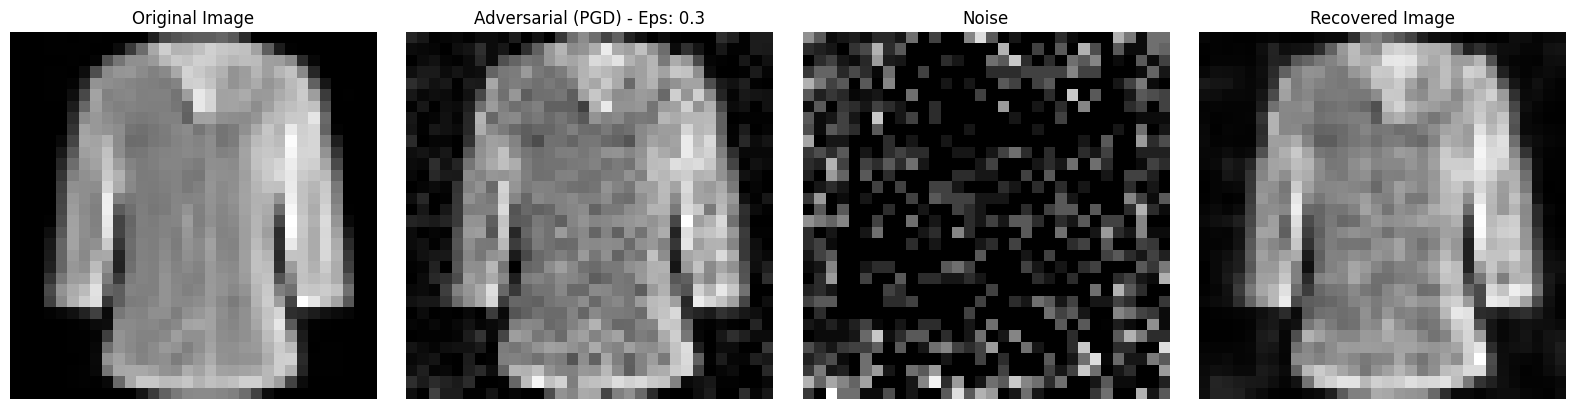

Visualizing for epsilon: 0.4


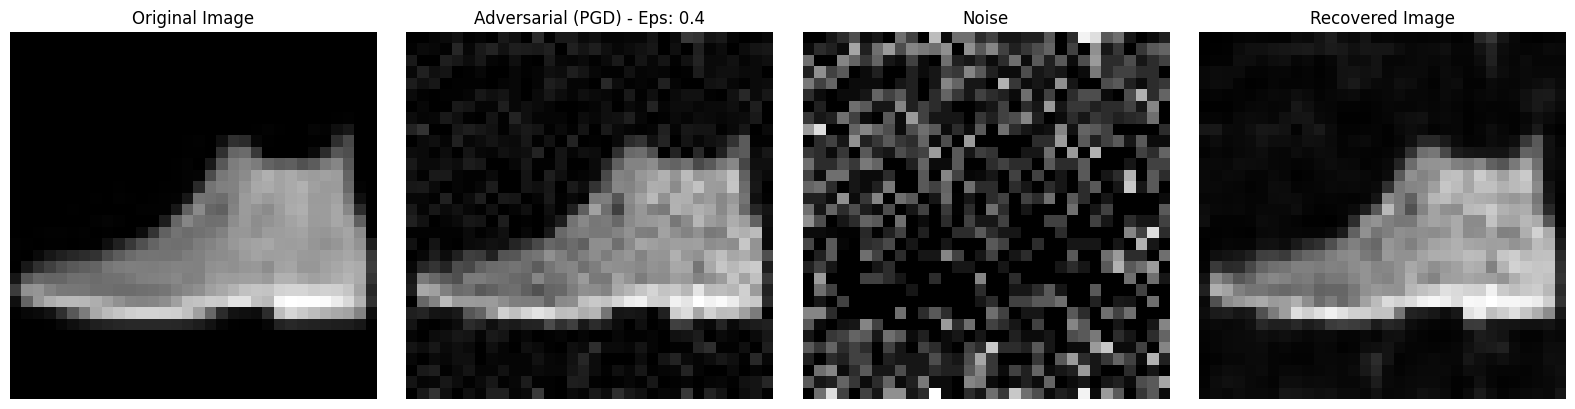

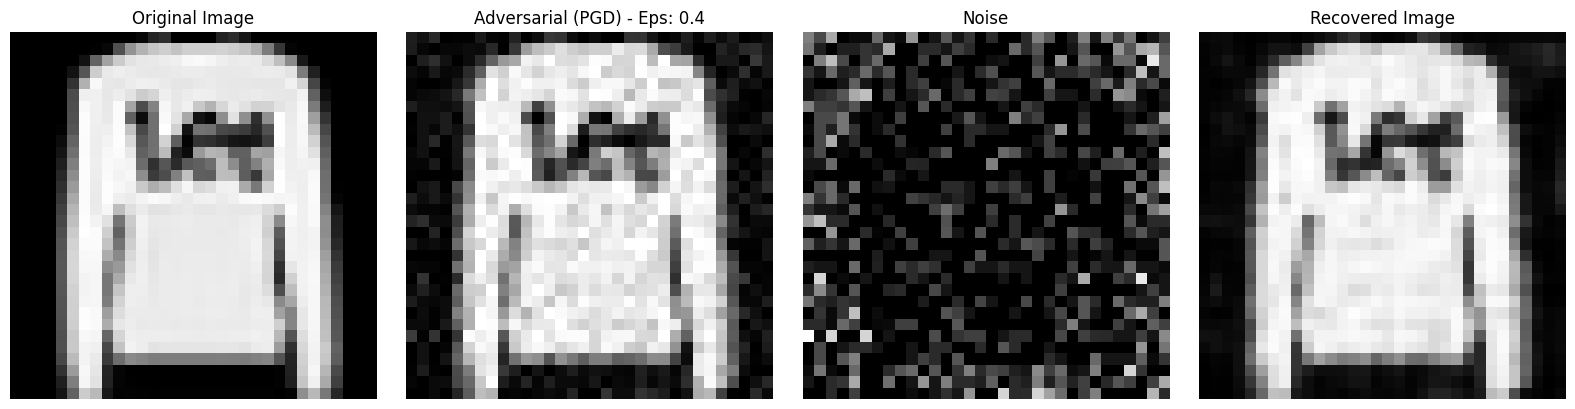

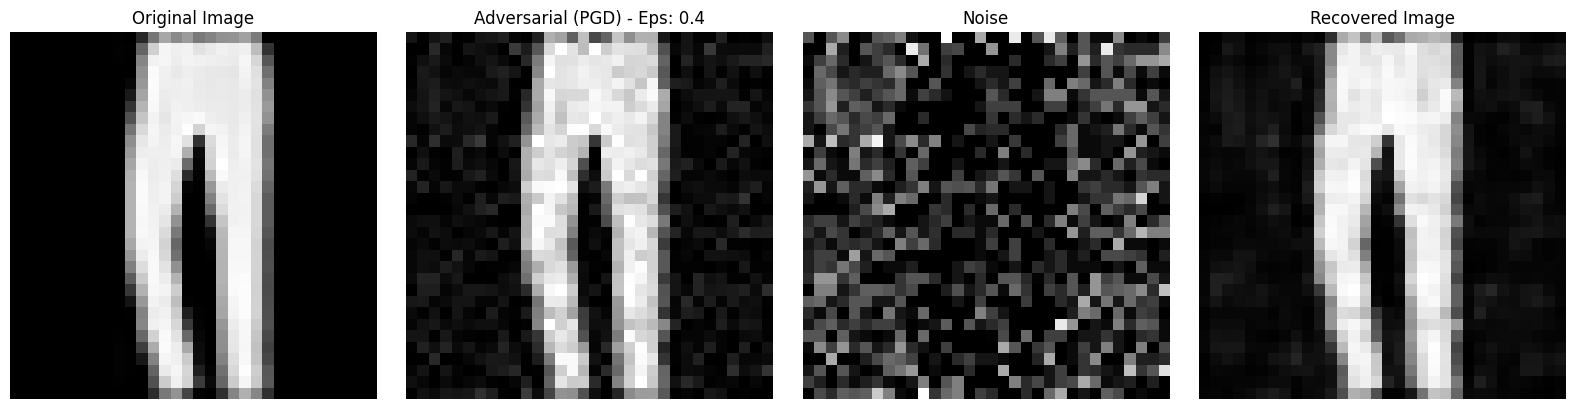

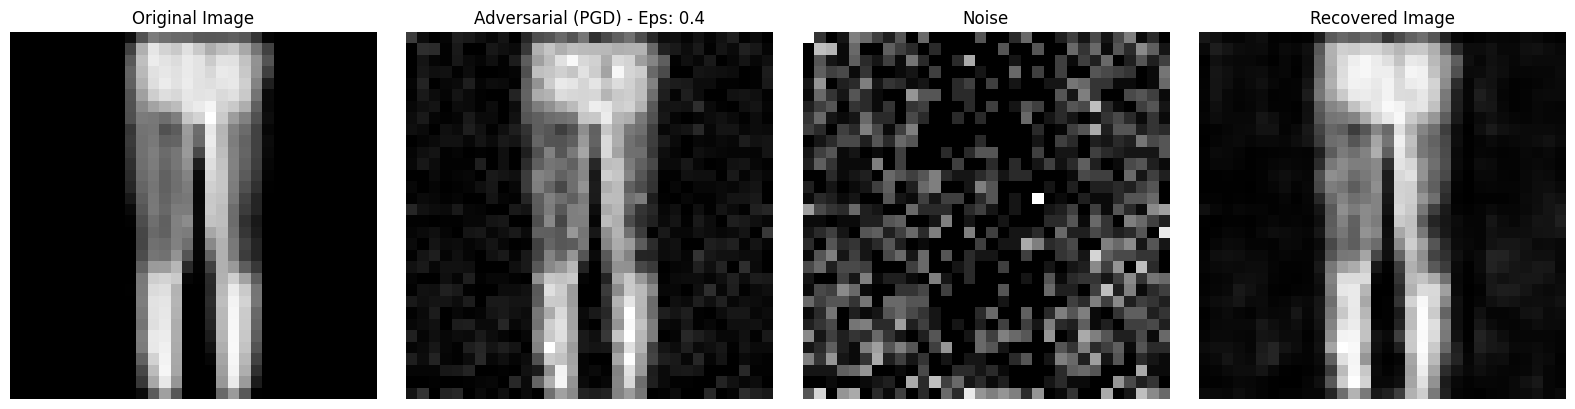

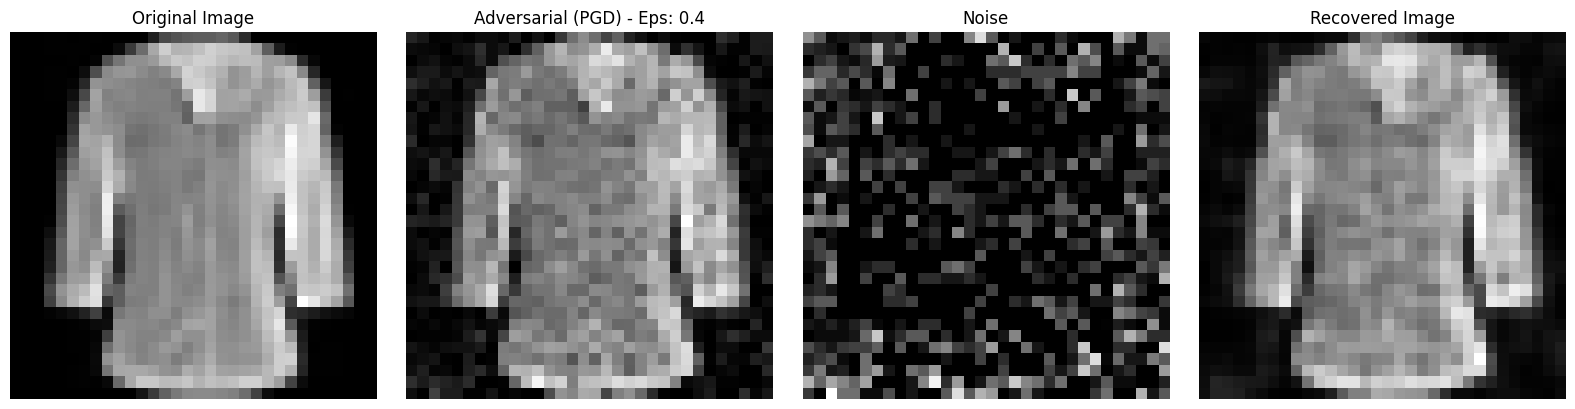

In [ ]:
# Danh sách các giá trị epsilon
epsilons = [0.1, 0.2, 0.3, 0.4]

# Hiển thị hình ảnh gốc
visualize_images_with_epsilons(model, convAE, test_loader, attack_type=None, eps_list=epsilons, num_samples=5)

# Hiển thị hình ảnh sau tấn công FGSM
visualize_images_with_epsilons(model, convAE, test_loader, attack_type='fgsm', eps_list=epsilons, num_samples=5)

# Hiển thị hình ảnh sau tấn công PGD
visualize_images_with_epsilons(model, convAE, test_loader, attack_type='pgd', eps_list=epsilons, num_samples=5)

In [ ]:
def adversarial_training(model, train_loader, val_loader, attack_type="fgsm", eps=0.3, alpha=0.01, iters=40, num_epochs=10, learning_rate=0.001):
    """
    Huấn luyện mô hình với dữ liệu đối kháng.
    - attack_type: 'fgsm' hoặc 'pgd'
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        train_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            # Sinh dữ liệu đối kháng
            if attack_type == "fgsm":
                adv_imgs = fgsm_attack(model, imgs, labels, eps)
            elif attack_type == "pgd":
                adv_imgs = pgd_attack(model, imgs, labels, eps, alpha, iters)
            else:
                adv_imgs = imgs

            optimizer.zero_grad()
            outputs = model(adv_imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)

        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        # Validation Phase
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_accuracy = correct / total
        val_accuracies.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

    return model, train_losses, val_accuracies



In [ ]:
# Huấn luyện mô hình Adversarial Training với FGSM
print("Training VGG16 with FGSM Adversarial Training...")
adv_model_fgsm, fgsm_train_losses, fgsm_val_accuracies = adversarial_training(
    model=VGG16((1, 32, 32), batch_norm=True).to(device),
    train_loader=train_loader,
    val_loader=val_loader,
    attack_type="fgsm",
    eps=0.3,
    num_epochs=10
)



Training VGG16 with FGSM Adversarial Training...
Epoch [1/10], Train Loss: 1.0197, Val Accuracy: 0.6728
Epoch [2/10], Train Loss: 0.6000, Val Accuracy: 0.7747
Epoch [3/10], Train Loss: 0.5279, Val Accuracy: 0.7675
Epoch [4/10], Train Loss: 0.3242, Val Accuracy: 0.8041
Epoch [5/10], Train Loss: 0.2014, Val Accuracy: 0.7481
Epoch [6/10], Train Loss: 0.1914, Val Accuracy: 0.7029
Epoch [7/10], Train Loss: 0.1603, Val Accuracy: 0.7767
Epoch [8/10], Train Loss: 0.1457, Val Accuracy: 0.8140
Epoch [9/10], Train Loss: 0.1498, Val Accuracy: 0.7998
Epoch [10/10], Train Loss: 0.1409, Val Accuracy: 0.8133


In [ ]:
# Huấn luyện mô hình Adversarial Training với PGD
print("Training VGG16 with PGD Adversarial Training...")
adv_model_pgd, pgd_train_losses, pgd_val_accuracies = adversarial_training(
    model=VGG16((1, 32, 32), batch_norm=True).to(device),
    train_loader=train_loader,
    val_loader=val_loader,
    attack_type="pgd",
    eps=0.3,
    alpha=0.01,
    iters=40,
    num_epochs=10
)

Training VGG16 with PGD Adversarial Training...
Epoch [1/10], Train Loss: 1.8759, Val Accuracy: 0.4975
Epoch [2/10], Train Loss: 1.6407, Val Accuracy: 0.5905
Epoch [3/10], Train Loss: 1.5459, Val Accuracy: 0.5625
Epoch [4/10], Train Loss: 1.4620, Val Accuracy: 0.6268
Epoch [5/10], Train Loss: 1.3994, Val Accuracy: 0.6810
Epoch [6/10], Train Loss: 1.3534, Val Accuracy: 0.6424
Epoch [7/10], Train Loss: 1.3352, Val Accuracy: 0.6243
Epoch [8/10], Train Loss: 1.3040, Val Accuracy: 0.6672
Epoch [9/10], Train Loss: 1.2858, Val Accuracy: 0.6956
Epoch [10/10], Train Loss: 1.2757, Val Accuracy: 0.6737


Evaluating Normal Model...
FGSM - Epsilon: 0.30, Accuracy: 0.1119, Avg Perturbation: 7.7863
Evaluating FGSM Adversarially Trained Model...
FGSM - Epsilon: 0.30, Accuracy: 0.5818, Avg Perturbation: 7.7980
Evaluating PGD Adversarially Trained Model...
FGSM - Epsilon: 0.30, Accuracy: 0.5441, Avg Perturbation: 7.6739


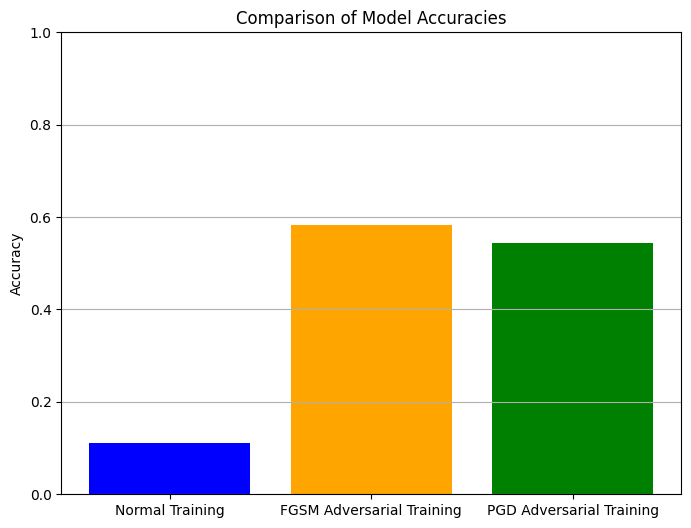

In [ ]:
def plot_adversarial_training_results(normal_acc, fgsm_acc, pgd_acc):
    """
    So sánh độ chính xác giữa mô hình gốc và mô hình huấn luyện đối kháng.
    """
    labels = ['Normal Training', 'FGSM Adversarial Training', 'PGD Adversarial Training']
    accuracies = [normal_acc, fgsm_acc, pgd_acc]

    plt.figure(figsize=(8, 6))
    plt.bar(labels, accuracies, color=['blue', 'orange', 'green'])
    plt.title("Comparison of Model Accuracies")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.grid(axis='y')
    plt.savefig("output_images/adversarial_training_comparison.png")
    plt.show()

# Đánh giá mô hình gốc và mô hình Adversarial Training trên tập test
print("Evaluating Normal Model...")
normal_test_accuracy, _ = evaluate_with_epsilons(model, convAE, test_loader, [0.3], "fgsm")

print("Evaluating FGSM Adversarially Trained Model...")
fgsm_test_accuracy, _ = evaluate_with_epsilons(adv_model_fgsm, convAE, test_loader, [0.3], "fgsm")

print("Evaluating PGD Adversarially Trained Model...")
pgd_test_accuracy, _ = evaluate_with_epsilons(adv_model_pgd, convAE, test_loader, [0.3], "fgsm")

# Vẽ biểu đồ so sánh
plot_adversarial_training_results(normal_test_accuracy[0], fgsm_test_accuracy[0], pgd_test_accuracy[0])


In [ ]:
def visualize_adversarial_training_results(model, convAE, test_loader, attack_type='fgsm', eps=0.3, alpha=0.01, iters=40, num_samples=5, model_name="Original"):
    """
    Hiển thị hình ảnh gốc, tấn công, và phục hồi của mô hình Adversarial Training.
    """
    model.eval()
    convAE.eval()

    count = 0
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        # Tấn công FGSM hoặc PGD nếu được yêu cầu
        if attack_type == 'fgsm':
            adv_imgs = fgsm_attack(model, imgs, labels, eps)
        elif attack_type == 'pgd':
            adv_imgs = pgd_attack(model, imgs, labels, eps, alpha, iters)
        else:
            adv_imgs = imgs

        # Phục hồi bằng Autoencoder
        rec_imgs = convAE(adv_imgs)

        # Chọn một số hình ảnh để hiển thị
        for i in range(min(num_samples, imgs.size(0))):
            original_img = imgs[i].cpu().detach().numpy().transpose(1, 2, 0)
            adversarial_img = adv_imgs[i].cpu().detach().numpy().transpose(1, 2, 0)
            recovered_img = rec_imgs[i].cpu().detach().numpy().transpose(1, 2, 0)

            # Hiển thị hình ảnh
            fig, axs = plt.subplots(1, 3, figsize=(12, 4))
            axs[0].imshow(original_img.squeeze(), cmap='gray')
            axs[0].set_title(f"Original Image\nLabel: {labels[i].item()}")
            axs[0].axis("off")

            axs[1].imshow(adversarial_img.squeeze(), cmap='gray')
            axs[1].set_title(f"Adversarial Image ({attack_type.upper()})\nEpsilon: {eps}")
            axs[1].axis("off")

            axs[2].imshow(recovered_img.squeeze(), cmap='gray')
            axs[2].set_title(f"Recovered Image\nModel: {model_name}")
            axs[2].axis("off")

            plt.tight_layout()
            plt.savefig(f"output_images/{model_name}_visualize_{attack_type}_sample_{count}.png")
            plt.show()

            count += 1
            if count >= num_samples:
                break
        if count >= num_samples:
            break


Visualizing Results for Original Model...


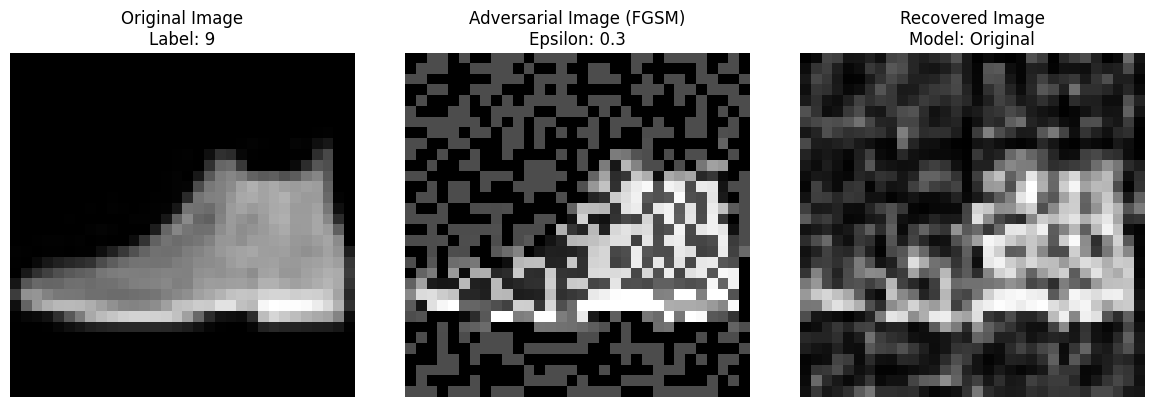

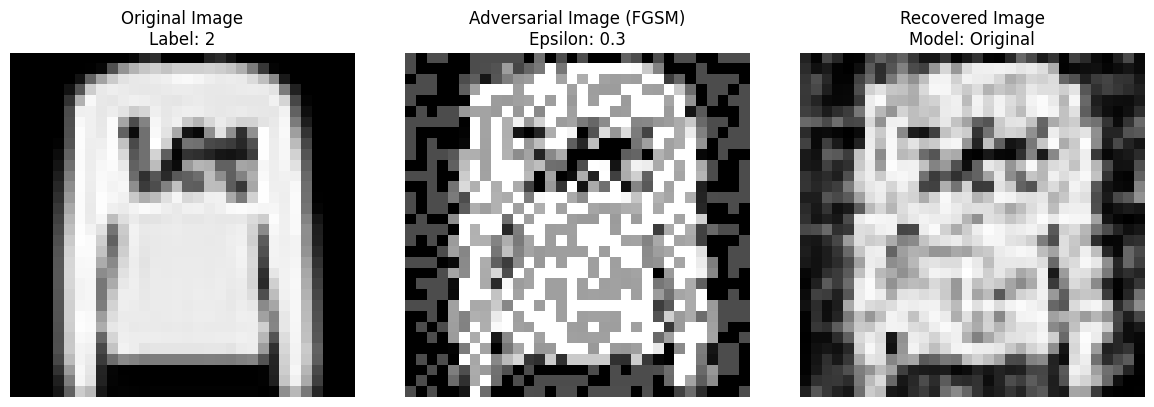

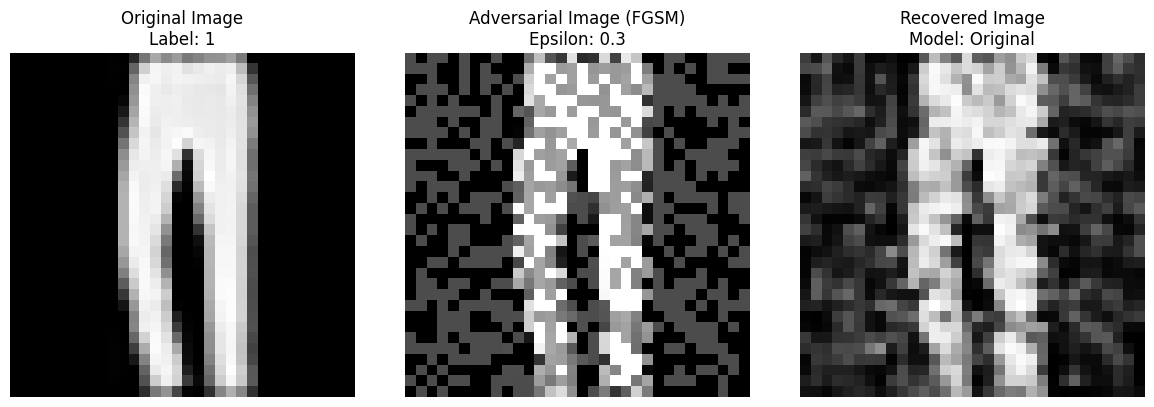

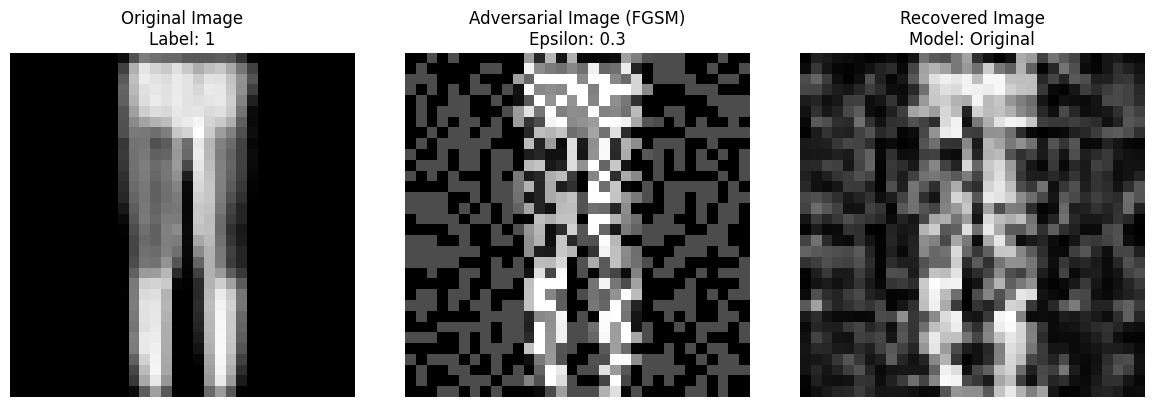

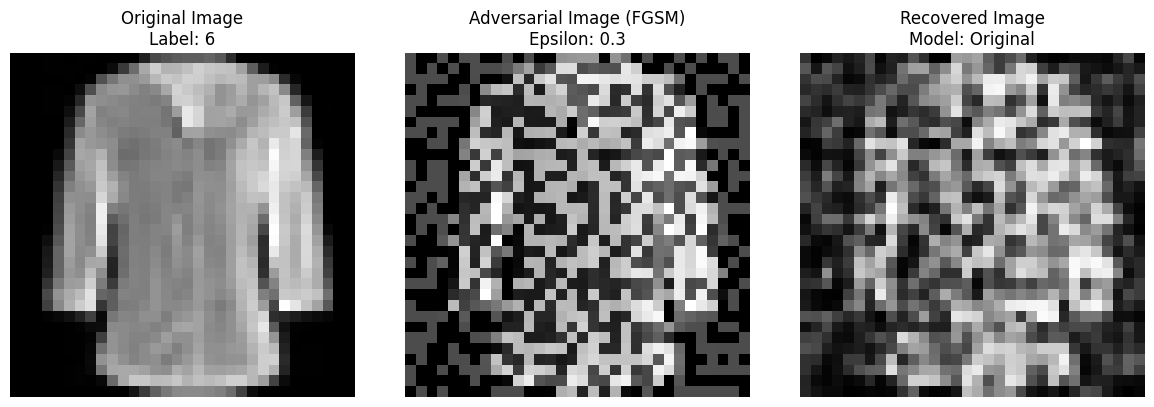

Visualizing Results for FGSM Adversarially Trained Model...


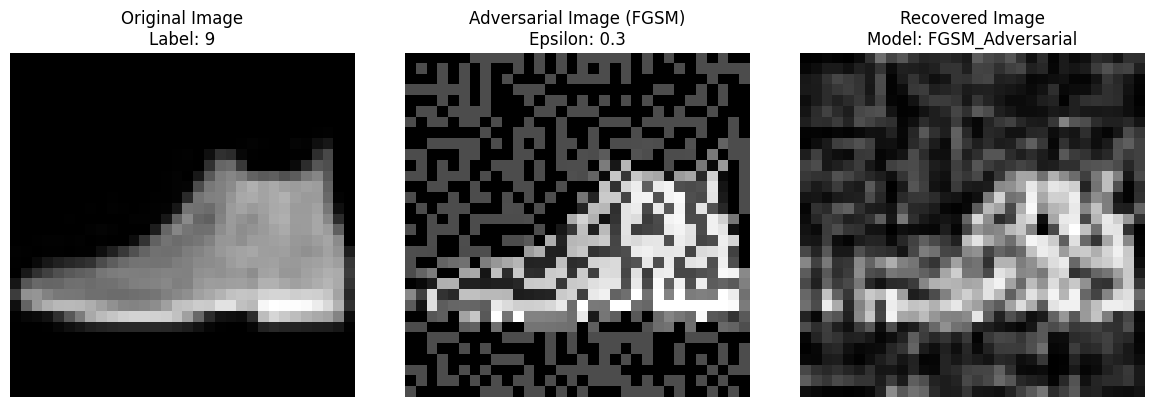

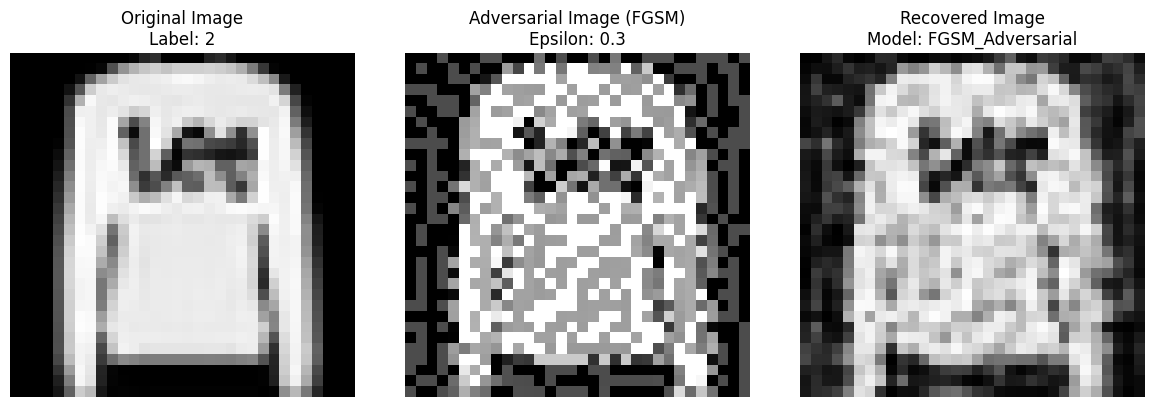

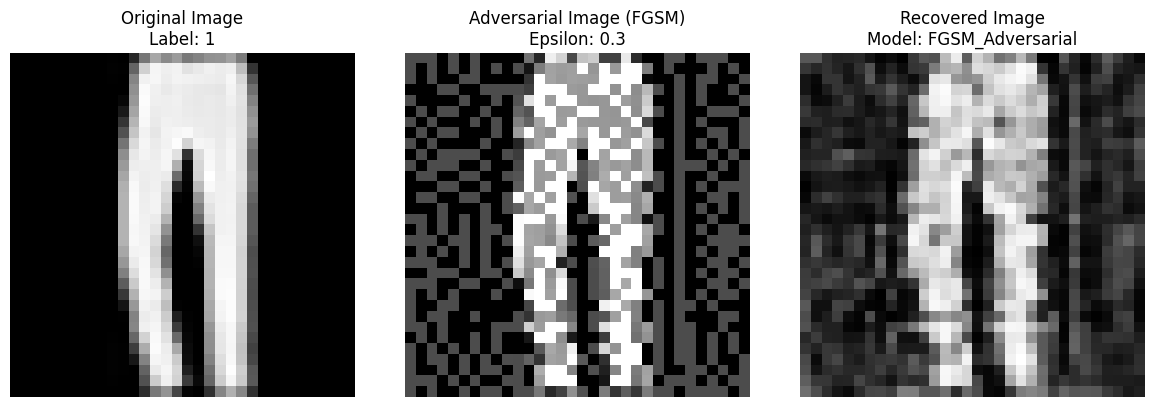

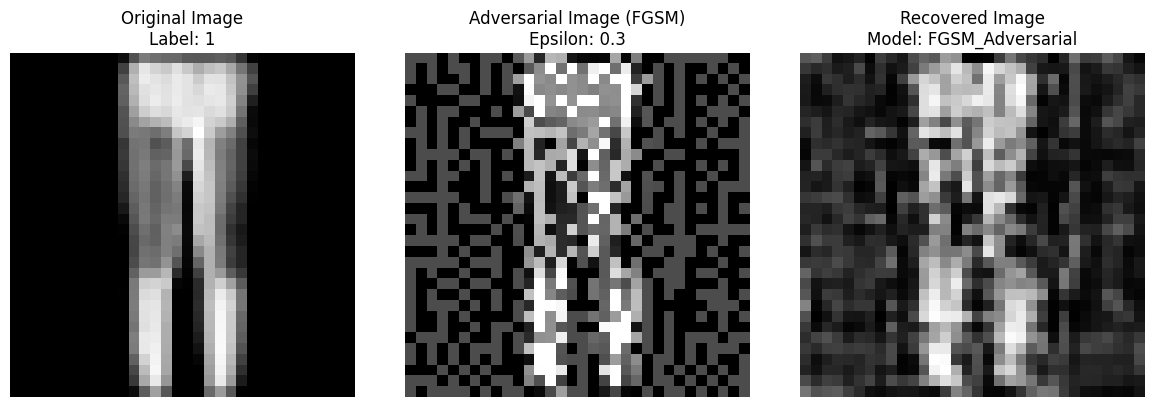

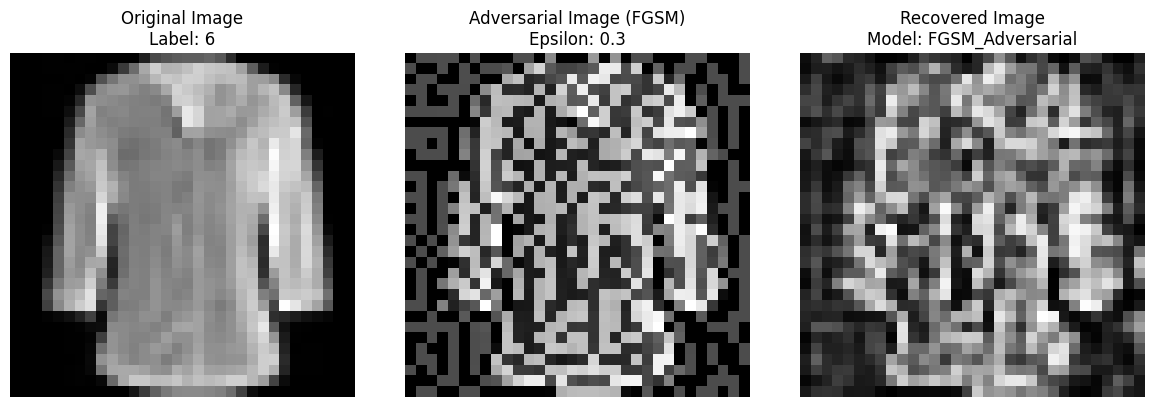

Visualizing Results for PGD Adversarially Trained Model...


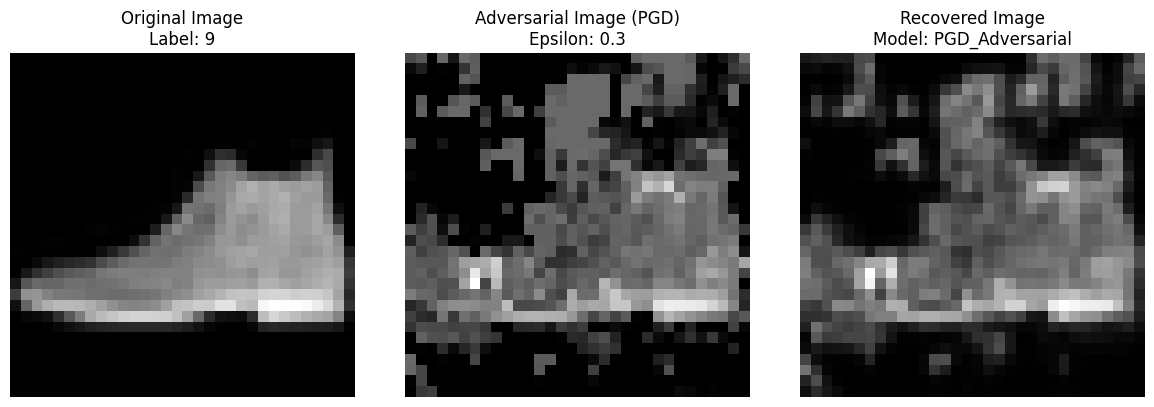

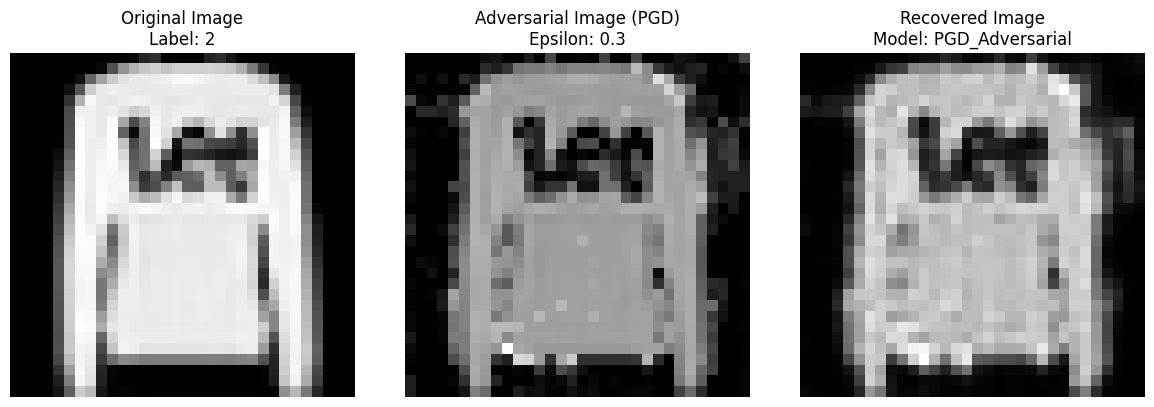

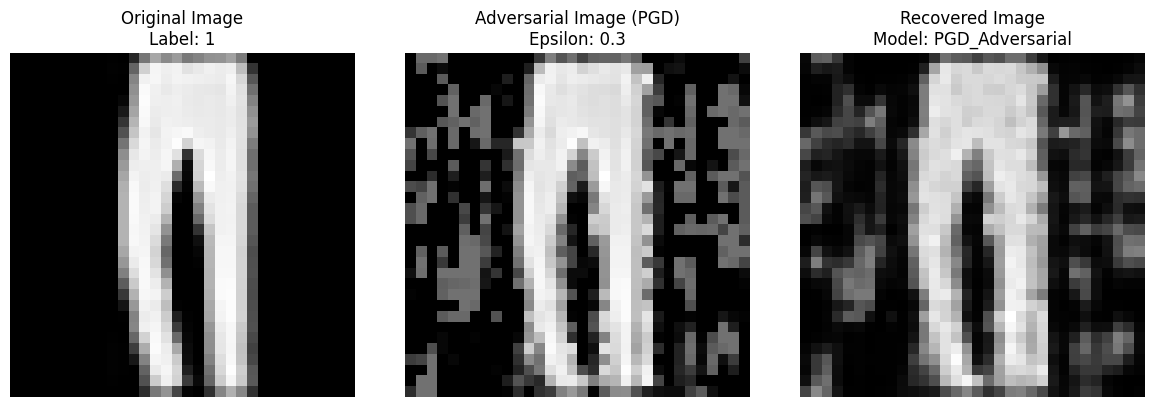

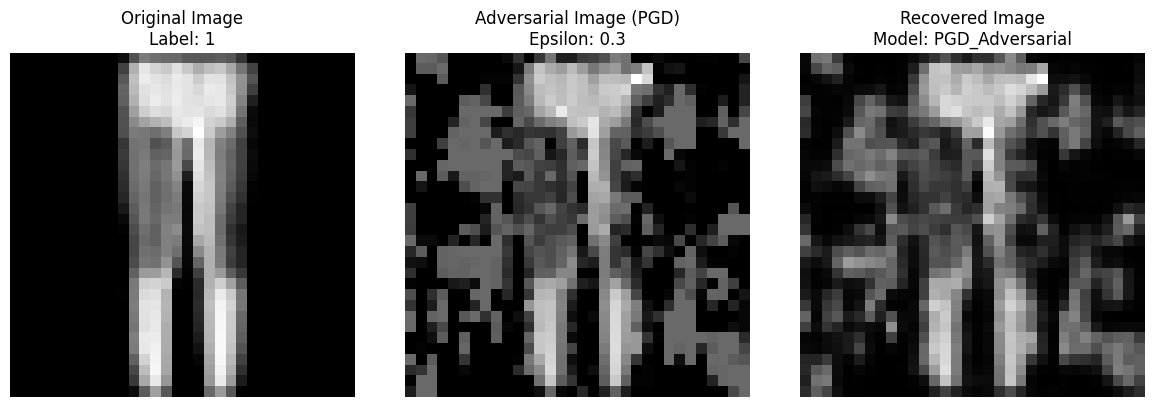

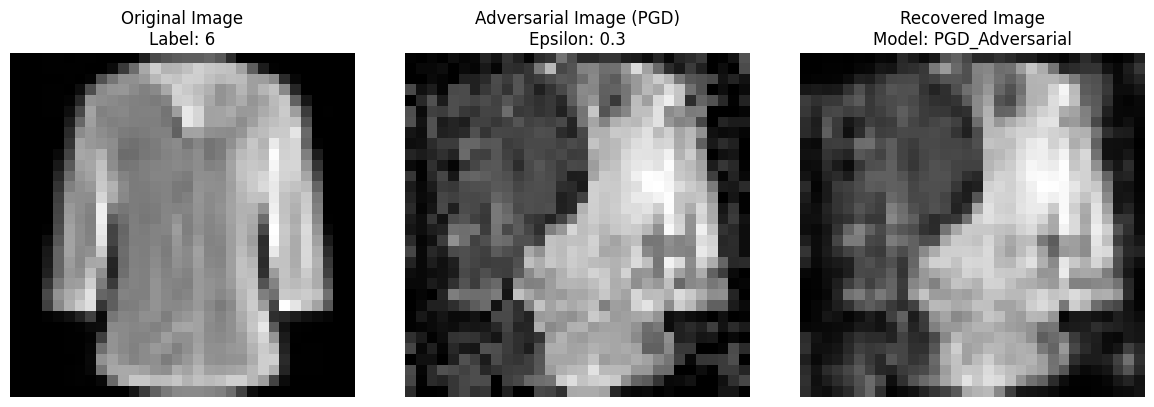

In [ ]:
# Hiển thị hình ảnh từ mô hình gốc
print("Visualizing Results for Original Model...")
visualize_adversarial_training_results(model, convAE, test_loader, attack_type='fgsm', eps=0.3, model_name="Original")

# Hiển thị hình ảnh từ mô hình FGSM Adversarial Training
print("Visualizing Results for FGSM Adversarially Trained Model...")
visualize_adversarial_training_results(adv_model_fgsm, convAE, test_loader, attack_type='fgsm', eps=0.3, model_name="FGSM_Adversarial")

# Hiển thị hình ảnh từ mô hình PGD Adversarial Training
print("Visualizing Results for PGD Adversarially Trained Model...")
visualize_adversarial_training_results(adv_model_pgd, convAE, test_loader, attack_type='pgd', eps=0.3, alpha=0.01, iters=40, model_name="PGD_Adversarial")

In [ ]:
def visualize_adversarial_training(model_std, model_adv, convAE, test_loader, attack_type='fgsm', eps_list=None, alpha=0.01, iters=40, num_samples=5):
    """
    Hiển thị kết quả so sánh giữa mô hình thông thường và Adversarial Training.
    - model_std: Mô hình huấn luyện thông thường
    - model_adv: Mô hình huấn luyện với Adversarial Training
    - convAE: Autoencoder dùng để phục hồi
    - attack_type: 'fgsm' hoặc 'pgd'
    - eps_list: Danh sách các giá trị epsilon
    - num_samples: Số lượng hình ảnh hiển thị
    """
    model_std.eval()
    model_adv.eval()
    convAE.eval()

    if eps_list is None:
        eps_list = [0.1, 0.2, 0.3, 0.4]  # Danh sách epsilon mặc định

    for eps in eps_list:
        print(f"\nVisualizing for Epsilon: {eps}, Attack Type: {attack_type.upper()}\n")

        count = 0
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            # Sinh dữ liệu tấn công
            if attack_type == 'fgsm':
                adv_imgs = fgsm_attack(model_std, imgs, labels, eps)
            elif attack_type == 'pgd':
                adv_imgs = pgd_attack(model_std, imgs, labels, eps, alpha, iters)
            else:
                adv_imgs = imgs

            # Phục hồi hình ảnh bằng Autoencoder
            rec_imgs = convAE(adv_imgs)

            # Dự đoán kết quả từ hai mô hình
            outputs_std = model_std(rec_imgs)
            preds_std = outputs_std.argmax(dim=1)

            outputs_adv = model_adv(rec_imgs)
            preds_adv = outputs_adv.argmax(dim=1)

            # Hiển thị các hình ảnh
            for i in range(min(num_samples, imgs.size(0))):
                original_img = imgs[i].cpu().detach().numpy().transpose(1, 2, 0)
                adversarial_img = adv_imgs[i].cpu().detach().numpy().transpose(1, 2, 0)
                recovered_img = rec_imgs[i].cpu().detach().numpy().transpose(1, 2, 0)

                # Chuyển đổi giá trị về [0, 1]
                original_img = np.clip(original_img, 0, 1)
                adversarial_img = np.clip(adversarial_img, 0, 1)
                recovered_img = np.clip(recovered_img, 0, 1)

                # Vẽ hình ảnh
                fig, axs = plt.subplots(1, 5, figsize=(20, 4))
                axs[0].imshow(original_img.squeeze(), cmap='gray')
                axs[0].set_title("Original Image")
                axs[0].axis("off")

                axs[1].imshow(adversarial_img.squeeze(), cmap='gray')
                axs[1].set_title(f"Adversarial (Eps: {eps})")
                axs[1].axis("off")

                axs[2].imshow(recovered_img.squeeze(), cmap='gray')
                axs[2].set_title("Recovered Image")
                axs[2].axis("off")

                axs[3].set_title(f"Prediction (Std): {preds_std[i].item()}")
                axs[3].imshow(recovered_img.squeeze(), cmap='gray')
                axs[3].axis("off")

                axs[4].set_title(f"Prediction (Adv): {preds_adv[i].item()}")
                axs[4].imshow(recovered_img.squeeze(), cmap='gray')
                axs[4].axis("off")

                plt.tight_layout()
                plt.show()

                count += 1
                if count >= num_samples:
                    break
            if count >= num_samples:
                break



Visualizing for Epsilon: 0.1, Attack Type: FGSM



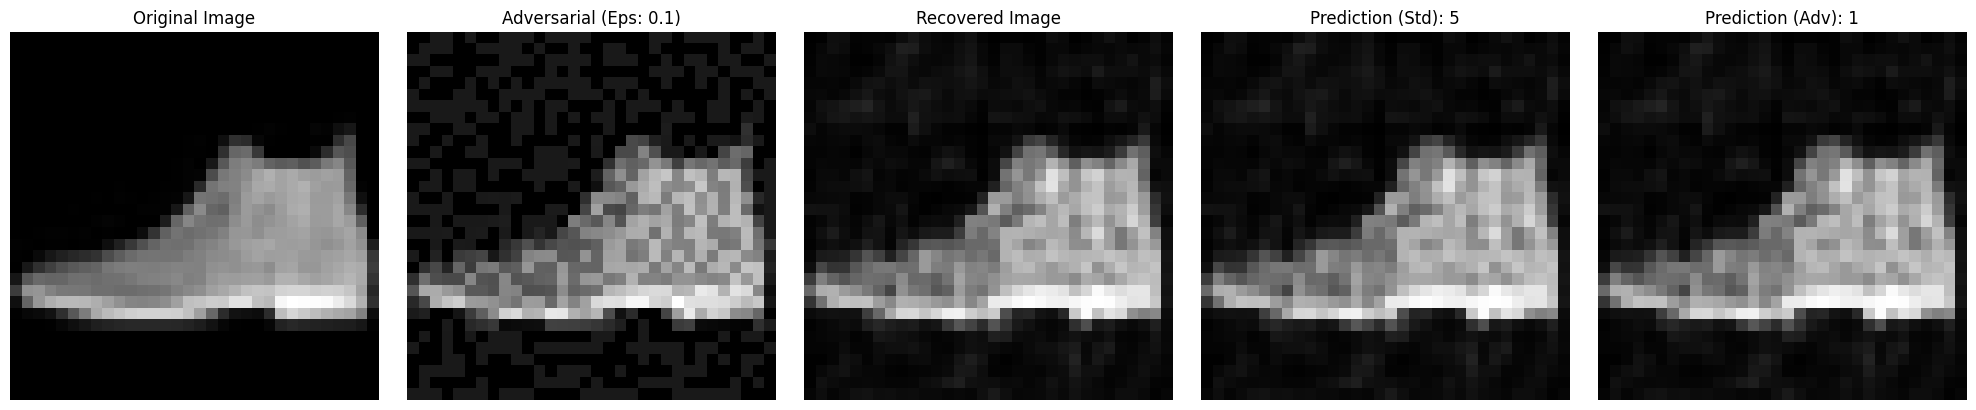

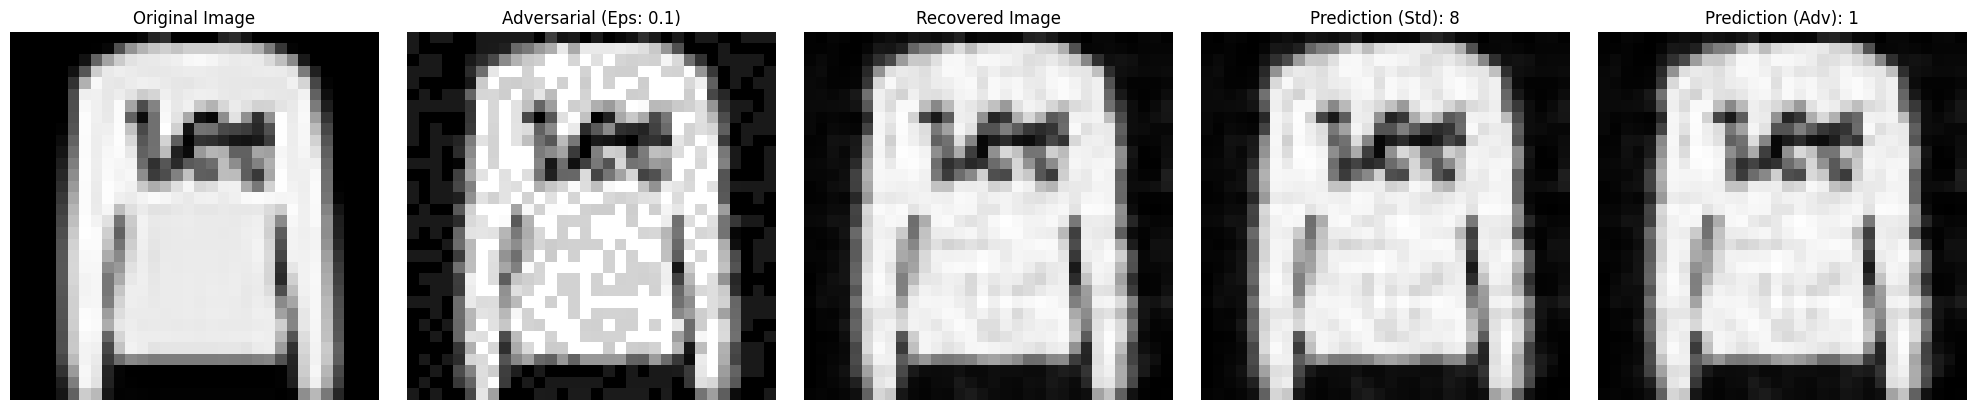

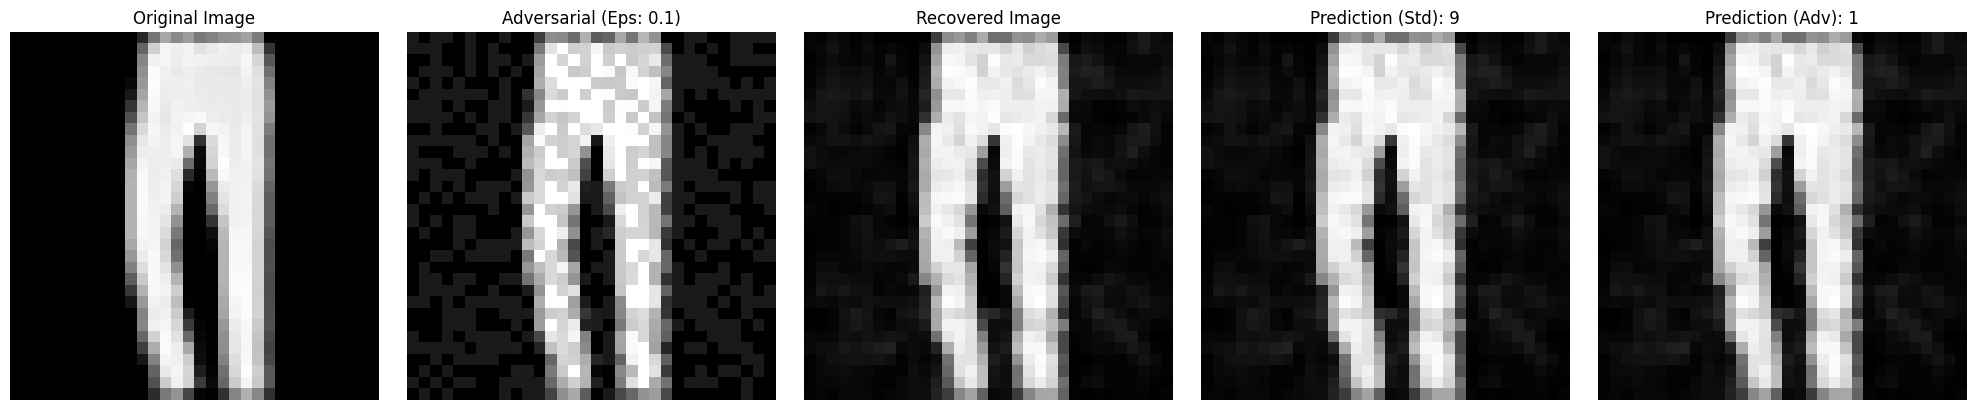

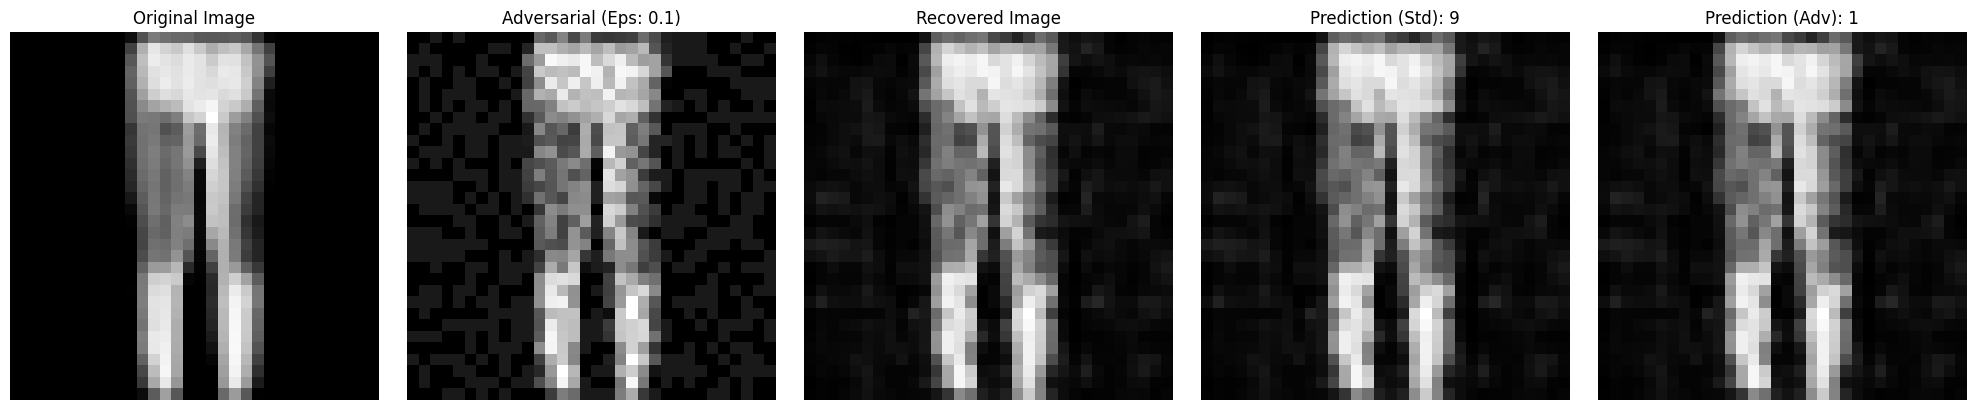

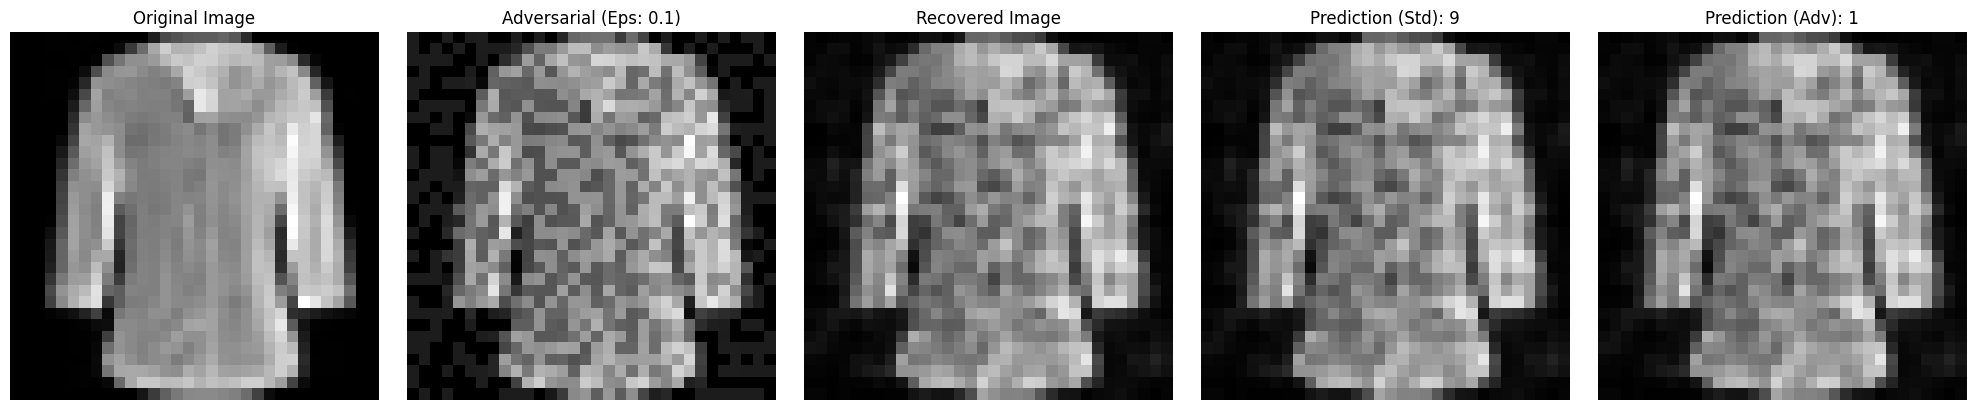


Visualizing for Epsilon: 0.2, Attack Type: FGSM



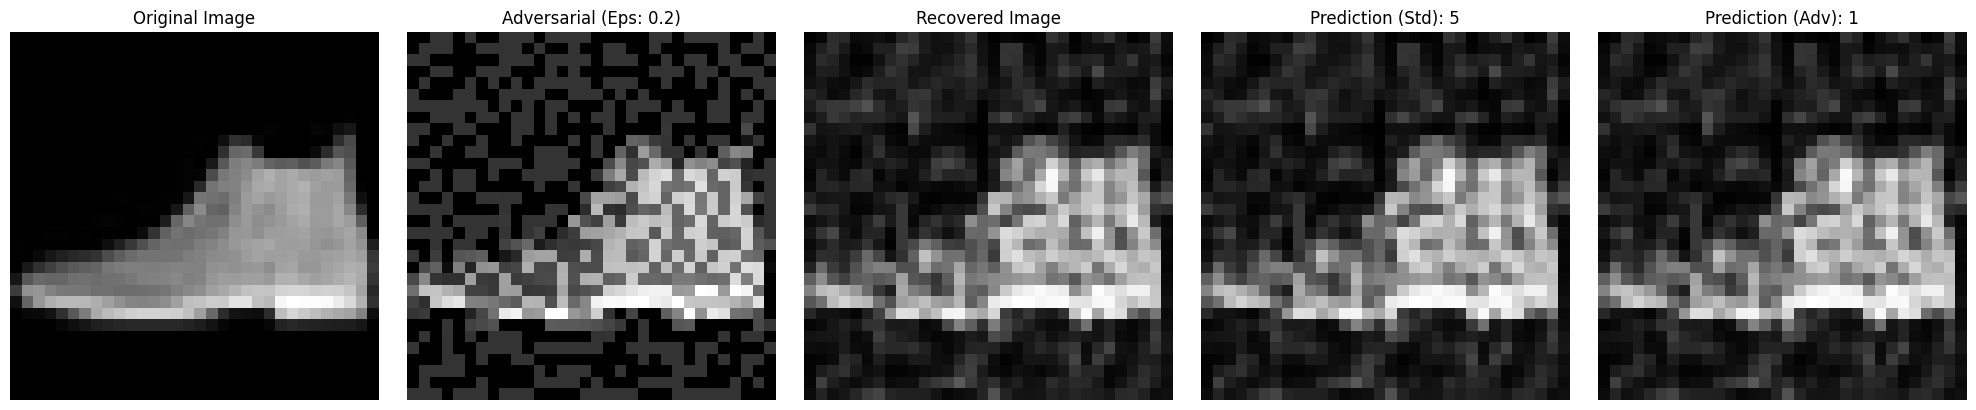

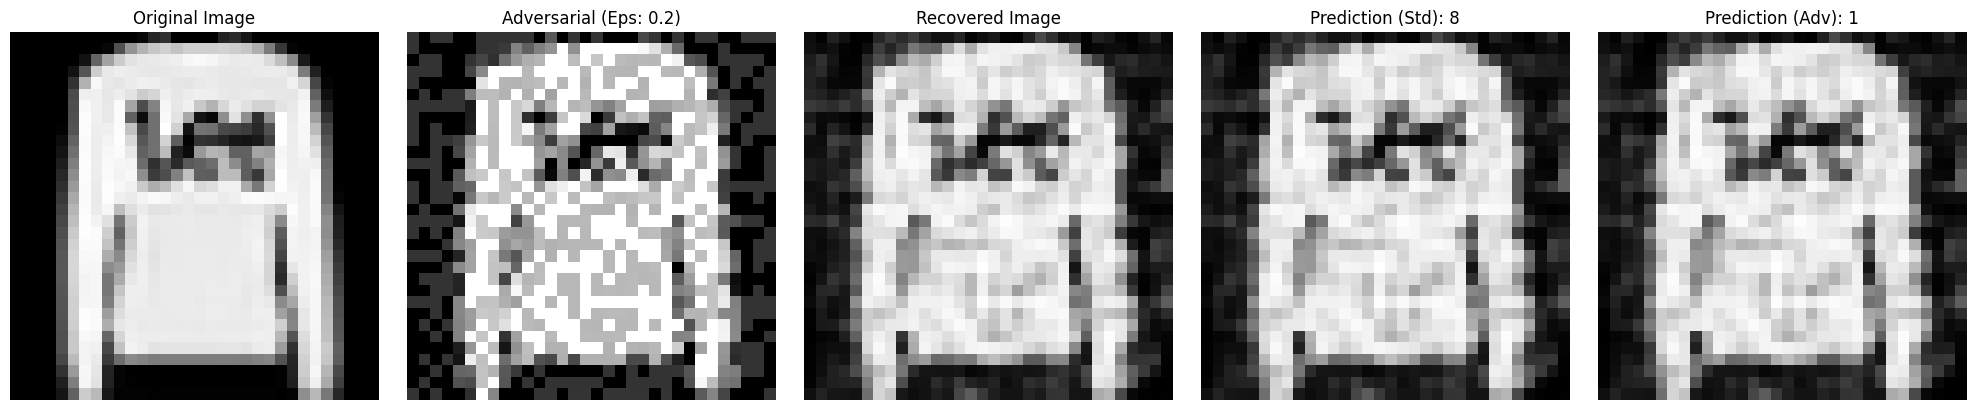

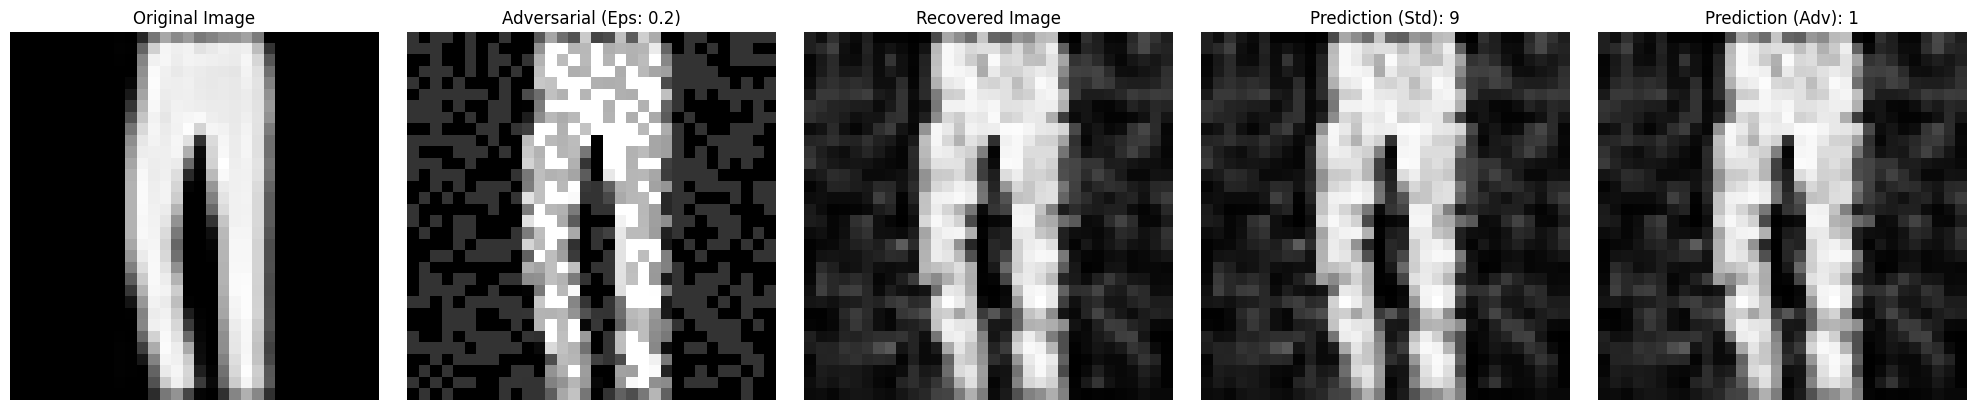

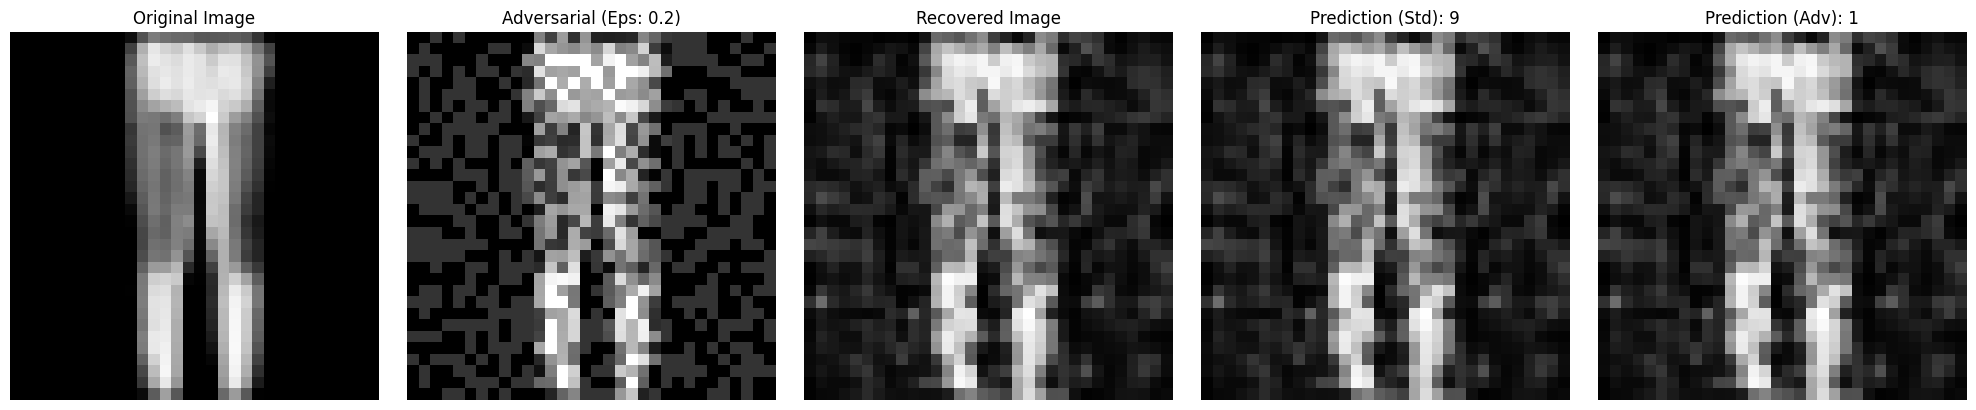

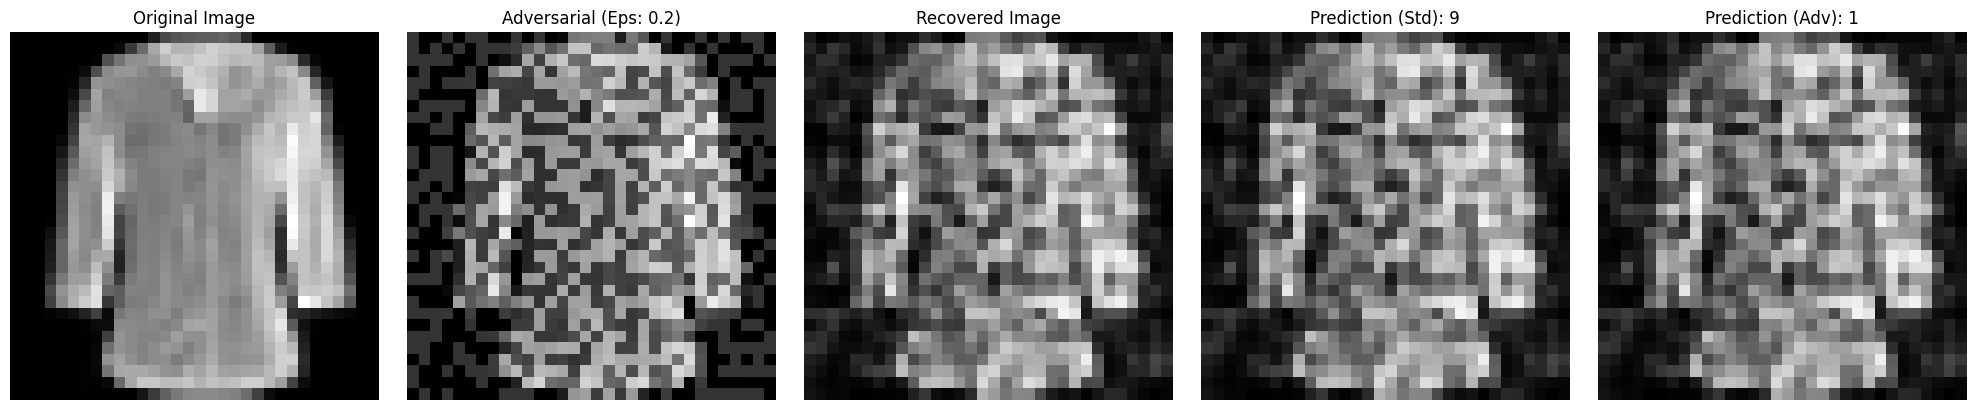


Visualizing for Epsilon: 0.3, Attack Type: FGSM



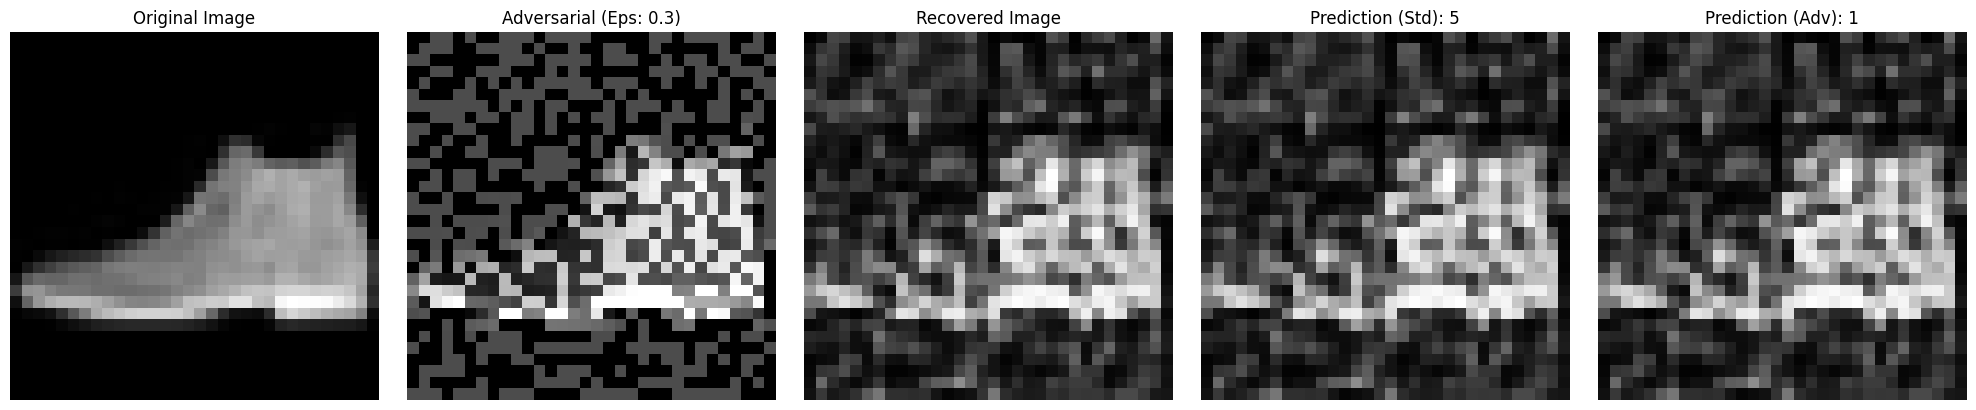

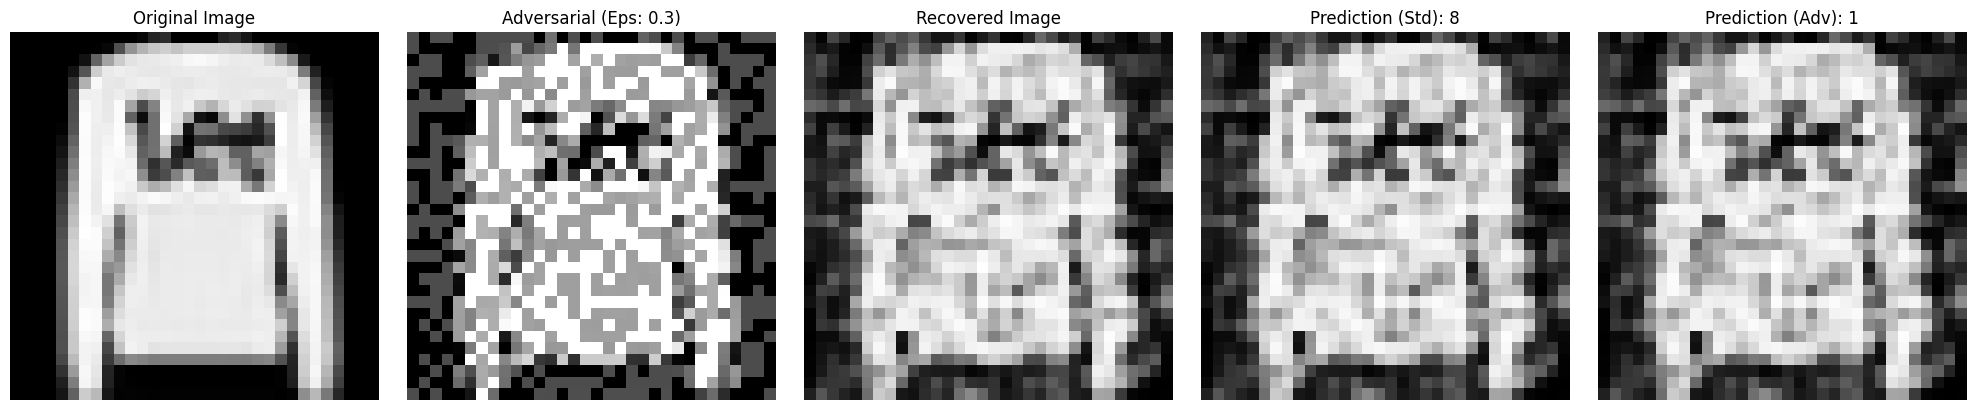

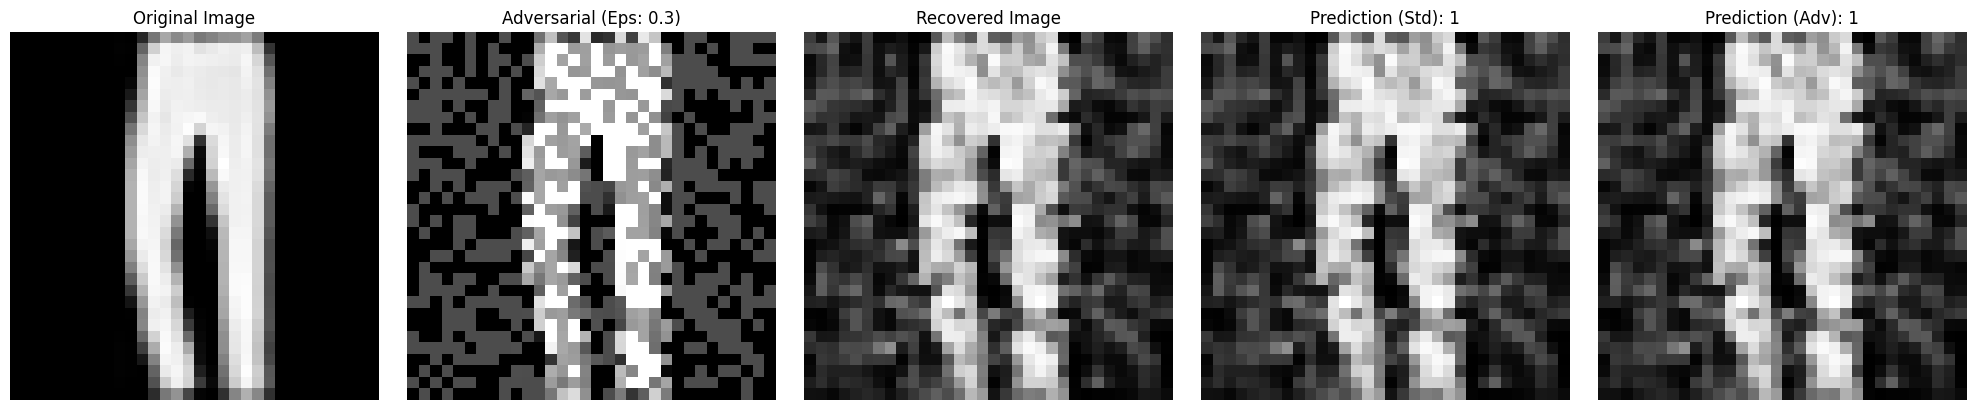

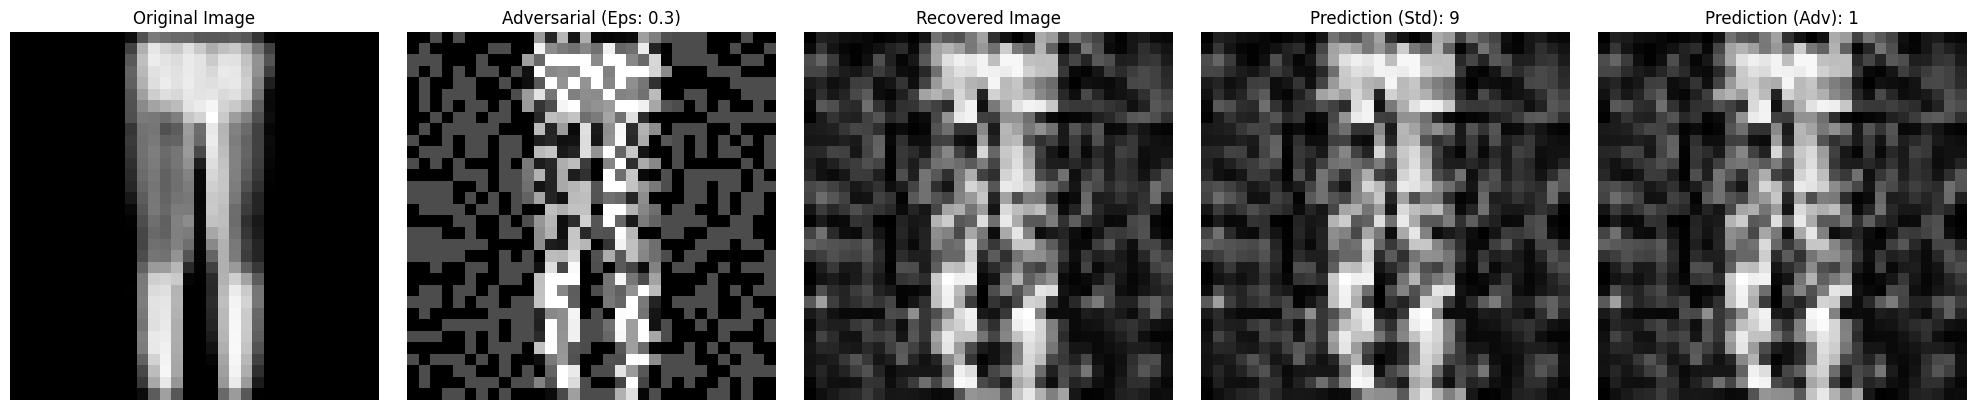

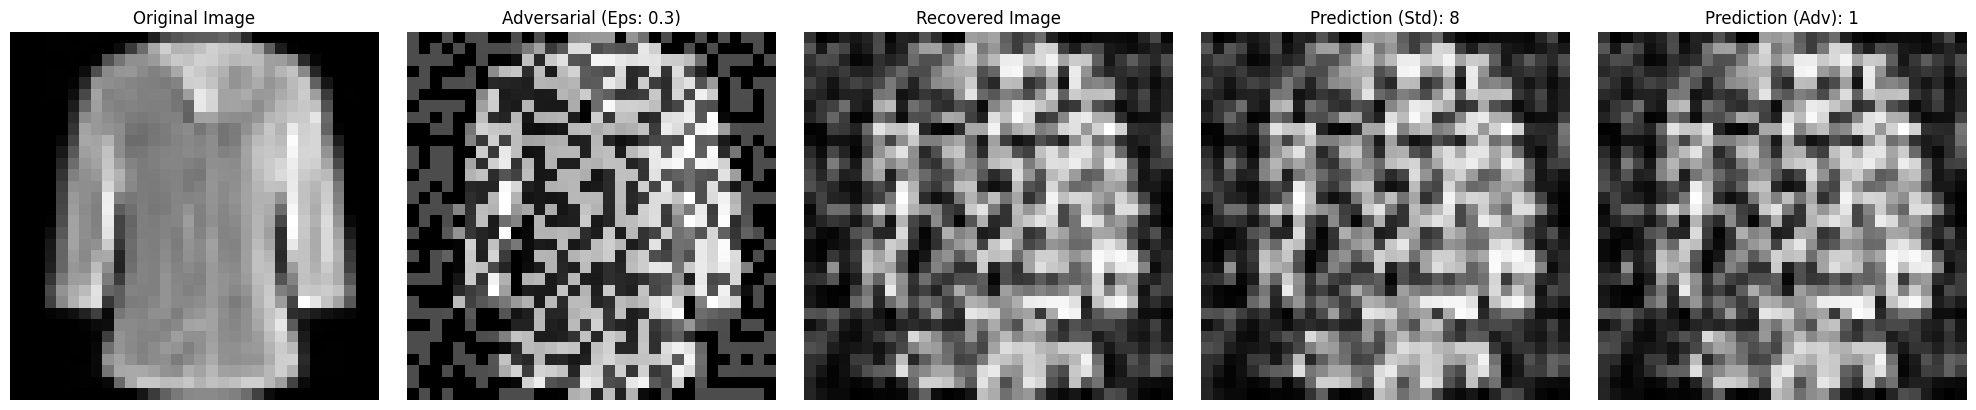


Visualizing for Epsilon: 0.4, Attack Type: FGSM



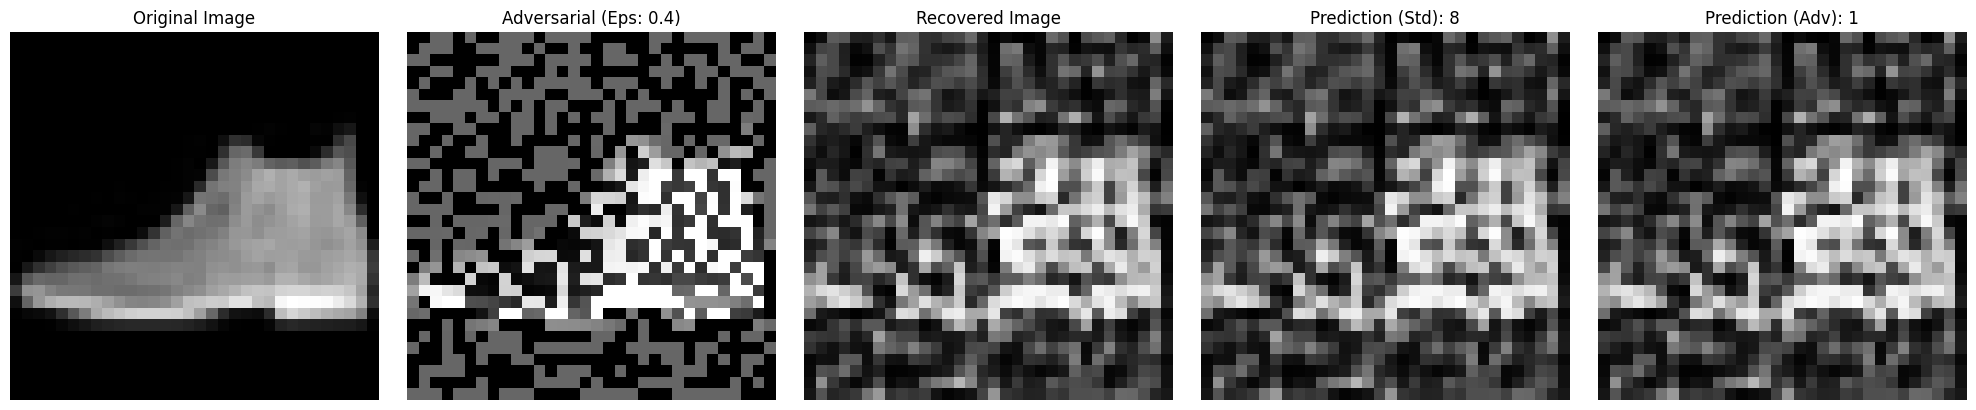

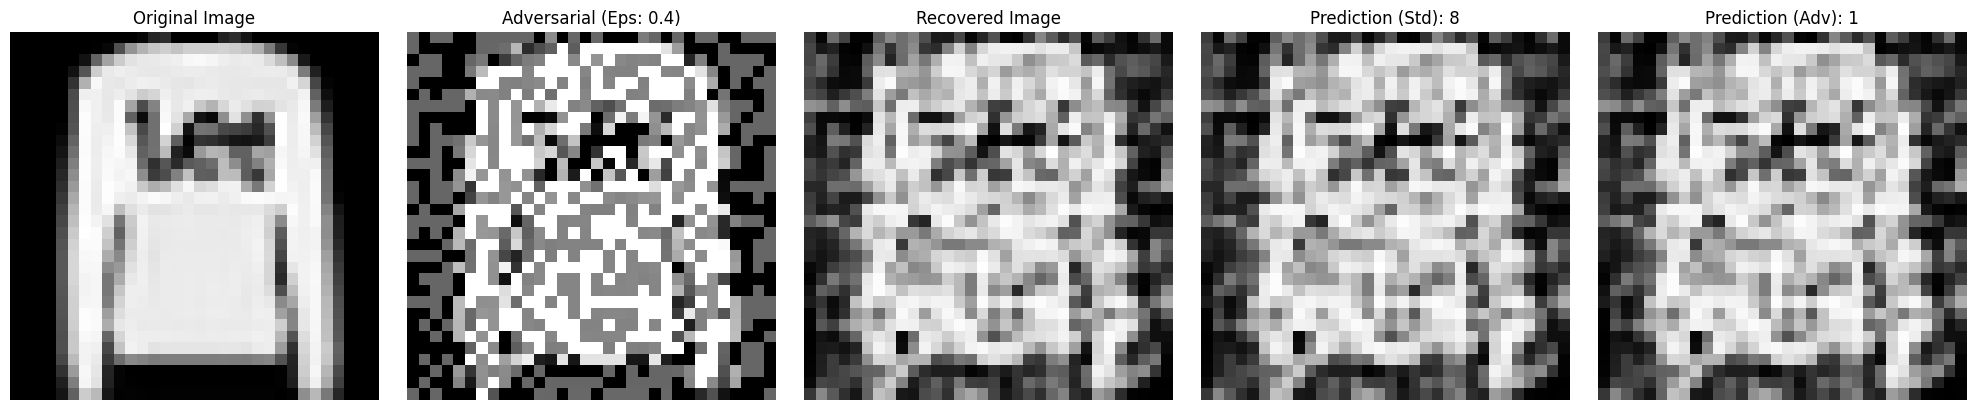

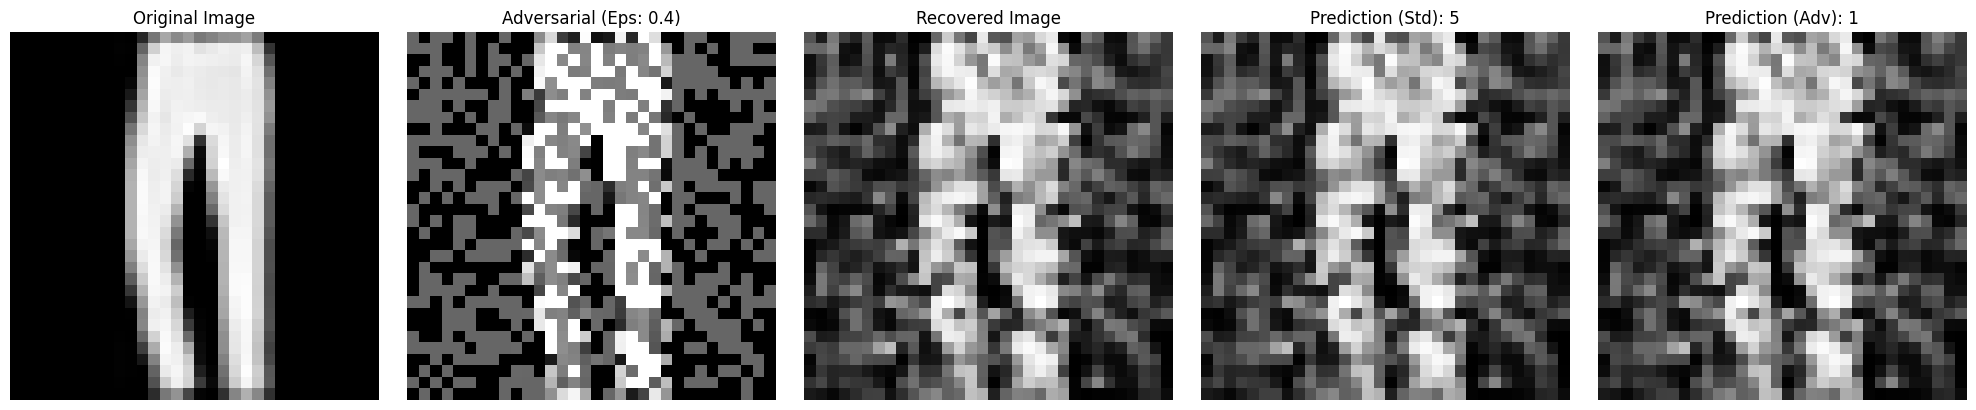

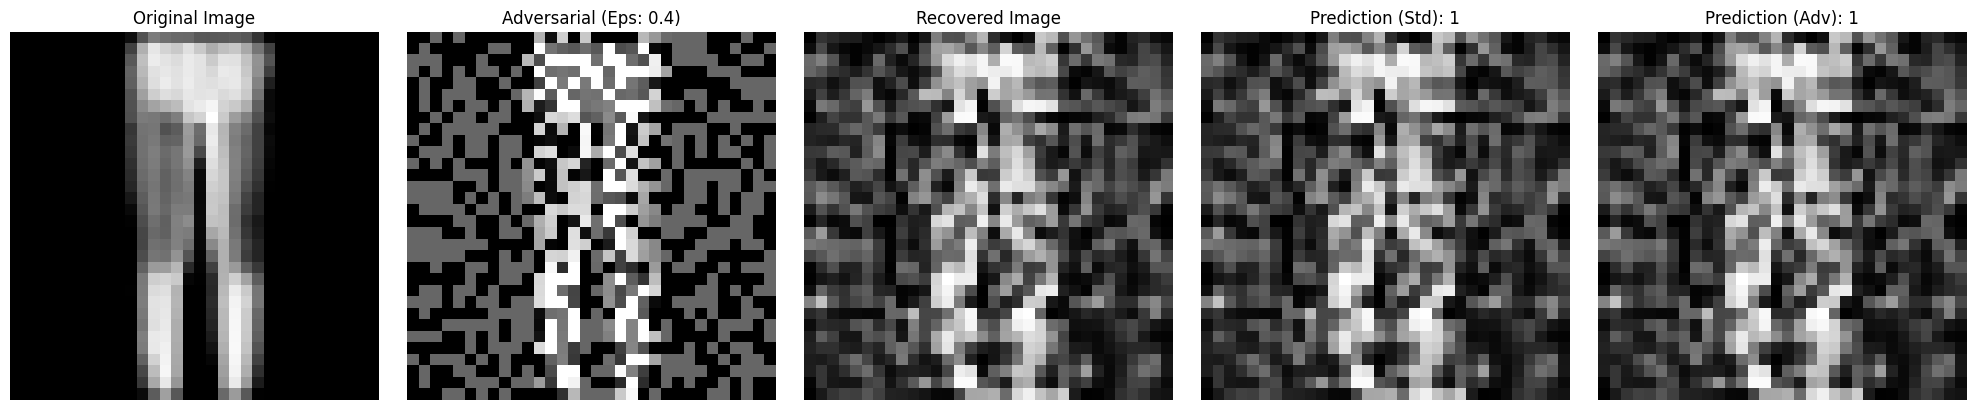

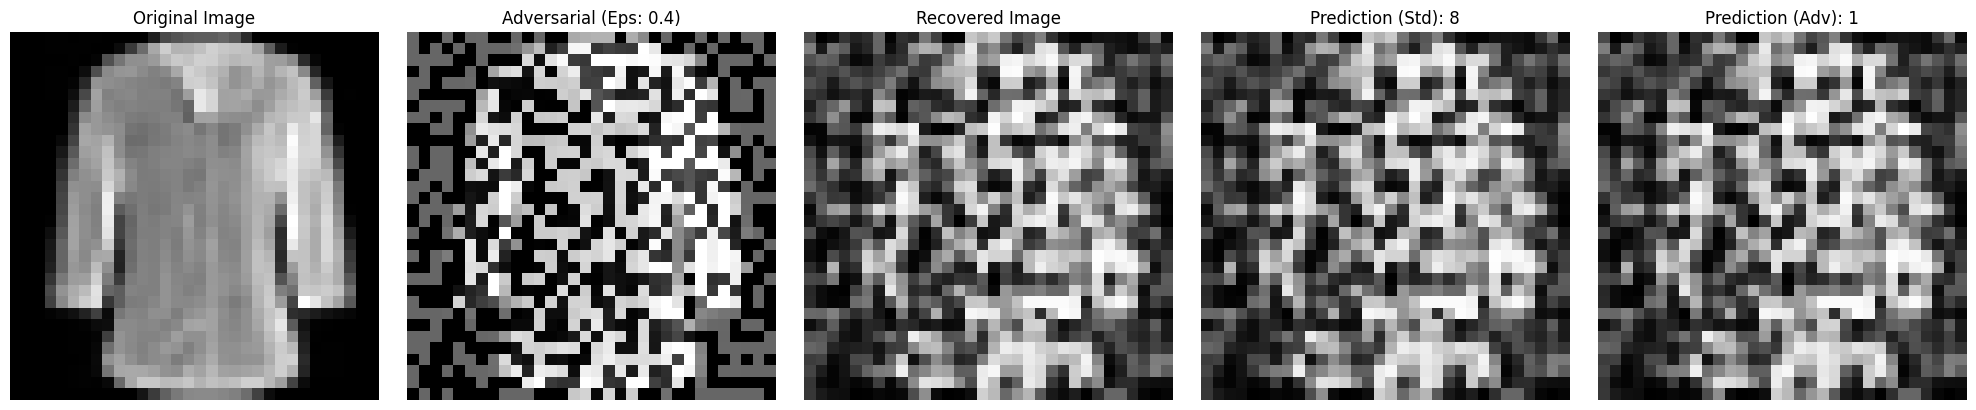


Visualizing for Epsilon: 0.1, Attack Type: PGD



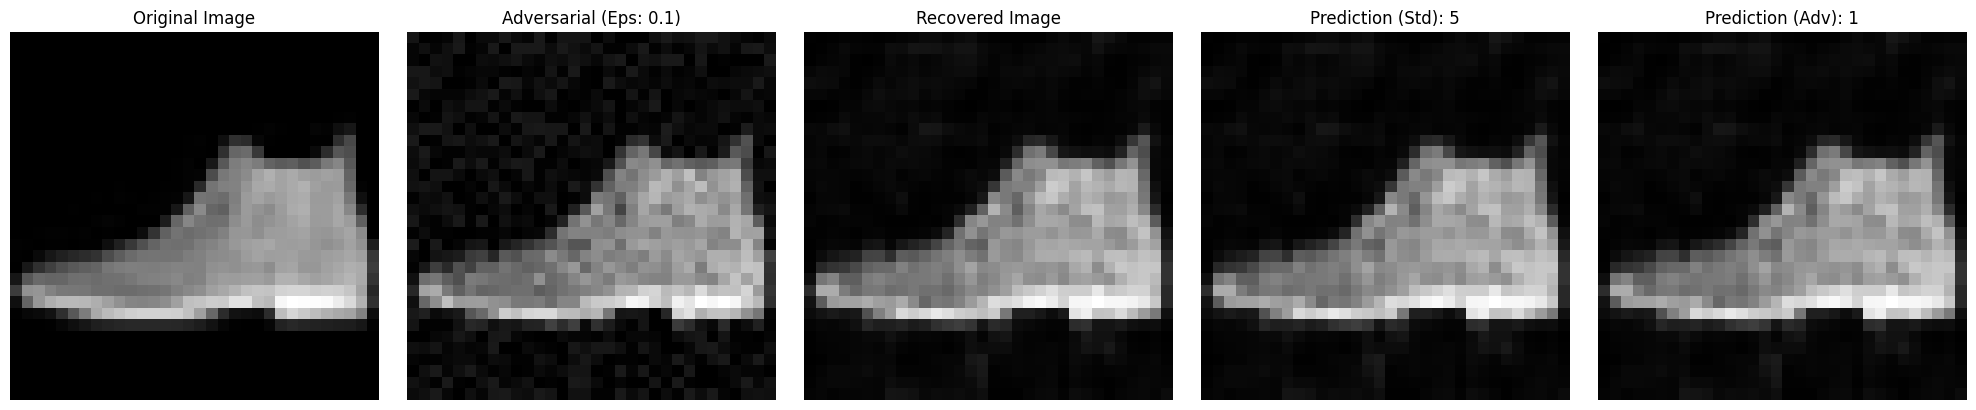

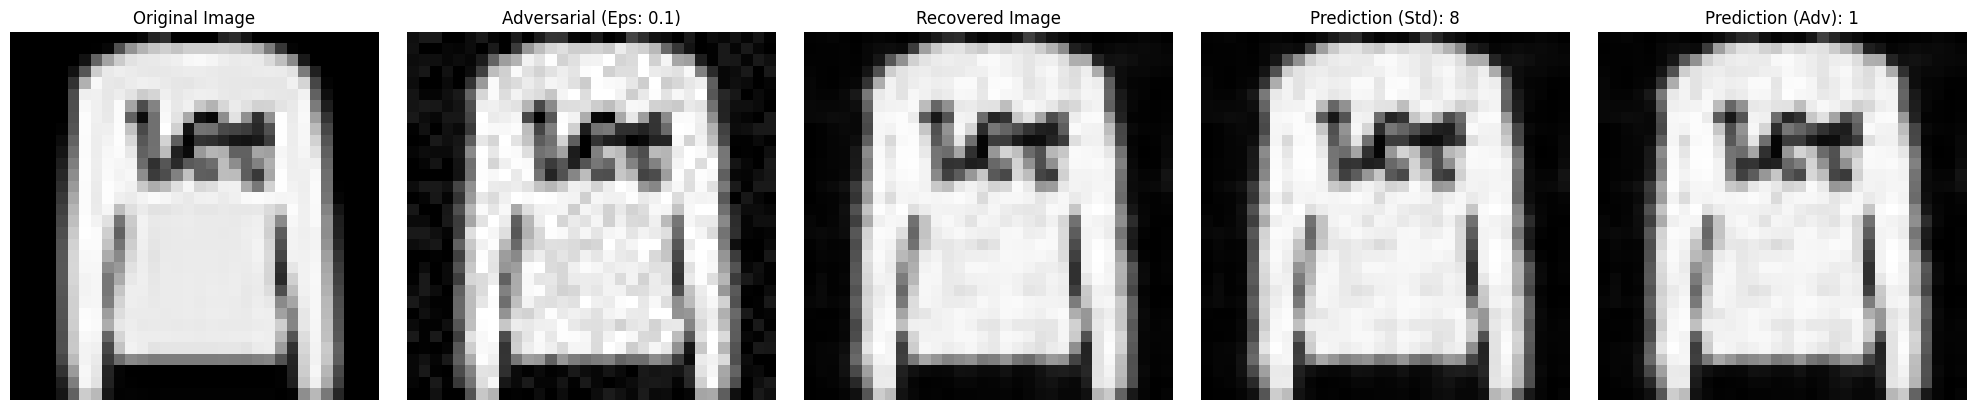

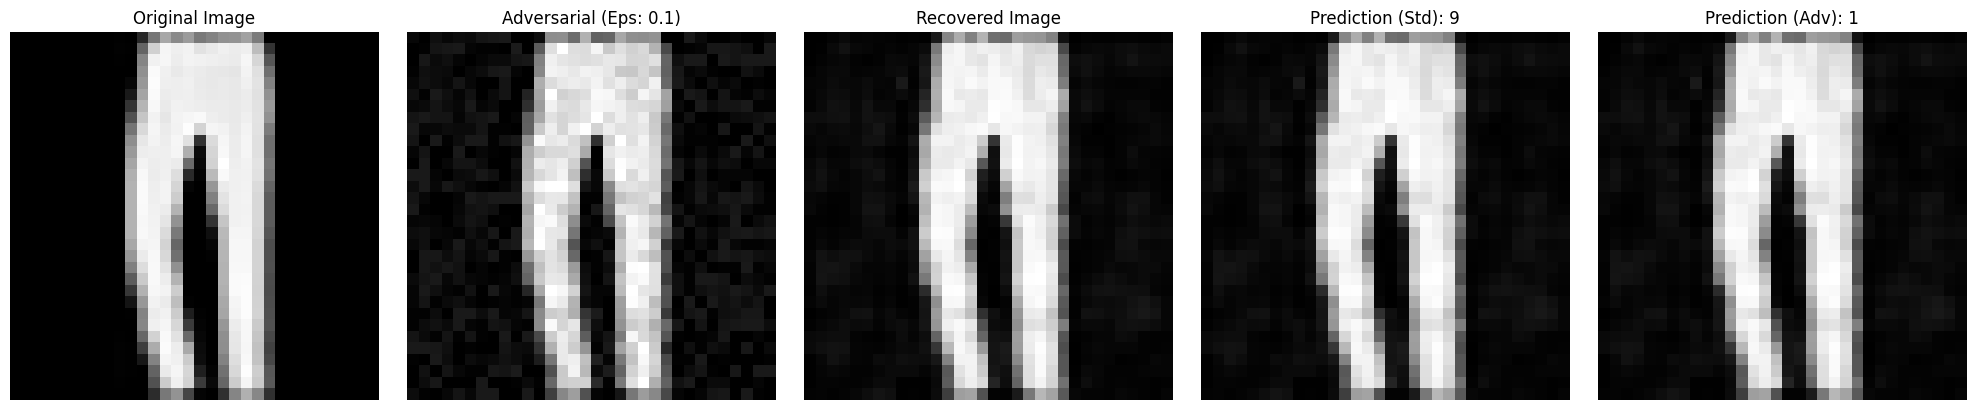

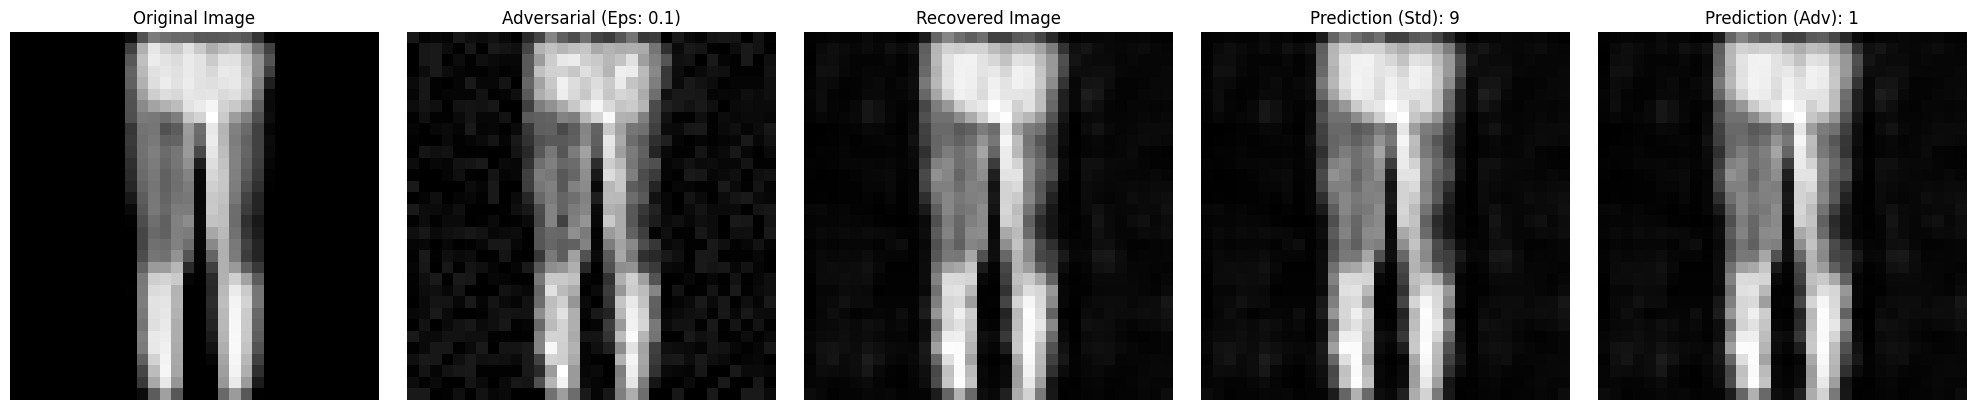

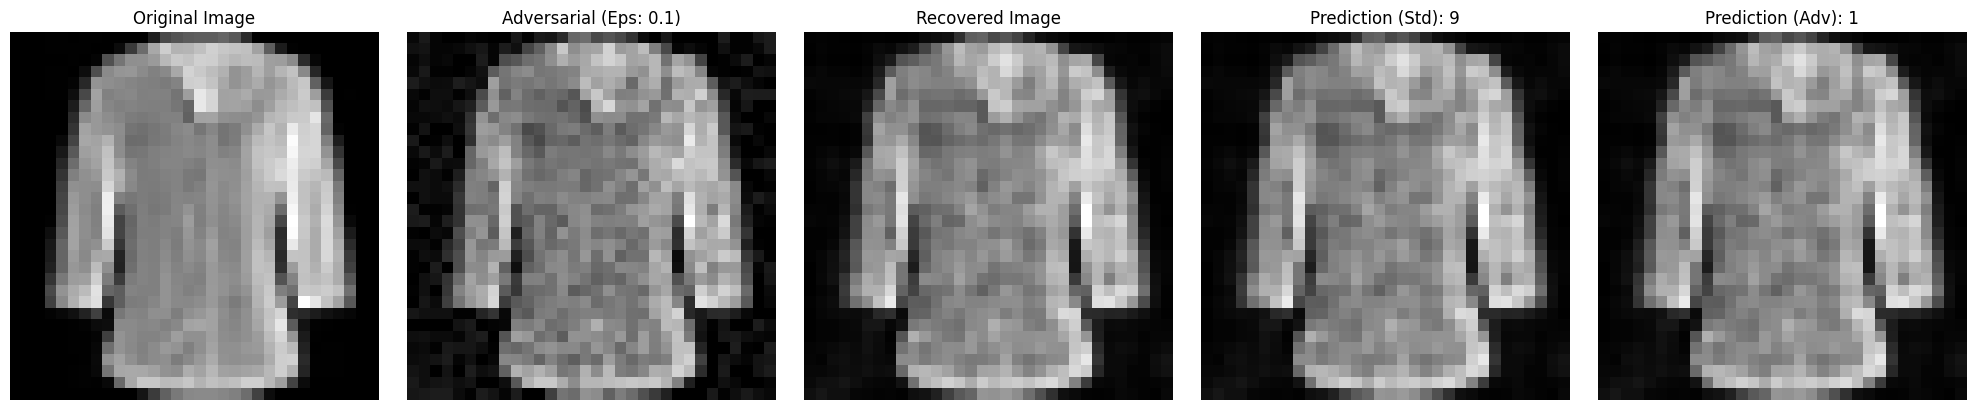


Visualizing for Epsilon: 0.2, Attack Type: PGD



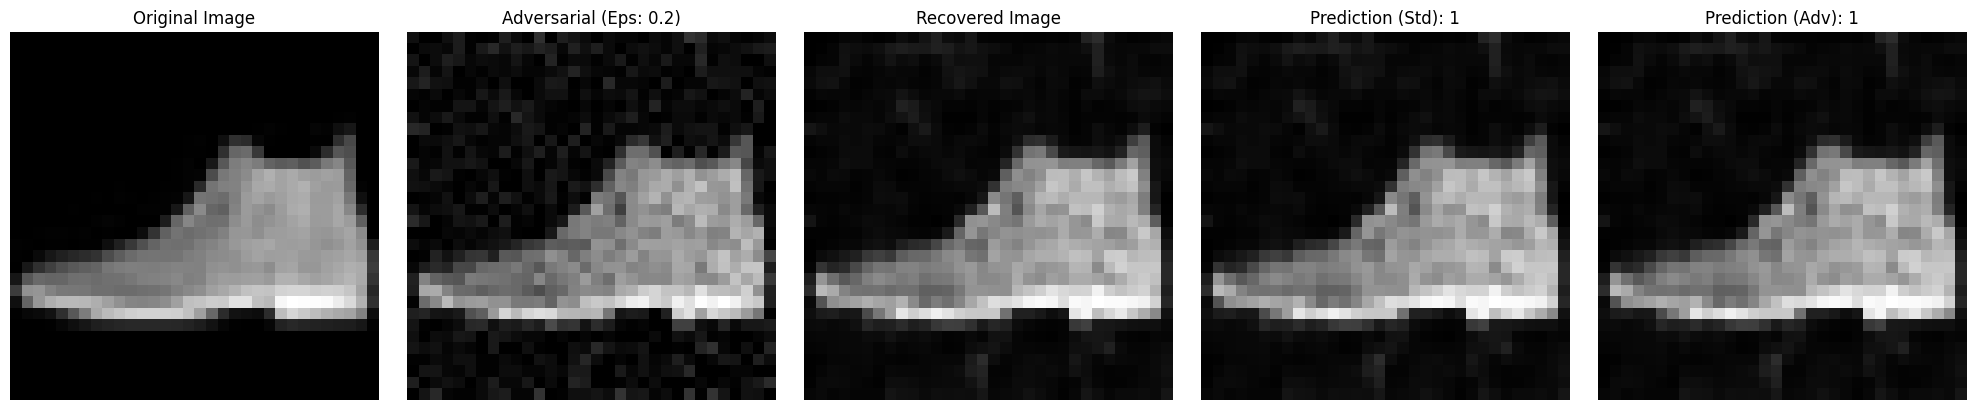

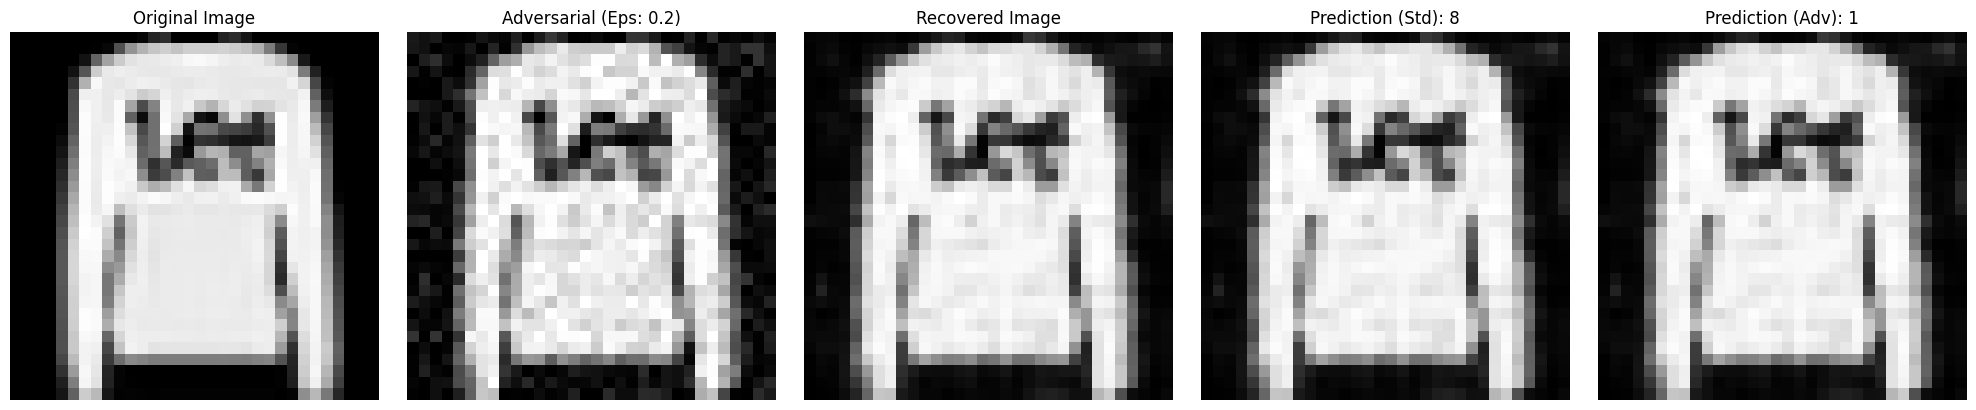

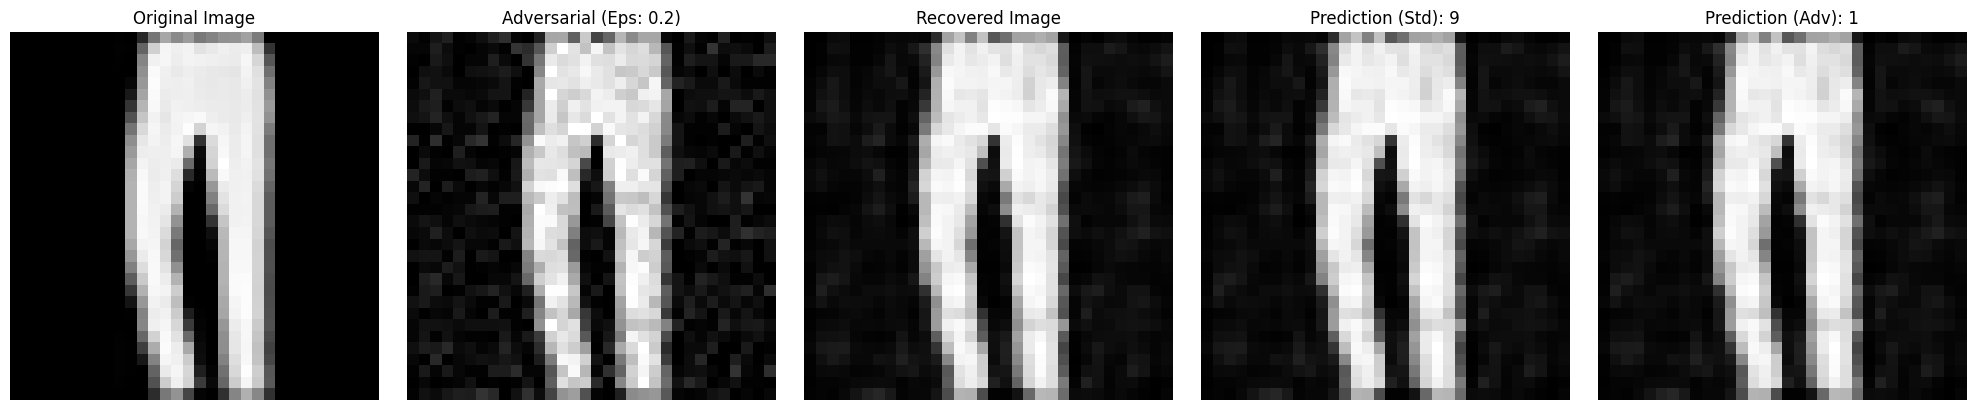

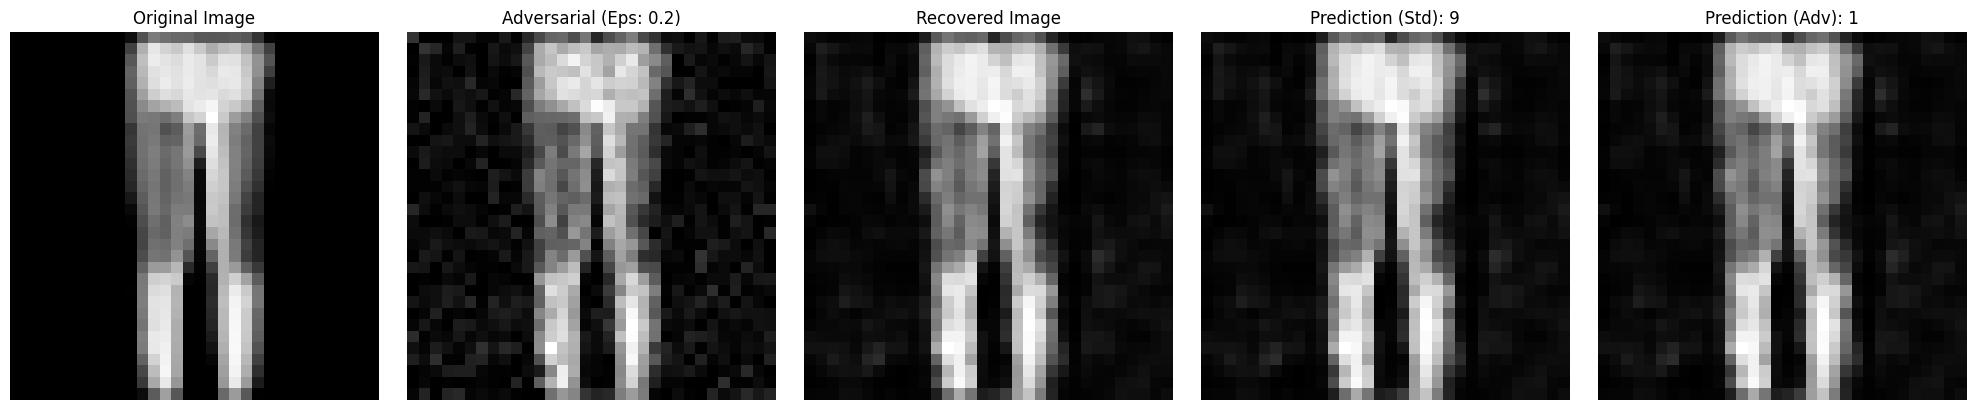

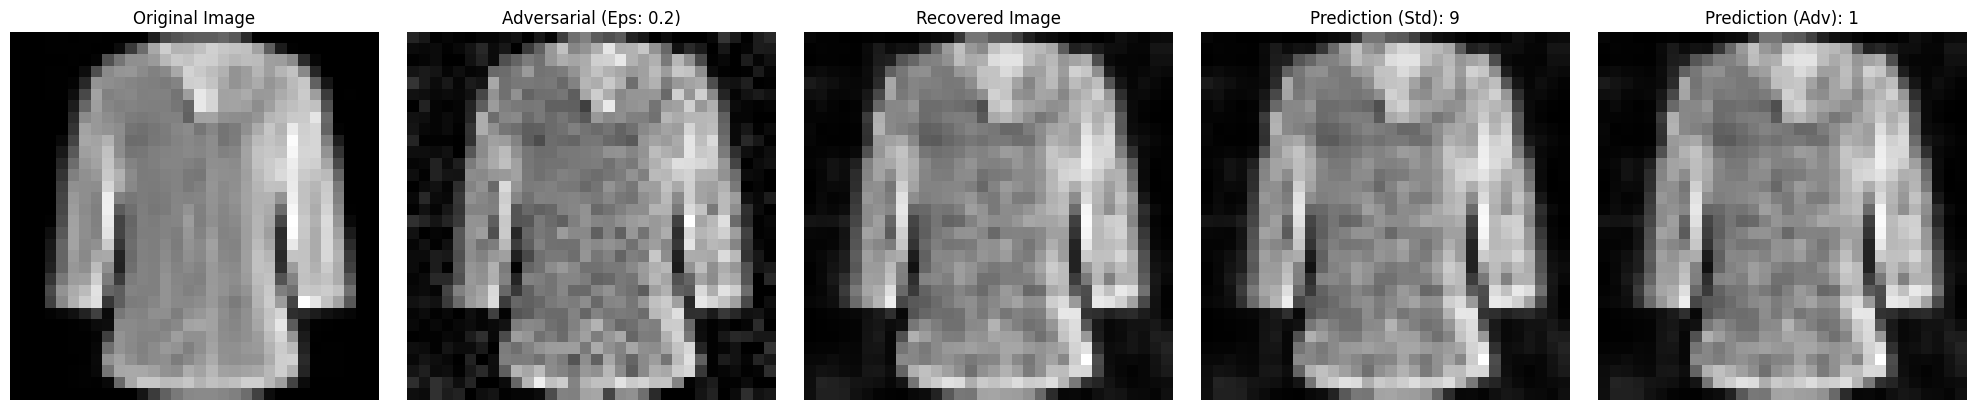


Visualizing for Epsilon: 0.3, Attack Type: PGD



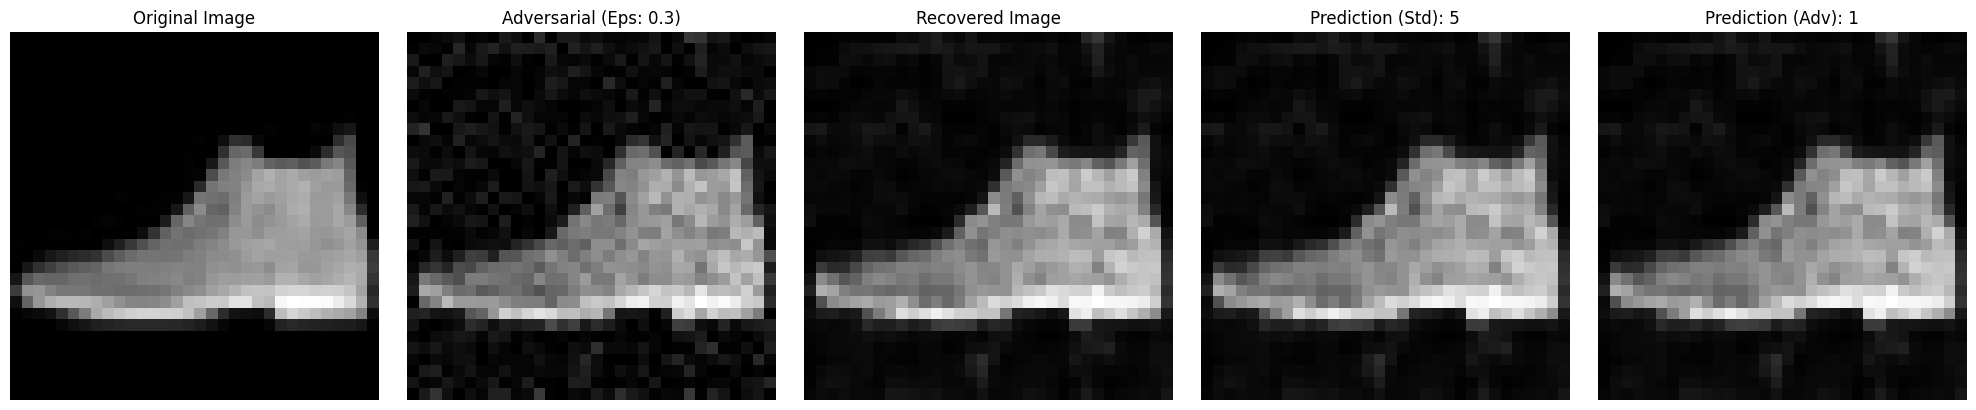

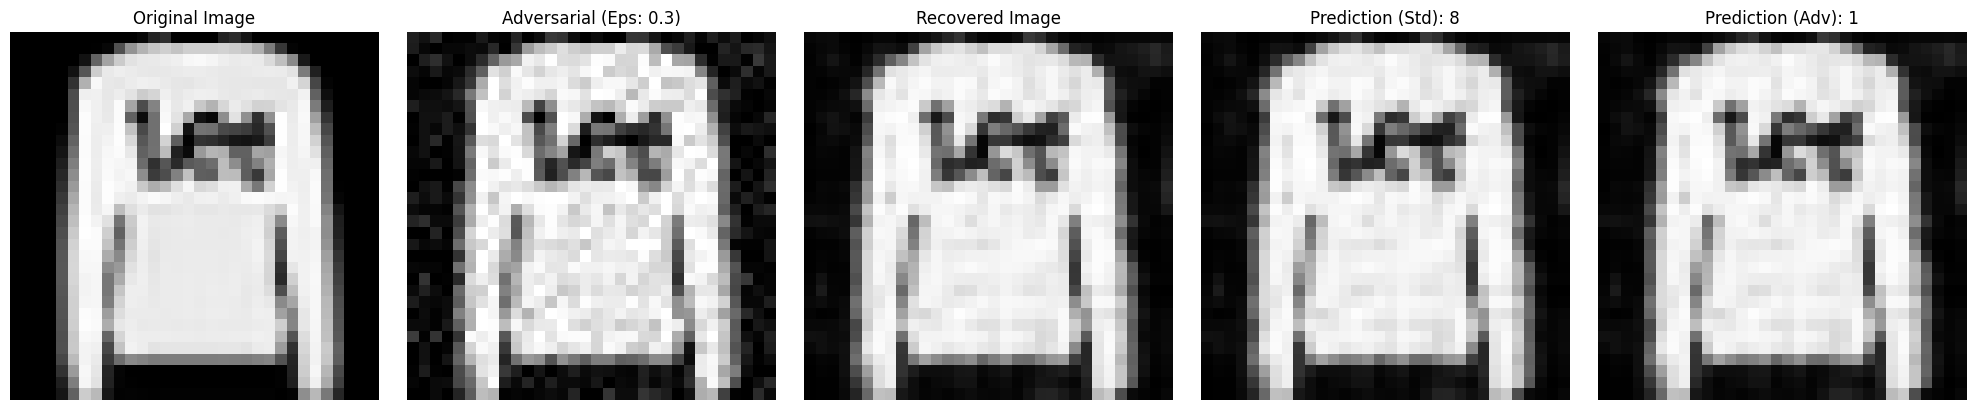

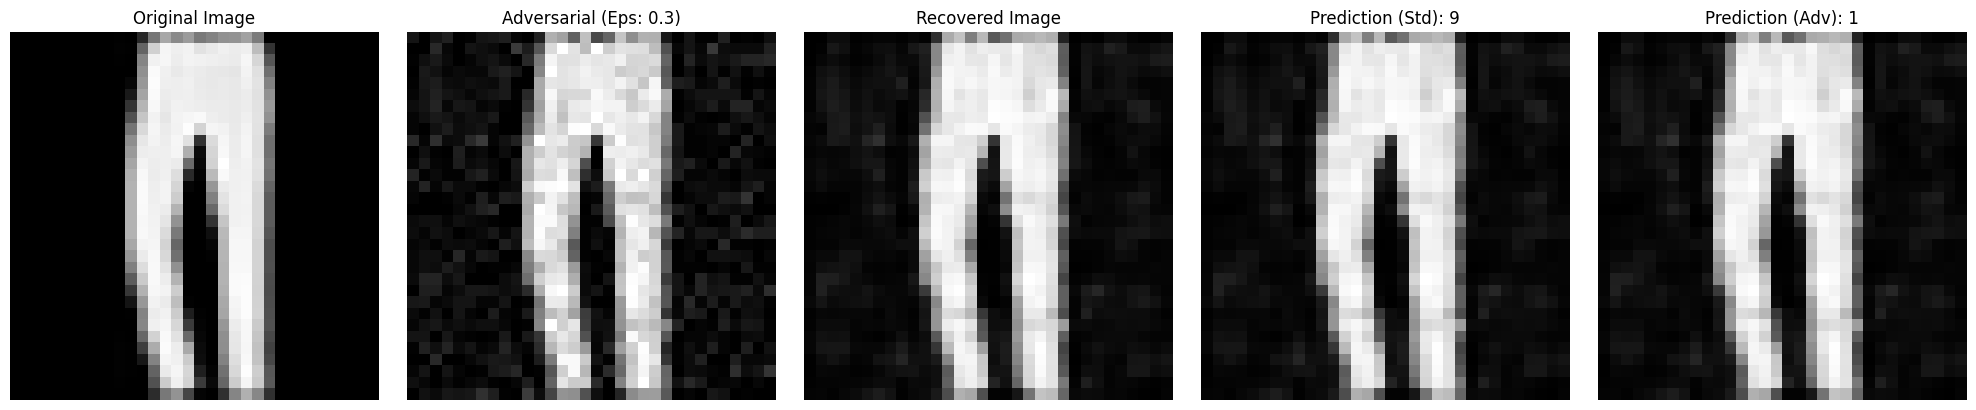

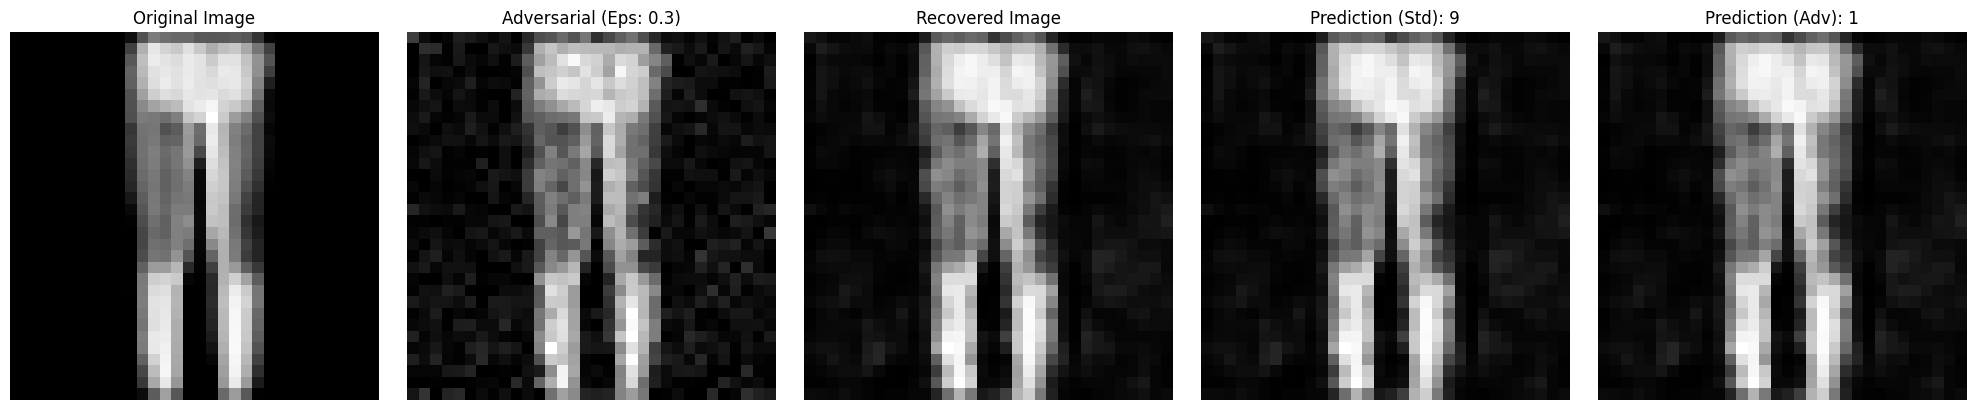

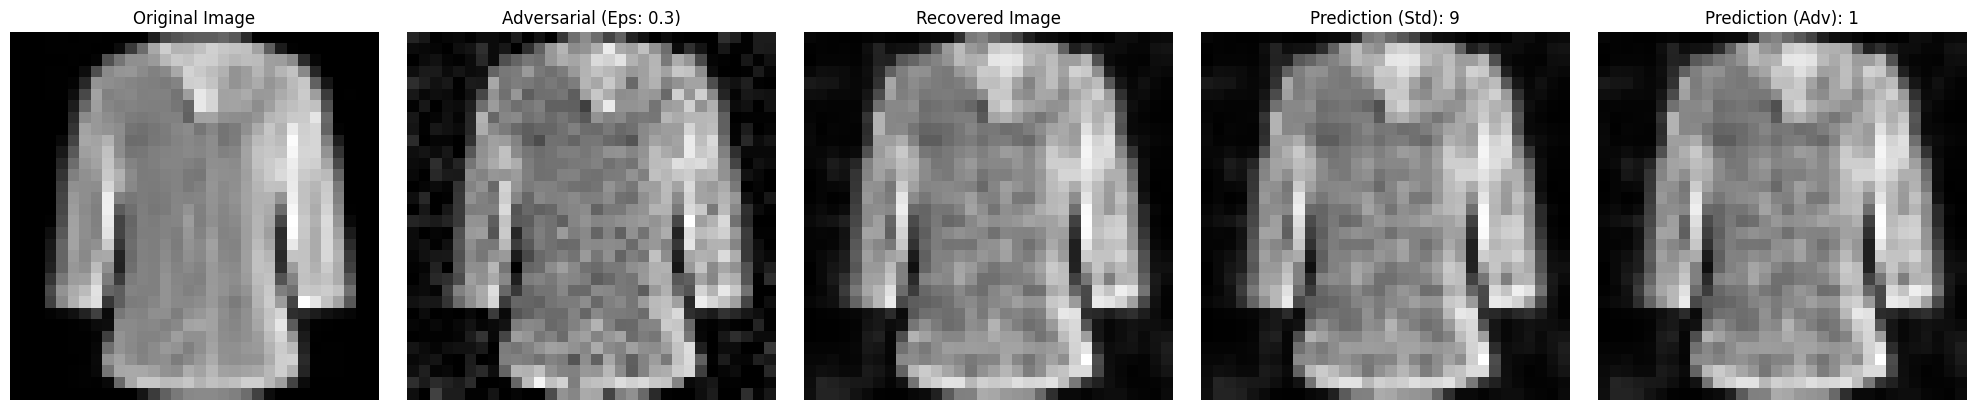


Visualizing for Epsilon: 0.4, Attack Type: PGD



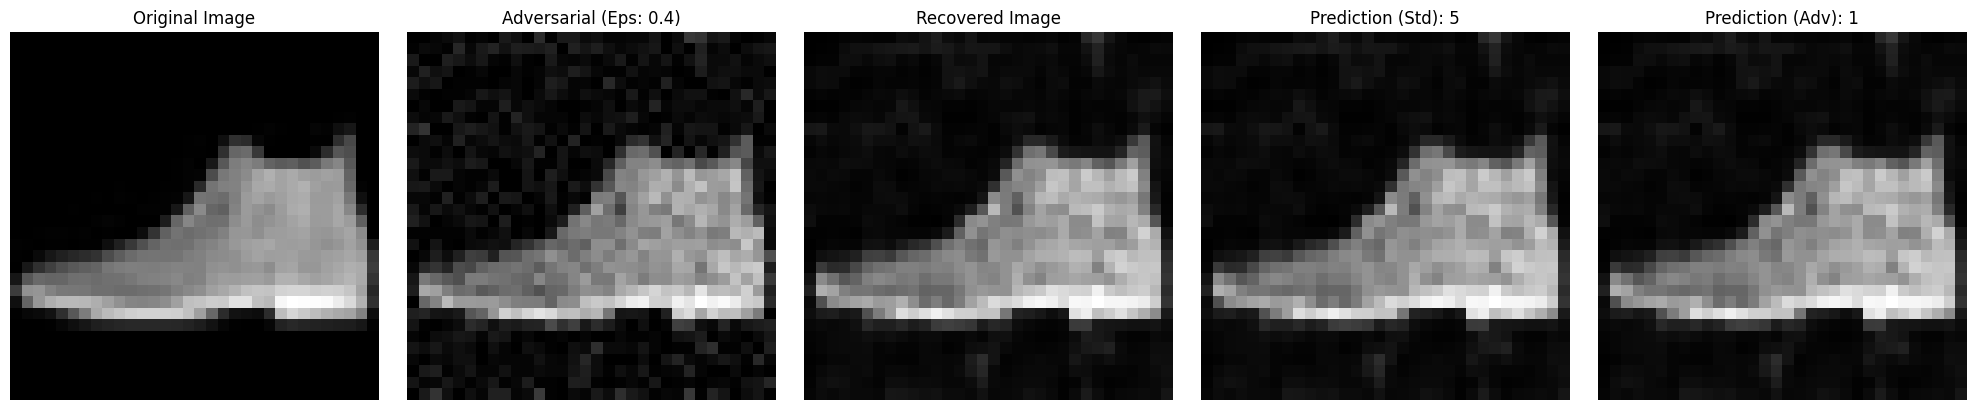

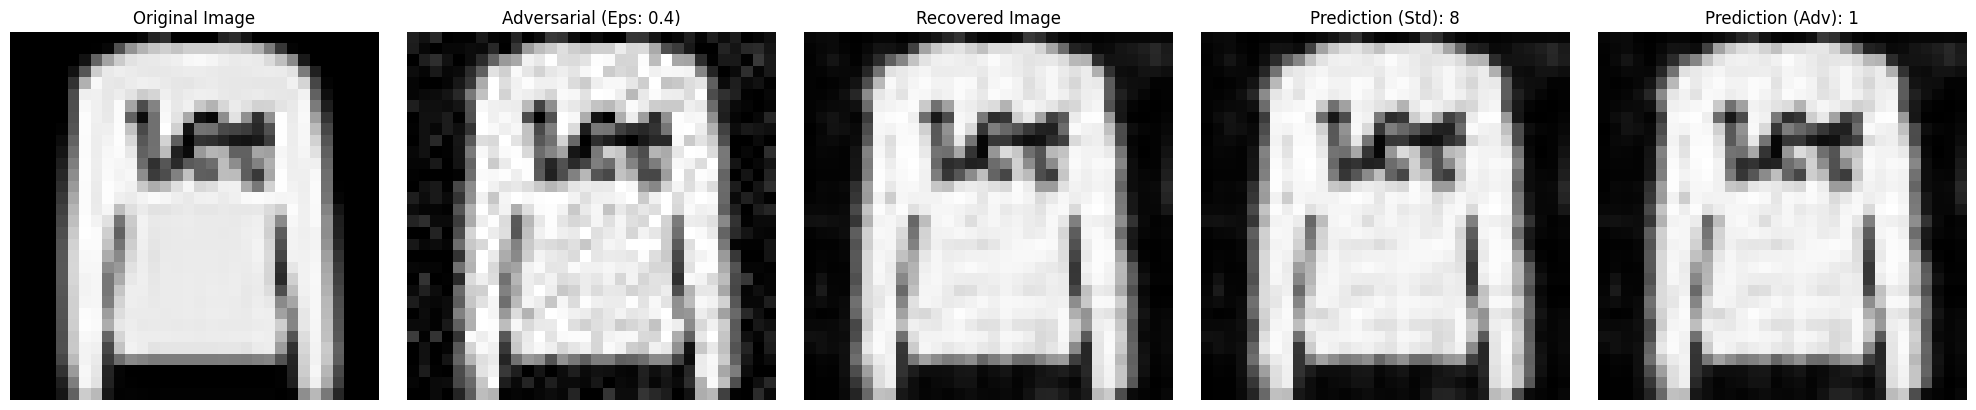

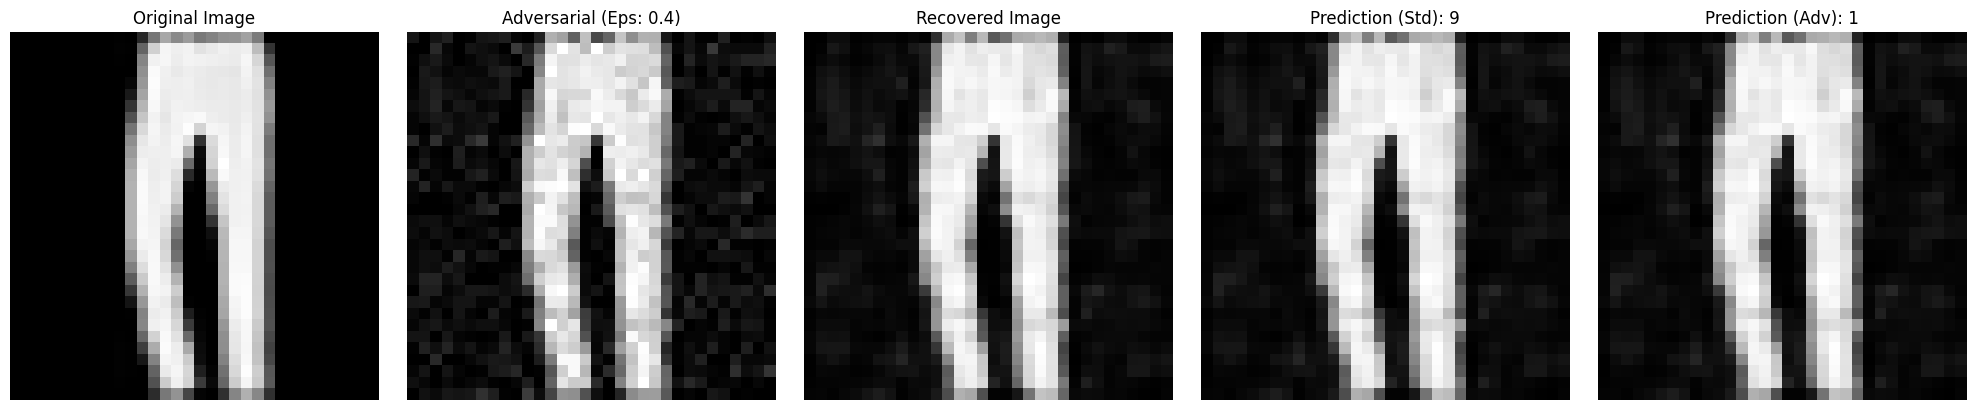

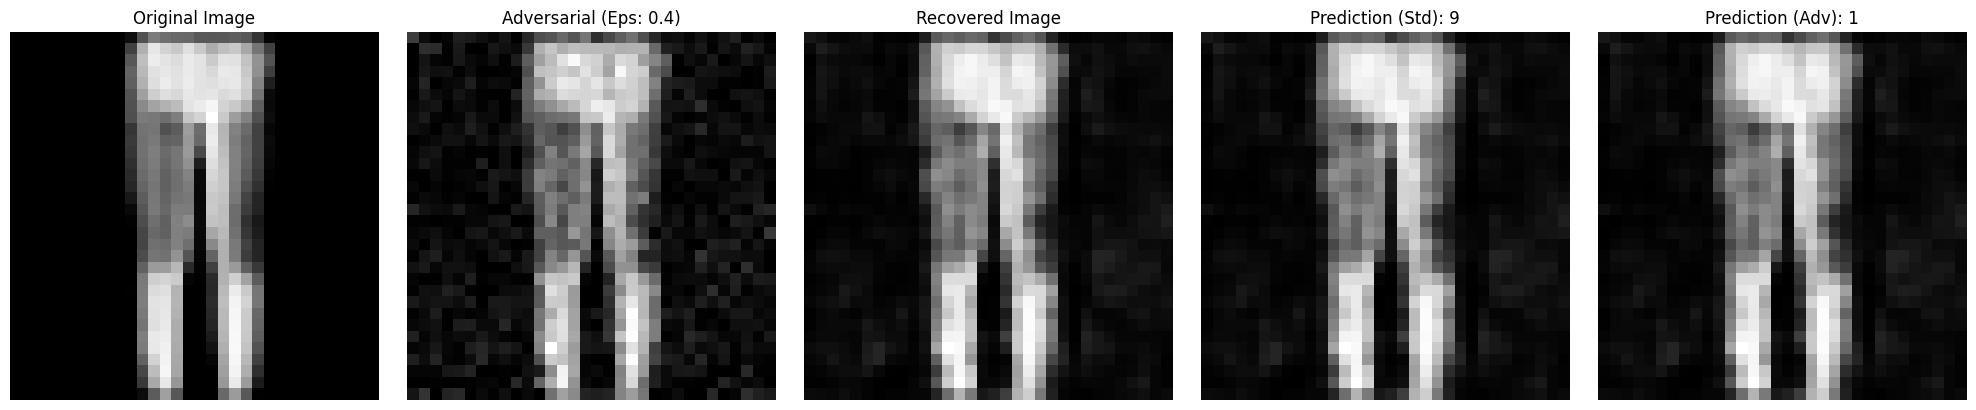

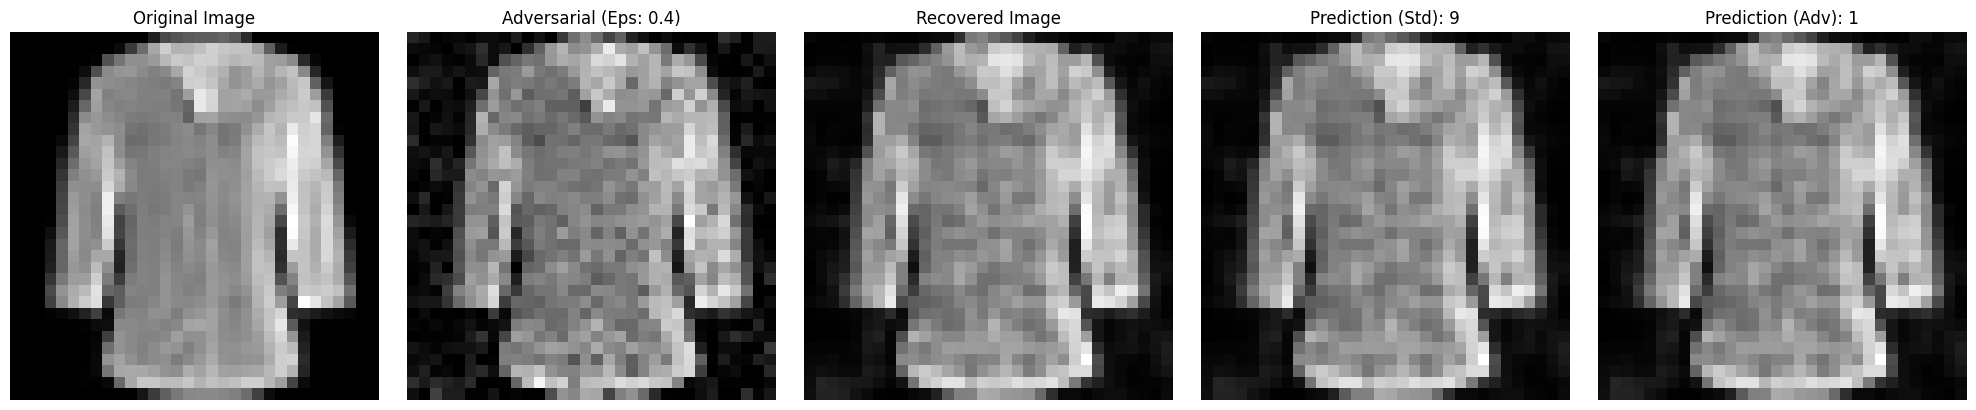

In [ ]:
# Danh sách các giá trị epsilon
epsilons = [0.1, 0.2, 0.3, 0.4]
model_adv = VGG16((1, 32, 32), batch_norm=True).to(device)
# Hiển thị so sánh kết quả giữa hai mô hình
visualize_adversarial_training(model_std=model, model_adv=model_adv,
                               convAE=convAE, test_loader=test_loader,
                               attack_type='fgsm', eps_list=epsilons, num_samples=5)

visualize_adversarial_training(model_std=model, model_adv=model_adv,
                               convAE=convAE, test_loader=test_loader,
                               attack_type='pgd', eps_list=epsilons, num_samples=5)

In [ ]:
from sklearn.metrics import f1_score

def compare_auto_adver(model_auto, model_adver, convAE, test_loader, attack_type, epsilons, alpha=0.01, iters=40):
    """
    So sánh hiệu quả giữa Autoencoder và Adversarial Training.
    - model_auto: Mô hình dùng Autoencoder
    - model_adver: Mô hình dùng Adversarial Training
    """
    results = {"epsilon": [], "accuracy_auto": [], "accuracy_adver": [], "f1_auto": [], "f1_adver": []}

    model_auto.eval()
    model_adver.eval()
    convAE.eval()

    for eps in epsilons:
        total_correct_auto = 0
        total_correct_adver = 0
        total_f1_auto = 0
        total_f1_adver = 0
        total_samples = 0

        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            # Sinh tấn công
            if attack_type == 'fgsm':
                adv_imgs = fgsm_attack(model_auto, imgs, labels, eps)
            elif attack_type == 'pgd':
                adv_imgs = pgd_attack(model_auto, imgs, labels, eps, alpha, iters)
            else:
                adv_imgs = imgs

            # Autoencoder
            rec_imgs = convAE(adv_imgs)
            outputs_auto = model_auto(rec_imgs)
            preds_auto = outputs_auto.argmax(dim=1)

            # Adversarial Training
            outputs_adver = model_adver(adv_imgs)
            preds_adver = outputs_adver.argmax(dim=1)

            # Tính Accuracy
            total_correct_auto += (preds_auto == labels).sum().item()
            total_correct_adver += (preds_adver == labels).sum().item()

            # Tính F1-Score
            total_f1_auto += f1_score(labels.cpu(), preds_auto.cpu(), average='weighted')
            total_f1_adver += f1_score(labels.cpu(), preds_adver.cpu(), average='weighted')

            total_samples += labels.size(0)

        accuracy_auto = total_correct_auto / total_samples
        accuracy_adver = total_correct_adver / total_samples
        avg_f1_auto = total_f1_auto / len(test_loader)
        avg_f1_adver = total_f1_adver / len(test_loader)

        results["epsilon"].append(eps)
        results["accuracy_auto"].append(accuracy_auto)
        results["accuracy_adver"].append(accuracy_adver)
        results["f1_auto"].append(avg_f1_auto)
        results["f1_adver"].append(avg_f1_adver)

        print(f"Epsilon: {eps}")
        print(f"  Autoencoder - Accuracy: {accuracy_auto:.4f}, F1-Score: {avg_f1_auto:.4f}")
        print(f"  Adversarial Training - Accuracy: {accuracy_adver:.4f}, F1-Score: {avg_f1_adver:.4f}")

    return results


In [ ]:
def plot_comparison_results(results):
    epsilons = results["epsilon"]
    acc_auto = results["accuracy_auto"]
    acc_adver = results["accuracy_adver"]
    f1_auto = results["f1_auto"]
    f1_adver = results["f1_adver"]

    # Vẽ biểu đồ Accuracy
    plt.figure(figsize=(10, 5))
    plt.plot(epsilons, acc_auto, label="Autoencoder - Accuracy", marker='o')
    plt.plot(epsilons, acc_adver, label="Adversarial Training - Accuracy", marker='o')
    plt.title("Comparison of Accuracy")
    plt.xlabel("Epsilon")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()
    plt.savefig("output_images/comparison_accuracy.png")
    plt.show()

    # Vẽ biểu đồ F1-Score
    plt.figure(figsize=(10, 5))
    plt.plot(epsilons, f1_auto, label="Autoencoder - F1-Score", marker='o')
    plt.plot(epsilons, f1_adver, label="Adversarial Training - F1-Score", marker='o')
    plt.title("Comparison of F1-Score")
    plt.xlabel("Epsilon")
    plt.ylabel("F1-Score")
    plt.legend()
    plt.grid()
    plt.savefig("output_images/comparison_f1.png")
    plt.show()


Epsilon: 0.1
  Autoencoder - Accuracy: 0.0407, F1-Score: 0.0150
  Adversarial Training - Accuracy: 0.1000, F1-Score: 0.0204
Epsilon: 0.2
  Autoencoder - Accuracy: 0.0836, F1-Score: 0.0406
  Adversarial Training - Accuracy: 0.1000, F1-Score: 0.0204
Epsilon: 0.3
  Autoencoder - Accuracy: 0.1119, F1-Score: 0.0642
  Adversarial Training - Accuracy: 0.1000, F1-Score: 0.0204
Epsilon: 0.4
  Autoencoder - Accuracy: 0.1144, F1-Score: 0.0616
  Adversarial Training - Accuracy: 0.1000, F1-Score: 0.0204


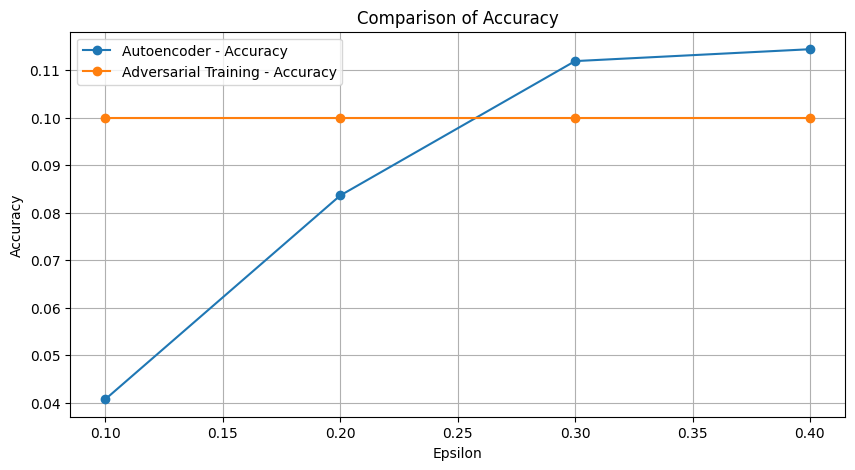

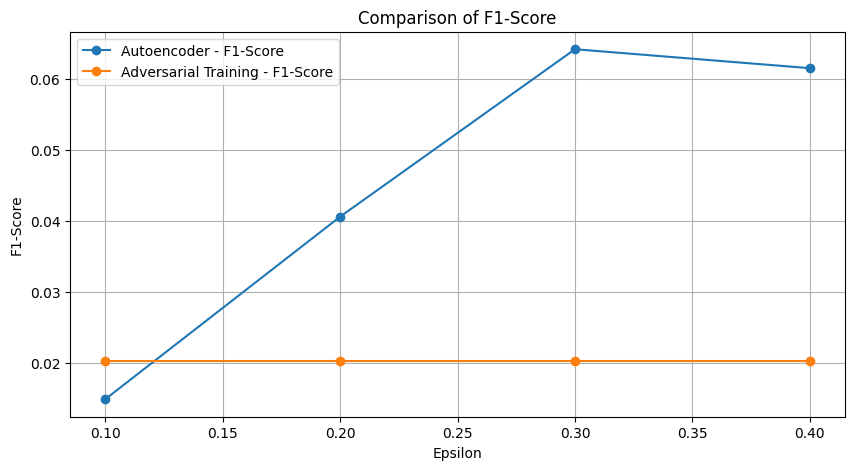

In [ ]:

# Danh sách các epsilon
epsilons = [0.1, 0.2, 0.3, 0.4]

# So sánh hiệu quả Autoencoder và Adversarial Training
results = compare_auto_adver(model_auto=model, model_adver=model_adv,
                             convAE=convAE, test_loader=test_loader,
                             attack_type='fgsm', epsilons=epsilons)

# Vẽ biểu đồ
plot_comparison_results(results)


Epsilon: 0.1
  Autoencoder - Accuracy: 0.0004, F1-Score: 0.0002
  Adversarial Training - Accuracy: 0.1000, F1-Score: 0.0204
Epsilon: 0.2
  Autoencoder - Accuracy: 0.0000, F1-Score: 0.0000
  Adversarial Training - Accuracy: 0.1000, F1-Score: 0.0204
Epsilon: 0.3
  Autoencoder - Accuracy: 0.0000, F1-Score: 0.0000
  Adversarial Training - Accuracy: 0.1000, F1-Score: 0.0204
Epsilon: 0.4
  Autoencoder - Accuracy: 0.0000, F1-Score: 0.0000
  Adversarial Training - Accuracy: 0.1000, F1-Score: 0.0204


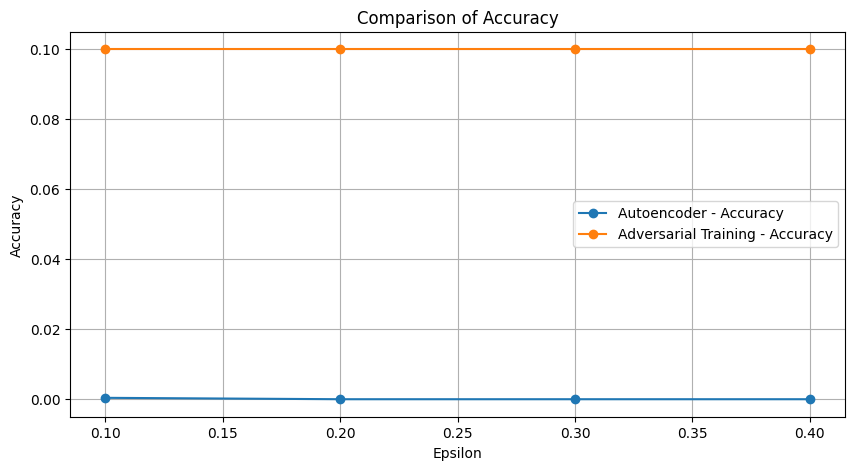

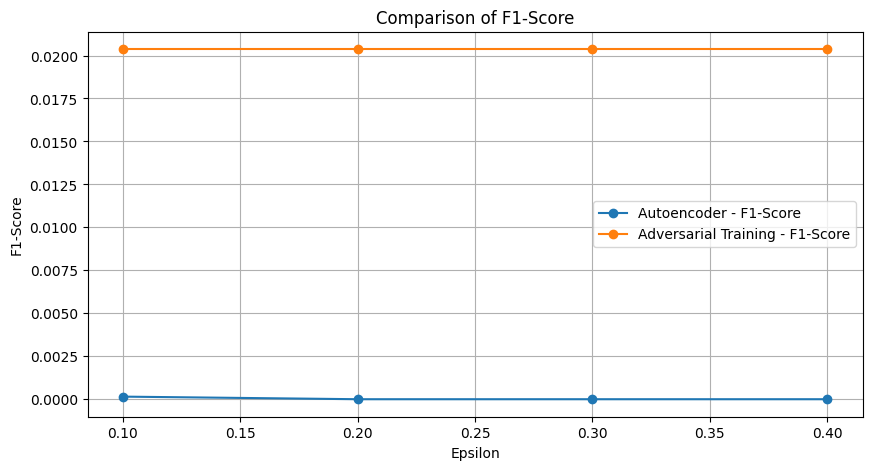

In [ ]:

# Danh sách các epsilon
epsilons = [0.1, 0.2, 0.3, 0.4]

# So sánh hiệu quả Autoencoder và Adversarial Training
results = compare_auto_adver(model_auto=model, model_adver=model_adv,
                             convAE=convAE, test_loader=test_loader,
                             attack_type='pgd', epsilons=epsilons)

# Vẽ biểu đồ
plot_comparison_results(results)
